In [1]:
#0. Import libraries and set up video recorder
import os
os.environ["GIT_PYTHON_REFRESH"] = "quiet"
import git

from myosuite.utils import gym
import skvideo
skvideo.setFFmpegPath(r"C:\Users\rohan\Downloads\ffmpeg-2025-09-04-git-2611874a50-essentials_build\ffmpeg-2025-09-04-git-2611874a50-essentials_build\bin")
import skvideo.io

import numpy as np
import os

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


MyoSuite:> Registering Myo Envs


c:\Users\rohan\anaconda3\envs\exo_s\Lib\site-packages\gymnasium\envs\registration.py:694: UserWarning: WARN: Overriding environment myoArmReachFixed-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
c:\Users\rohan\anaconda3\envs\exo_s\Lib\site-packages\gymnasium\envs\registration.py:694: UserWarning: WARN: Overriding environment myoSarcArmReachFixed-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
c:\Users\rohan\anaconda3\envs\exo_s\Lib\site-packages\gymnasium\envs\registration.py:694: UserWarning: WARN: Overriding environment myoFatiArmReachFixed-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
c:\Users\rohan\anaconda3\envs\exo_s\Lib\site-packages\gymnasium\envs\registration.py:694: UserWarning: WARN: Overriding environment myoArmReachRandom-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registr

In [ ]:
#1. Trains the Healthy Policy to position the elbow. Trains for 250,000 timesteps. This policy can position the elbow FROM and TO ANY RANDOM ANGLE.

from myosuite.utils import gym

env = gym.make('myoElbowPose1D6MRandom-v0')


from stable_baselines3 import PPO

model = PPO("MlpPolicy", env, verbose=1)

print("========================================")
print("Starting policy learning")
print("========================================")

model.learn(total_timesteps=250000)

print("========================================")
print("Job Finished.") 
print("========================================")

model.save('ElbowPose_policy')

In [52]:
#2 Test Healthy Policy (video) - random starting & goal angle

#imports
import os
import numpy as np
import matplotlib.pyplot as plt
import skvideo.io
from stable_baselines3 import PPO
from myosuite.utils import gym
from IPython.display import HTML, display
from base64 import b64encode
import PIL.Image, PIL.ImageDraw

# Master Functions for video recording: from Myosuite's research.
def show_video(video_path, video_width=400):
    video_file = open(video_path, "r+b").read()
    video_url = f'data:video/mp4;base64,{b64encode(video_file).decode()}'
    return HTML(f"<video autoplay width={video_width} controls><source src=\"{video_url}\"></video>")

def add_text_to_frame(frame, text, pos=(20, 20), color=(255, 0, 0), fontsize=12):
    if isinstance(frame, np.ndarray):
        frame = PIL.Image.fromarray(frame)
    draw = PIL.ImageDraw.Draw(frame)
    draw.text(pos, text, fill=color)
    return frame

#Set up the env
env_name = 'myoElbowPose1D6MRandom-v0'
policy_path = 'ElbowPose_policy'
GENERATE_VIDEO = True
video_path = 'videos/elbowpose_policy_demo.mp4'
os.makedirs('videos', exist_ok=True)

#Make env
env = gym.make(env_name)
model = PPO.load(policy_path)

max_steps = env.spec.max_episode_steps if hasattr(env, 'spec') else 500
frames = []

obs, _ = env.reset()

env.unwrapped.target_jnt_value = [2.0]
env.unwrapped.sim.data.qpos[:] = [1.0]
env.unwrapped.target_type = 'fixed'
env.unwrapped.update_target(restore_sim=True)
env.unwrapped.sim.forward()

total_reward = 0

for step in range(max_steps):
    #Gen Vid block REUSE
    if GENERATE_VIDEO:
        frame = env.unwrapped.sim.renderer.render_offscreen(width=400, height=400, camera_id=0)
        _current_time = step * env.unwrapped.dt
        frame = np.array(add_text_to_frame(frame,
                f"t={str(int(_current_time//60)).zfill(2)}:{str(int(_current_time%60)).zfill(2)}min",
                pos=(285, 3), color=(0, 0, 0), fontsize=18))
        frames.append(frame)
    
    # Remember to write this down later to also help explain what the Markov Decision Process is.
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, truncated, info = env.step(action)
    total_reward += reward
    if done or truncated:
        break

step+= 1

env.close()


print(f"Episode finished in {step} steps, total reward: {total_reward}")
#Save vd block
if GENERATE_VIDEO and frames:
    skvideo.io.vwrite(video_path, np.asarray(frames), outputdict={'-pix_fmt': 'yuv420p'})
    print(f"Video saved @: {video_path}")
#disp vd block
if GENERATE_VIDEO and os.path.exists(video_path):
    display(show_video(video_path, video_width=400))

Episode finished in 100 steps, total reward: 758.4377453861991
Video saved @: videos/elbowpose_policy_demo.mp4


In [24]:
#3 MARL - Combining Frozen Healthy Elbow Policy with unlearned exo policy
import myosuite
from myosuite.utils import gym
import skvideo.io
import numpy as np
import os
from stable_baselines3 import PPO
import matplotlib.pyplot as plt
import time
from IPython.display import HTML
from base64 import b64encode
import PIL.Image, PIL.ImageDraw


def show_video(video_path, video_width=400):
    video_file = open(video_path, "r+b").read()
    video_url = f'data:video/mp4;base64,{b64encode(video_file).decode()}'
    return HTML(f"<video autoplay width={video_width} controls><source src=\"{video_url}\"></video>")

def add_text_to_frame(frame, text, pos=(20, 20), color=(255, 0, 0), fontsize=12):
    if isinstance(frame, np.ndarray):
        frame = PIL.Image.fromarray(frame)
    draw = PIL.ImageDraw.Draw(frame)
    draw.text(pos, text, fill=color)
    return frame


from stable_baselines3 import PPO
import gymnasium as gym

class ExoOnlyWrapper(gym.Env):
    def __init__(self, base_env, frozen_policy_path, smart_reset=False, use_avg_mf=False):
        super(ExoOnlyWrapper, self).__init__()
        self.base_env = base_env
        self.frozen_policy = PPO.load(frozen_policy_path)
        self.action_space = gym.spaces.Box(low=np.array([0.0]), high=np.array([1.0]), dtype=np.float32)
        
        
        self.use_avg_mf = use_avg_mf
        
        
        self.n_muscles = len(self.base_env.unwrapped.muscle_fatigue.MA)
        
        
        self.exo_obs_space = self.base_env.observation_space
        

        self.base_obs_dim = self.frozen_policy.observation_space.shape[0]
        self.exo_obs_dim = self.exo_obs_space.shape[0]
        

        
    
        if self.exo_obs_dim < self.base_obs_dim:
            raise ValueError(
                f"Exoskeleton environment has fewer observations ({self.exo_obs_dim}) "
                f"than frozen policy expects ({self.base_obs_dim})"
            )
        

        base_obs_low = self.exo_obs_space.low[:self.base_obs_dim]
        base_obs_high = self.exo_obs_space.high[:self.base_obs_dim]
        
        if self.use_avg_mf:

            mf_low = np.array([0.0], dtype=np.float32)
            mf_high = np.array([1.0], dtype=np.float32)
            obs_desc = f"base obs ({self.base_obs_dim}D) + avg MF (1D) = {self.base_obs_dim + 1}D"
        else:

            mf_low = np.zeros(self.n_muscles, dtype=np.float32)
            mf_high = np.ones(self.n_muscles, dtype=np.float32)
            obs_desc = f"base obs ({self.base_obs_dim}D) + MF values ({self.n_muscles}D) = {self.base_obs_dim + self.n_muscles}D"
        

        combined_low = np.concatenate([base_obs_low, mf_low])
        combined_high = np.concatenate([base_obs_high, mf_high])
        
        self.observation_space = gym.spaces.Box(
            low=combined_low,
            high=combined_high,
            dtype=np.float32
        )
        

        
        self.smart_reset = smart_reset
        if smart_reset == False:
            self.base_env.unwrapped.set_fatigue_reset_random(True)

    def _get_extended_obs(self, exo_obs):
        """
        Extend base observation with muscle fatigue (MF) values
        Args:
            exo_obs: Full observation from exoskeleton environment (15D)
        Returns:
            Extended observation: base obs + MF (either averaged or all values)
        """

        base_obs = exo_obs[:self.base_obs_dim].astype(np.float32)

        mf_values = self.base_env.unwrapped.muscle_fatigue.MF.copy().astype(np.float32)
        
        if self.use_avg_mf:

            avg_mf = np.array([np.mean(mf_values)], dtype=np.float32)
            extended_obs = np.concatenate([base_obs, avg_mf])
        else:

            extended_obs = np.concatenate([base_obs, mf_values])
        
        return extended_obs

    def _get_base_obs_for_policy(self, exo_obs):

        return exo_obs[:self.base_obs_dim].astype(np.float32)

    def reset(self, **kwargs):
        exo_obs, info = self.base_env.reset(fatigue_reset=True)
        low = self.base_env.unwrapped.target_jnt_range[:, 0]
        high = self.base_env.unwrapped.target_jnt_range[:, 1]
        new_target = np.random.uniform(low, high)
        self.base_env.unwrapped.target_jnt_value = new_target
        self.base_env.unwrapped.target_type = 'fixed'

        if self.smart_reset:
            
            MF = np.random.uniform(0.7, 1.0, size=self.n_muscles)

            
            remaining = 1.0 - MF
            split = np.random.uniform(0.0, 1.0, size=self.n_muscles) 
            MA = remaining * split
            MR = remaining * (1.0 - split)

            
            self.base_env.unwrapped.muscle_fatigue.MA[:] = MA
            self.base_env.unwrapped.muscle_fatigue.MR[:] = MR
            self.base_env.unwrapped.muscle_fatigue.MF[:] = MF

        
        extended_obs = self._get_extended_obs(exo_obs)
        return extended_obs, info

    def step(self, exo_action):
        exo_action = np.array([exo_action], dtype=np.float32).reshape(-1)
        
        
        try:
            current_exo_obs = self.base_env._get_obs()
        except AttributeError:
            current_exo_obs = self.base_env.unwrapped.get_obs()
        
        
        base_obs_for_policy = self._get_base_obs_for_policy(current_exo_obs)
        
        
        muscle_actions, _ = self.frozen_policy.predict(base_obs_for_policy, deterministic=True)

        full_action = np.concatenate([exo_action, muscle_actions])
        next_exo_obs, reward, done, truncated, info = self.base_env.step(full_action)
        
        
        extended_obs = self._get_extended_obs(next_exo_obs)
        return extended_obs, reward, done, truncated, info

    def render(self, *args, **kwargs):
        return self.base_env.render(*args, **kwargs)

    def close(self):
        self.base_env.close()

In [5]:
#3.1 Fixed FATIGUE Only Healthy + Exo wrapper

import myosuite
from myosuite.utils import gym
import skvideo.io
import numpy as np
import os
from stable_baselines3 import PPO
import matplotlib.pyplot as plt
import time
from IPython.display import HTML
from base64 import b64encode
import PIL.Image, PIL.ImageDraw


def show_video(video_path, video_width=400):
    video_file = open(video_path, "r+b").read()
    video_url = f'data:video/mp4;base64,{b64encode(video_file).decode()}'
    return HTML(f"<video autoplay width={video_width} controls><source src=\"{video_url}\"></video>")

def add_text_to_frame(frame, text, pos=(20, 20), color=(255, 0, 0), fontsize=12):
    if isinstance(frame, np.ndarray):
        frame = PIL.Image.fromarray(frame)
    draw = PIL.ImageDraw.Draw(frame)
    draw.text(pos, text, fill=color)
    return frame


from stable_baselines3 import PPO
import gymnasium as gym


class ExoOnlyWrapper(gym.Env):
    def __init__(self, base_env, frozen_policy_path, smart_reset=False, use_avg_mf=False, hide_pose_err=False):
        super(ExoOnlyWrapper, self).__init__()
        self.base_env = base_env
        self.frozen_policy = PPO.load(frozen_policy_path)
        self.action_space = gym.spaces.Box(low=np.array([0.0]), high=np.array([1.0]), dtype=np.float32)

        self.use_avg_mf = use_avg_mf
        self.hide_pose_err = hide_pose_err
        
        self.n_muscles = len(self.base_env.unwrapped.muscle_fatigue.MA)
        
        self.exo_obs_space = self.base_env.observation_space

        self.base_obs_dim = self.frozen_policy.observation_space.shape[0]
        self.exo_obs_dim = self.exo_obs_space.shape[0]
        


        if self.exo_obs_dim < self.base_obs_dim:
            raise ValueError(
                f"Exoskeleton environment has fewer observations ({self.exo_obs_dim}) "
                f"than frozen policy expects ({self.base_obs_dim})"
            )

        sample_obs_dict = self.base_env.unwrapped.get_obs_dict(self.base_env.unwrapped.sim)
        pose_err_sample = sample_obs_dict.get("pose_err", np.array([]))
        if hasattr(pose_err_sample, '__len__') and not isinstance(pose_err_sample, str):
            self.pose_err_dim = len(pose_err_sample)
        else:
            self.pose_err_dim = 1
        
        

        if self.hide_pose_err:

            base_obs_dim_adjusted = self.base_obs_dim - self.pose_err_dim
            base_obs_low = self.exo_obs_space.low[:base_obs_dim_adjusted]
            base_obs_high = self.exo_obs_space.high[:base_obs_dim_adjusted]
        else:
            base_obs_low = self.exo_obs_space.low[:self.base_obs_dim]
            base_obs_high = self.exo_obs_space.high[:self.base_obs_dim]
            base_obs_dim_adjusted = self.base_obs_dim
        
        if self.use_avg_mf:
 
            mf_low = np.array([0.0], dtype=np.float32)
            mf_high = np.array([1.0], dtype=np.float32)
            obs_desc = f"base obs ({base_obs_dim_adjusted}D) + avg MF (1D) = {base_obs_dim_adjusted + 1}D"
        else:

            mf_low = np.zeros(self.n_muscles, dtype=np.float32)
            mf_high = np.ones(self.n_muscles, dtype=np.float32)
            obs_desc = f"base obs ({base_obs_dim_adjusted}D) + MF values ({self.n_muscles}D) = {base_obs_dim_adjusted + self.n_muscles}D"
        

        combined_low = np.concatenate([base_obs_low, mf_low])
        combined_high = np.concatenate([base_obs_high, mf_high])
        
        self.observation_space = gym.spaces.Box(
            low=combined_low,
            high=combined_high,
            dtype=np.float32
        )
        


        
        self.smart_reset = smart_reset
        if smart_reset == False:
            self.base_env.unwrapped.set_fatigue_reset_random(True)

    def _get_extended_obs(self, exo_obs):

        if self.hide_pose_err:

            base_obs_dim_adjusted = self.base_obs_dim - self.pose_err_dim
            base_obs = exo_obs[:base_obs_dim_adjusted].astype(np.float32)
        else:
    
            base_obs = exo_obs[:self.base_obs_dim].astype(np.float32)
        

        mf_values = self.base_env.unwrapped.muscle_fatigue.MF.copy().astype(np.float32)
        
        if self.use_avg_mf:

            avg_mf = np.array([np.mean(mf_values)], dtype=np.float32)
            extended_obs = np.concatenate([base_obs, avg_mf])
        else:

            extended_obs = np.concatenate([base_obs, mf_values])
        
        return extended_obs

    def _get_base_obs_for_policy(self, exo_obs):

        return exo_obs[:self.base_obs_dim].astype(np.float32)

    def reset(self, **kwargs):
        exo_obs, info = self.base_env.reset(fatigue_reset=True)
        low = self.base_env.unwrapped.target_jnt_range[:, 0]
        high = self.base_env.unwrapped.target_jnt_range[:, 1]
        new_target = np.random.uniform(low, high)
        self.base_env.unwrapped.target_jnt_value = new_target
        self.base_env.unwrapped.target_type = 'fixed'

        if self.smart_reset:
            MF = np.random.uniform(0.7, 1.0, size=self.n_muscles)

            remaining = 1.0 - MF
            split = np.random.uniform(0.0, 1.0, size=self.n_muscles)  # split ratio
            MA = remaining * split
            MR = remaining * (1.0 - split)

            
            self.base_env.unwrapped.muscle_fatigue.MA[:] = MA
            self.base_env.unwrapped.muscle_fatigue.MR[:] = MR
            self.base_env.unwrapped.muscle_fatigue.MF[:] = MF

        extended_obs = self._get_extended_obs(exo_obs)
        return extended_obs, info

    def step(self, exo_action):
        exo_action = np.array([exo_action], dtype=np.float32).reshape(-1)

        try:
            current_exo_obs = self.base_env._get_obs()
        except AttributeError:
            current_exo_obs = self.base_env.unwrapped.get_obs()

        base_obs_for_policy = self._get_base_obs_for_policy(current_exo_obs)

        muscle_actions, _ = self.frozen_policy.predict(base_obs_for_policy, deterministic=True)

        full_action = np.concatenate([exo_action, muscle_actions])
        next_exo_obs, reward, done, truncated, info = self.base_env.step(full_action)

        extended_obs = self._get_extended_obs(next_exo_obs)
        return extended_obs, reward, done, truncated, info

    def render(self, *args, **kwargs):
        return self.base_env.render(*args, **kwargs)

    def close(self):
        self.base_env.close()

In [ ]:
#3.2 Training Elbow Exo ONLY for Muscular Degeneration
from stable_baselines3 import PPO
from myosuite.utils import gym


env_name = 'myoFatiElbowPose1D6MExoRandom-v0'
frozen_policy_path = 'ElbowPose_policy'


base_env = gym.make(env_name)

exo_env = ExoOnlyWrapper(base_env, frozen_policy_path=frozen_policy_path, smart_reset=True, use_avg_mf=True, hide_pose_err=True)


#ppo_exo = PPO.load('ExoOnly_PPO_policy_final', env = exo_env)
log_dir = "./ppo_exo_tensorboard/"

ppo_exo = PPO('MlpPolicy', exo_env, verbose=1, tensorboard_log=log_dir)

ppo_exo.learn(total_timesteps=1000000)


ppo_exo.save('ExoOnly_PPO_policy_final_full')

print('Final policy saved as: ExoOnly_PPO_policy_final')
print('Total training timesteps: 2 * 500,000')

In [27]:
#3.3 STOPPED WORKING - Video Evaluation for Muscular Degeneration Elbow Exo - Assisted vs. Passive

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
import os
avg = True
pose = True
env_name = "myoFatiElbowPose1D6MExoRandom-v0"
GENERATE_VIDEO = True


base_env = gym.make(env_name)
exo_env = ExoOnlyWrapper(base_env, frozen_policy_path="ElbowPose_policy", use_avg_mf=avg, hide_pose_err=pose)


exo_env.base_env.unwrapped.set_fatigue_reset_random(False)
exo_env.base_env.reset()

max_steps = exo_env.base_env.spec.max_episode_steps
data_exo = []
data_passive = []
frames_exo = []
frames_passive = []

#t_a = 1.4

low = exo_env.base_env.unwrapped.target_jnt_range[:, 0]
high = exo_env.base_env.unwrapped.target_jnt_range[:, 1]
t_a = float(np.random.uniform(low, high))
print(f"Fixed target angle for evaluation: {t_a:.3f} rad")


obs, _ = exo_env.reset()
exo_env.base_env.unwrapped.target_jnt_value = [t_a]
exo_env.base_env.unwrapped.target_type = 'fixed'
exo_env.base_env.unwrapped.update_target(restore_sim=True)

n_muscles = len(exo_env.base_env.unwrapped.muscle_fatigue.MA)
MF_fixed = np.random.uniform(0.8, 1.0, size=n_muscles)
remaining = 1.0 - MF_fixed
split = np.random.uniform(0.0, 1.0, size=n_muscles)
MA_fixed = remaining * split
MR_fixed = remaining * (1.0 - split)



exo_env.base_env.unwrapped.muscle_fatigue.MA[:] = MA_fixed
exo_env.base_env.unwrapped.muscle_fatigue.MR[:] = MR_fixed
exo_env.base_env.unwrapped.muscle_fatigue.MF[:] = MF_fixed


initial_qpos = exo_env.base_env.unwrapped.sim.data.qpos.copy()
initial_qvel = exo_env.base_env.unwrapped.sim.data.qvel.copy()

print("MA:", exo_env.base_env.unwrapped.muscle_fatigue.MA)
print("MR:", exo_env.base_env.unwrapped.muscle_fatigue.MR)
print("MF:", exo_env.base_env.unwrapped.muscle_fatigue.MF)
print("Initial qpos:", initial_qpos)


exo_policy = PPO.load("Full-ElbowExo")



#obs, _ = exo_env.reset()


exo_env.base_env.unwrapped.sim.data.qpos[:] = initial_qpos
exo_env.base_env.unwrapped.sim.data.qvel[:] = initial_qvel
exo_env.base_env.unwrapped.sim.forward()

tr_exo = 0
cumulative_reward_exo = []

for _cstep in range(max_steps):
    if GENERATE_VIDEO:
        frame = exo_env.base_env.unwrapped.sim.renderer.render_offscreen(width=400, height=400, camera_id=0)
        _current_time = _cstep * exo_env.base_env.unwrapped.dt
        frame = np.array(add_text_to_frame(frame,
                f"t={str(int(_current_time//60)).zfill(2)}:{str(int(_current_time%60)).zfill(2)}min",
                pos=(285, 3), color=(0, 0, 0), fontsize=18))
        frames_exo.append(frame)
    
    
    exo_action, _ = exo_policy.predict(obs, deterministic=True)
    next_obs, reward, done, truncated, info = exo_env.step(exo_action)
    #print("Exo action:", exo_action)
    tr_exo += reward
    obs = next_obs
    
   
    current_fatigue = exo_env.base_env.unwrapped.muscle_fatigue.MF.copy()
    avg_fatigue = np.mean(current_fatigue)
    
    data_exo.append({
        "step": _cstep,
        "time": _cstep * exo_env.base_env.unwrapped.dt,
        "exo_action": exo_action.copy(),
        "exo_torque": exo_action[0] if len(exo_action) > 0 else 0.0, 
        "jpos": exo_env.base_env.unwrapped.sim.data.qpos.copy(),
        "mlen": exo_env.base_env.unwrapped.sim.data.actuator_length.copy(),
        "act": exo_env.base_env.unwrapped.sim.data.act.copy(),
        "reward": reward,
        "cumulative_reward": tr_exo,
        "solved": exo_env.base_env.unwrapped.rwd_dict['solved'].item(),
        "pose_err": exo_env.base_env.unwrapped.get_obs_dict(exo_env.base_env.unwrapped.sim)["pose_err"],
        "MA": exo_env.base_env.unwrapped.muscle_fatigue.MA.copy(),
        "MR": exo_env.base_env.unwrapped.muscle_fatigue.MR.copy(),
        "MF": current_fatigue,
        "avg_fatigue": avg_fatigue,
        "ctrl": exo_env.base_env.unwrapped.last_ctrl.copy()
    })
    
    cumulative_reward_exo.append(tr_exo)
    #print(exo_env.base_env.unwrapped.get_obs_dict(exo_env.base_env.unwrapped.sim)["pose_err"])
    if done or truncated:
        break


print(f"Exo-assisted episode total reward: {tr_exo}")




obs, _ = exo_env.reset()

exo_env.base_env.unwrapped.target_type = 'fixed'
exo_env.base_env.unwrapped.target_jnt_value = [t_a]
exo_env.base_env.unwrapped.update_target(restore_sim=True)

exo_env.base_env.unwrapped.muscle_fatigue.MA[:] = MA_fixed
exo_env.base_env.unwrapped.muscle_fatigue.MR[:] = MR_fixed
exo_env.base_env.unwrapped.muscle_fatigue.MF[:] = MF_fixed


exo_env.base_env.unwrapped.sim.data.qpos[:] = initial_qpos
exo_env.base_env.unwrapped.sim.data.qvel[:] = initial_qvel
exo_env.base_env.unwrapped.sim.forward()





tr_passive = 0
cumulative_reward_passive = []

for _cstep in range(max_steps):
    if GENERATE_VIDEO:
        frame = exo_env.base_env.unwrapped.sim.renderer.render_offscreen(width=400, height=400, camera_id=0)
        _current_time = _cstep * exo_env.base_env.unwrapped.dt
        frame = np.array(add_text_to_frame(frame,
                f"t={str(int(_current_time//60)).zfill(2)}:{str(int(_current_time%60)).zfill(2)}min",
                pos=(285, 3), color=(0, 0, 0), fontsize=18))
        frames_passive.append(frame)
    
    
    exo_action = np.array([0.0], dtype=np.float32)
    next_obs, reward, done, truncated, info = exo_env.step(exo_action)
    tr_passive += reward
    obs = next_obs
    
    
    current_fatigue = exo_env.base_env.unwrapped.muscle_fatigue.MF.copy()
    avg_fatigue = np.mean(current_fatigue)
    
    data_passive.append({
        "step": _cstep,
        "time": _cstep * exo_env.base_env.unwrapped.dt,
        "exo_action": exo_action.copy(),
        "exo_torque": 0.0,  
        "jpos": exo_env.base_env.unwrapped.sim.data.qpos.copy(),
        "mlen": exo_env.base_env.unwrapped.sim.data.actuator_length.copy(),
        "act": exo_env.base_env.unwrapped.sim.data.act.copy(),
        "reward": reward,
        "cumulative_reward": tr_passive,
        "solved": exo_env.base_env.unwrapped.rwd_dict['solved'].item(),
        "pose_err": exo_env.base_env.unwrapped.get_obs_dict(exo_env.base_env.unwrapped.sim)["pose_err"],
        "MA": exo_env.base_env.unwrapped.muscle_fatigue.MA.copy(),
        "MR": exo_env.base_env.unwrapped.muscle_fatigue.MR.copy(),
        "MF": current_fatigue,
        "avg_fatigue": avg_fatigue,
        "ctrl": exo_env.base_env.unwrapped.last_ctrl.copy()
    })
    
    cumulative_reward_passive.append(tr_passive)
    #print(exo_env.base_env.unwrapped.get_obs_dict(exo_env.base_env.unwrapped.sim)["pose_err"])
    if done or truncated:

        break

exo_env.close()

print(f"Passive episode total reward: {tr_passive}")


if GENERATE_VIDEO and frames_exo:
    os.makedirs('videos', exist_ok=True)
    video_path_exo = 'videos/episode_exo_assisted.mp4'
    skvideo.io.vwrite(video_path_exo, np.asarray(frames_exo), outputdict={'-pix_fmt': 'yuv420p'})

if GENERATE_VIDEO and frames_passive:
    os.makedirs('videos', exist_ok=True)
    video_path_passive = 'videos/episode_passive.mp4'
    skvideo.io.vwrite(video_path_passive, np.asarray(frames_passive), outputdict={'-pix_fmt': 'yuv420p'})

if GENERATE_VIDEO and 'video_path_exo' in locals():
    display(show_video(video_path_exo))
if GENERATE_VIDEO and 'video_path_passive' in locals():
    display(show_video(video_path_passive))


df_exo = pd.DataFrame(data_exo)
df_passive = pd.DataFrame(data_passive)
_env_dt = exo_env.base_env.unwrapped.dt

Exoskeleton env obs space: (9,)
Frozen policy obs space: (9,)
Number of muscles (MF values): 6
Using average MF: True
Hiding pose_err from agent: True
Detected pose_err dimension: 1
New wrapper obs space: base obs (8D) + avg MF (1D) = 9D
✓ Pose error (1D) hidden from agent observations
✓ Wrapper will extract first 9 dims for frozen policy
Fixed target angle for evaluation: 0.426 rad
MA: [0.0284 0.0228 0.0369 0.0229 0.0136 0.093 ]
MR: [0.0628 0.0769 0.0033 0.0697 0.1289 0.0477]
MF: [0.9088 0.9002 0.9597 0.9074 0.8574 0.8593]
Initial qpos: [1.893]
Running episode with exoskeleton assistance...


C:\Users\rohan\AppData\Local\Temp\ipykernel_25940\3309115701.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  t_a = float(np.random.uniform(low, high))


ValueError: Error: Unexpected observation shape (9,) for Box environment, please use (11,) or (n_env, 11) for the observation shape.

In [28]:
#3.4 STOPPED WORKING Graph Data from Evaluation
min_steps = min(len(df_exo), len(df_passive))
df_exo_trimmed = df_exo.iloc[:min_steps].copy()
df_passive_trimmed = df_passive.iloc[:min_steps].copy()



time_exo = df_exo_trimmed['time'].values
time_passive = df_passive_trimmed['time'].values

def extract_pose_error(pose_err_series):
    pose_errors = []
    for pe in pose_err_series:
        if hasattr(pe, '__len__') and not isinstance(pe, str):
            pose_errors.append(np.linalg.norm(pe))
        else:
            pose_errors.append(float(pe))
    return np.array(pose_errors)

pose_err_exo = extract_pose_error(df_exo_trimmed['pose_err'])
pose_err_passive = extract_pose_error(df_passive_trimmed['pose_err'])

plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(time_exo, df_exo_trimmed['avg_fatigue'], 'b-', label='Exo-Assisted', linewidth=2)
plt.plot(time_passive, df_passive_trimmed['avg_fatigue'], 'r-', label='No Exo (Passive)', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Average Muscle Fatigue')
plt.title('Average Muscle Fatigue: Exo vs No-Exo')
plt.legend()
plt.grid(True, alpha=0.3)

fatigue_reduction = df_passive_trimmed['avg_fatigue'].values - df_exo_trimmed['avg_fatigue'].values
plt.subplot(2, 2, 2)
plt.plot(time_exo, fatigue_reduction, 'g-', label='Fatigue Reduction', linewidth=2)
plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)
plt.xlabel('Time (s)')
plt.ylabel('Fatigue Reduction (No-Exo - Exo)')
plt.title('Fatigue Reduction Due to Exoskeleton')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 3)
exo_torques = df_exo_trimmed['exo_torque'].values
exo_fatigue = df_exo_trimmed['avg_fatigue'].values

ax1 = plt.gca()
color = 'tab:blue'
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Exo Torque', color=color)
ax1.plot(time_exo, exo_torques, color=color, linewidth=2, label='Exo Torque')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Average Fatigue', color=color)
ax2.plot(time_exo, exo_fatigue, color=color, linewidth=2, label='Fatigue (Exo)')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Exo Torque vs Fatigue Over Time')
plt.grid(True, alpha=0.3)

if len(exo_torques) > 1 and np.std(exo_torques) > 1e-10:
    correlation_coef, p_value = pearsonr(exo_torques, fatigue_reduction)
else:
    correlation_coef = 0.0
    

plt.subplot(2, 2, 4)
pose_err_exo_signed = []
pose_err_passive_signed = []

for pe in df_exo_trimmed['pose_err']:
    if hasattr(pe, '__len__') and not isinstance(pe, str):
        pose_err_exo_signed.append(pe[0] if len(pe) > 0 else 0.0)
    else:
        pose_err_exo_signed.append(float(pe))

for pe in df_passive_trimmed['pose_err']:
    if hasattr(pe, '__len__') and not isinstance(pe, str):
        pose_err_passive_signed.append(pe[0] if len(pe) > 0 else 0.0)
    else:
        pose_err_passive_signed.append(float(pe))

pose_err_exo_signed = np.array(pose_err_exo_signed)
pose_err_passive_signed = np.array(pose_err_passive_signed)

plt.plot(time_exo, pose_err_exo_signed, 'b-', label='Exo-Assisted', linewidth=2)
plt.plot(time_passive, pose_err_passive_signed, 'r-', label='No Exo (Passive)', linewidth=2)
plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)
plt.xlabel('Time (s)')
plt.ylabel('Pose Error')
plt.title('Pose Error: Exo vs No-Exo')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(time_exo, df_exo_trimmed['cumulative_reward'], 'b-', label='Exo-Assisted', linewidth=2)
plt.plot(time_passive, df_passive_trimmed['cumulative_reward'], 'r-', label='No Exo (Passive)', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Cumulative Reward')
plt.title('Cumulative Reward Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(time_exo, df_exo_trimmed['reward'], 'b-', label='Exo-Assisted', linewidth=1, alpha=0.7)
plt.plot(time_passive, df_passive_trimmed['reward'], 'r-', label='No Exo (Passive)', linewidth=1, alpha=0.7)
plt.xlabel('Time (s)')
plt.ylabel('Instantaneous Reward')
plt.title('Instantaneous Reward Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("EVALUATION SUMMARY")
print("="*60)
print(f"Episode Length: {min_steps} steps ({min_steps * _env_dt:.1f} seconds)")
print(f"Target Joint Angle: {t_a:.2f} rad")
print()
print("PERFORMANCE METRICS:")
print(f"  Total Reward (Exo): {tr_exo:.2f}")
print(f"  Total Reward (No-Exo): {tr_passive:.2f}")
print(f"  Reward Improvement: {tr_exo - tr_passive:.2f} ({((tr_exo - tr_passive)/abs(tr_passive)*100):.1f}%)")
print()
print("FATIGUE ANALYSIS:")
print(f"  Final Avg Fatigue (Exo): {df_exo_trimmed['avg_fatigue'].iloc[-1]:.4f}")
print(f"  Final Avg Fatigue (No-Exo): {df_passive_trimmed['avg_fatigue'].iloc[-1]:.4f}")
print(f"  Fatigue Reduction: {fatigue_reduction[-1]:.4f}")
print(f"  Mean Fatigue Reduction: {np.mean(fatigue_reduction):.4f}")
print()
print("POSE ERROR ANALYSIS:")
print(f"  Final Pose Error (Exo): {pose_err_exo_signed[-1]:.4f}")
print(f"  Final Pose Error (No-Exo): {pose_err_passive_signed[-1]:.4f}")
print(f"  Mean Pose Error (Exo): {np.mean(pose_err_exo_signed):.4f}")
print(f"  Mean Pose Error (No-Exo): {np.mean(pose_err_passive_signed):.4f}")
print()
print("CORRELATION ANALYSIS:")
print(f"  Exo Torque vs Fatigue Reduction: r = {correlation_coef:.3f}")
print(f"  Exo Torque Range: [{np.min(exo_torques):.3f}, {np.max(exo_torques):.3f}]")
print(f"  Fatigue Reduction Range: [{np.min(fatigue_reduction):.4f}, {np.max(fatigue_reduction):.4f}]")
print("="*60)

NameError: name 'df_exo' is not defined

In [49]:
#4 MARL - Combining Frozen Healthy Elbow Policy with unlearned exo policy BRADY Wrapper
import myosuite
from myosuite.utils import gym
import numpy as np
from stable_baselines3 import PPO


class ExoOnlyWrapperBrady(gym.Env):
    def __init__(self, base_env, frozen_policy_path, hide_pose_err=False, 
                 force_scale_range=(0.8, 0.9), activation_slowdown_range=(2.0, 3.0)):
        super().__init__()

        self.base_env = base_env
        self.frozen_policy = PPO.load(frozen_policy_path)

        self.action_space = gym.spaces.Box(low=np.array([0.0]), high=np.array([1.0]), dtype=np.float32)
        
        self.hide_pose_err = hide_pose_err

        self.force_scale_range = force_scale_range
        self.activation_slowdown_range = activation_slowdown_range
        self.force_scale = 1.0
        self.activation_slowdown = 1.0

        self.original_gear = None
        self.original_dynprm = None
    
        self.exo_obs_space = self.base_env.observation_space
        self.base_obs_dim = self.frozen_policy.observation_space.shape[0]
        self.exo_obs_dim = self.exo_obs_space.shape[0]
        
 

        if self.exo_obs_dim < self.base_obs_dim:
            raise ValueError(
            
            )

        sample_obs_dict = self.base_env.unwrapped.get_obs_dict(self.base_env.unwrapped.sim)
        pose_err_sample = sample_obs_dict.get("pose_err", np.array([]))
        if hasattr(pose_err_sample, '__len__') and not isinstance(pose_err_sample, str):
            self.pose_err_dim = len(pose_err_sample)
        else:
            self.pose_err_dim = 1
        
        
        if self.hide_pose_err:
            base_obs_dim_adjusted = self.base_obs_dim - self.pose_err_dim
            base_obs_low = self.exo_obs_space.low[:base_obs_dim_adjusted]
            base_obs_high = self.exo_obs_space.high[:base_obs_dim_adjusted]
        else:
            base_obs_low = self.exo_obs_space.low[:self.base_obs_dim]
            base_obs_high = self.exo_obs_space.high[:self.base_obs_dim]
            base_obs_dim_adjusted = self.base_obs_dim

        brady_low = np.array([self.force_scale_range[0], self.activation_slowdown_range[0]], dtype=np.float32)
        brady_high = np.array([self.force_scale_range[1], self.activation_slowdown_range[1]], dtype=np.float32)
        obs_desc = f"base obs ({base_obs_dim_adjusted}D) + bradykinesia (2D) = {base_obs_dim_adjusted + 2}D"

        combined_low = np.concatenate([base_obs_low, brady_low])
        combined_high = np.concatenate([base_obs_high, brady_high])
        
        self.observation_space = gym.spaces.Box(
            low=combined_low,
            high=combined_high,
            dtype=np.float32
        )
        

        
    def _sample_bradykinesia_parameters(self):
        self.force_scale = np.random.uniform(*self.force_scale_range)
        self.activation_slowdown = np.random.uniform(*self.activation_slowdown_range)
    
    def _apply_bradykinesia_effects(self):
        model = self.base_env.unwrapped.sim.model
        if self.original_gear is None:
            self.original_gear = model.actuator_gear.copy()

        model.actuator_gear[:] = self.original_gear * self.force_scale

        
        if hasattr(model, 'actuator_dynprm') and model.actuator_dynprm.size > 0:
                if self.original_dynprm is None:
                    self.original_dynprm = model.actuator_dynprm.copy()

                model.actuator_dynprm[:] = self.original_dynprm * self.activation_slowdown
    
    def _restore_original_parameters(self):
        if self.original_gear is not None:
            model = self.base_env.unwrapped.sim.model
            model.actuator_gear[:] = self.original_gear
            
            if self.original_dynprm is not None:
                try:
                    model.actuator_dynprm[:] = self.original_dynprm
                except:
                    pass
    
    def _get_extended_obs(self, exo_obs):
        if self.hide_pose_err:
            base_obs_dim_adjusted = self.base_obs_dim - self.pose_err_dim
            base_obs = exo_obs[:base_obs_dim_adjusted].astype(np.float32)
        else:
            base_obs = exo_obs[:self.base_obs_dim].astype(np.float32)

        brady_obs = np.array([self.force_scale, self.activation_slowdown], dtype=np.float32)
        extended_obs = np.concatenate([base_obs, brady_obs])
        
        return extended_obs
    
    def _get_base_obs_for_policy(self, exo_obs):
        return exo_obs[:self.base_obs_dim].astype(np.float32)
    
    def reset(self, **kwargs):
        self._sample_bradykinesia_parameters()
        exo_obs, info = self.base_env.reset(**kwargs)

        try:
            low = self.base_env.unwrapped.target_jnt_range[:, 0]
            high = self.base_env.unwrapped.target_jnt_range[:, 1]
            new_target = np.random.uniform(low, high)
            self.base_env.unwrapped.target_jnt_value = new_target
            self.base_env.unwrapped.target_type = 'fixed'
        except Exception as e:
            print(f"  Warning: Could not set random target: {e}")

        self._apply_bradykinesia_effects()

        extended_obs = self._get_extended_obs(exo_obs)
        return extended_obs, info
    
    def step(self, exo_action):
        exo_action = np.array([exo_action], dtype=np.float32).reshape(-1)
        
        try:
            current_exo_obs = self.base_env._get_obs()
        except AttributeError:
            current_exo_obs = self.base_env.unwrapped.get_obs()

        base_obs_for_policy = self._get_base_obs_for_policy(current_exo_obs)
        muscle_actions, _ = self.frozen_policy.predict(base_obs_for_policy, deterministic=True)

        full_action = np.concatenate([exo_action, muscle_actions])

        next_exo_obs, reward, done, truncated, info = self.base_env.step(full_action)

        extended_obs = self._get_extended_obs(next_exo_obs)
        return extended_obs, reward, done, truncated, info
    
    def render(self, *args, **kwargs):
        return self.base_env.render(*args, **kwargs)
    
    def close(self):
        self._restore_original_parameters()
        self.base_env.close()
    
    def get_bradykinesia_info(self):
        return {
            'force_scale': self.force_scale,
            'activation_slowdown': self.activation_slowdown
        }

BRADYKINESIA vs NORMAL MOVEMENT COMPARISON
Fixed target angle: 1.700 rad

 BRADYKINESIA Movement:



 NORMAL Movement:



COMPARISON ANALYSIS

 PERFORMANCE SUMMARY:
Bradykinesia - Total Reward: -210.442
Normal       - Total Reward: 609.303

 MOVEMENT SPEED ANALYSIS:
Bradykinesia - Avg Joint Velocity: 1.5111
Normal       - Avg Joint Velocity: 1.6390
Speed Reduction: 7.8%

 FINAL POSE ERROR:
Bradykinesia - Final Pose Error: 0.9074
Normal       - Final Pose Error: 0.0073
Error Increase: 12290.0%


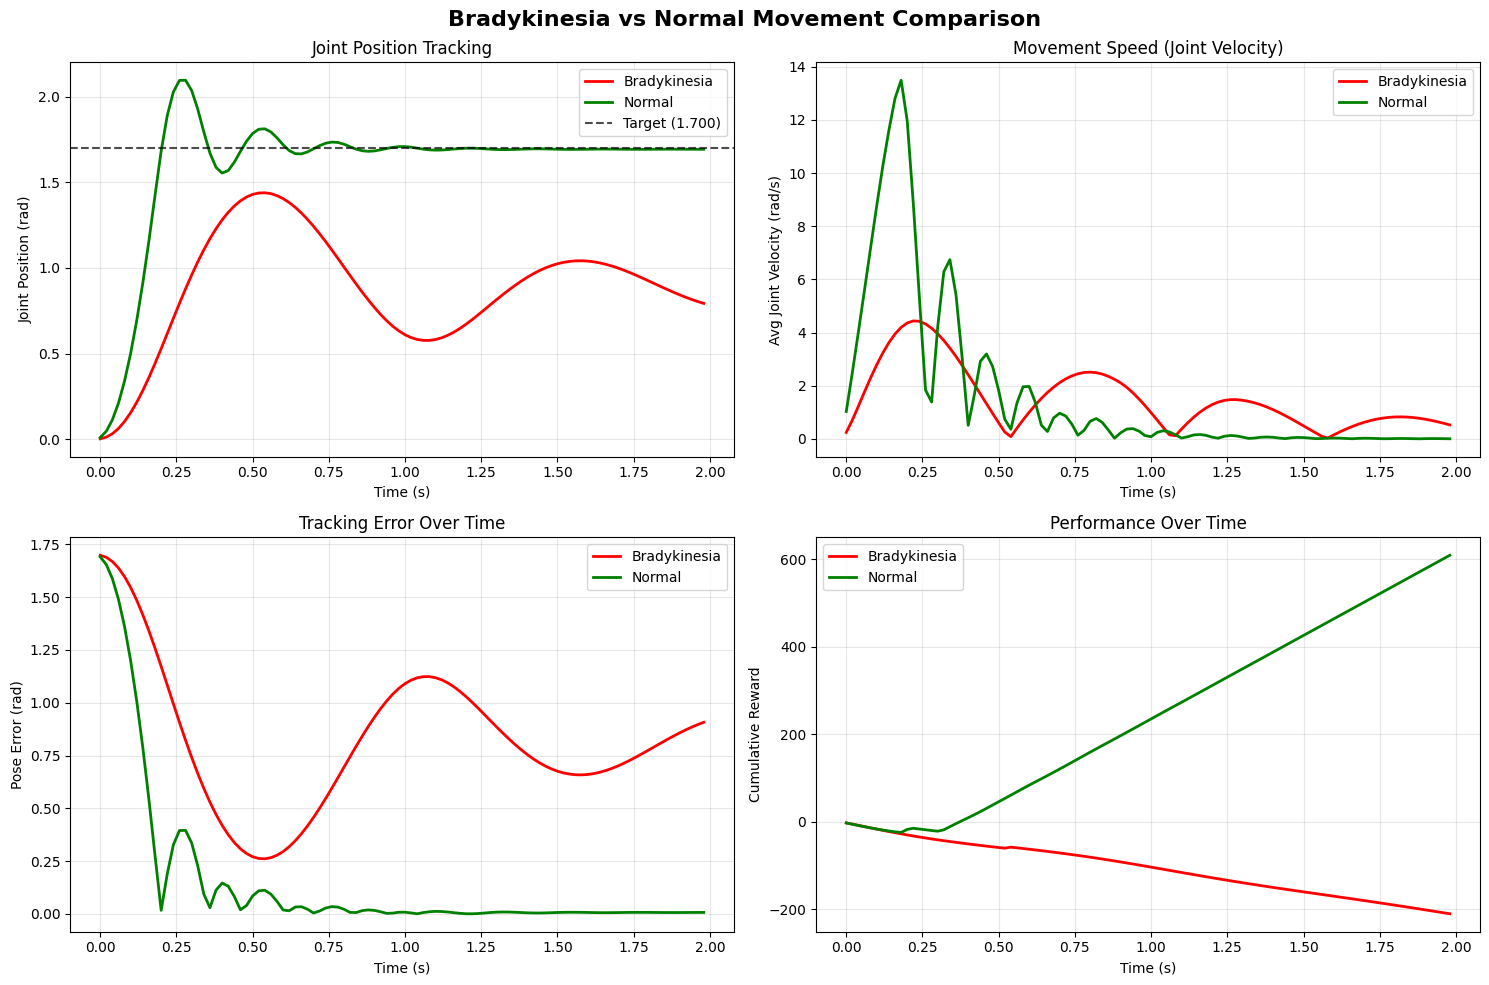

In [52]:
#4.1 Brady + Muscular Degeneration Tester

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from stable_baselines3 import PPO

# Configuration
env_name_exo = "myoElbowPose1D6MExoRandom-v0"  
GENERATE_VIDEO = True
max_steps = 500  # Shorter episodes for comparison

print("="*80)
print("BRADYKINESIA vs NORMAL MOVEMENT COMPARISON")
print("="*80)




base_env_brady = gym.make(env_name_exo)
brady_env = ExoOnlyWrapperBrady(
    base_env_brady, 
    frozen_policy_path="ElbowPose_policy",
    hide_pose_err=True,
    force_scale_range=(0.8, 0.9),  
    activation_slowdown_range=(2.0, 2.5) 
)




base_env_normal = gym.make(env_name_exo)  # Same exoskeleton environment

# Load the human policy for both environments
human_policy = PPO.load("ElbowPose_policy")





low = base_env_normal.unwrapped.target_jnt_range[:, 0]
high = base_env_normal.unwrapped.target_jnt_range[:, 1]


t_a = 1.7#float(np.random.uniform(low, high))



print(f"Fixed target angle: {t_a:.3f} rad")


obs_brady, _ = brady_env.reset()
obs_normal, _ = base_env_normal.reset()


brady_env.base_env.unwrapped.target_jnt_value = [t_a]
brady_env.base_env.unwrapped.target_type = 'fixed'
brady_env.base_env.unwrapped.update_target(restore_sim=True)

base_env_normal.unwrapped.target_jnt_value = [t_a]
base_env_normal.unwrapped.target_type = 'fixed'
base_env_normal.unwrapped.update_target(restore_sim=True)


initial_qpos = base_env_normal.unwrapped.sim.data.qpos.copy()
initial_qvel = base_env_normal.unwrapped.sim.data.qvel.copy()


initial_qpos = 0
brady_env.base_env.unwrapped.sim.data.qpos[:] = initial_qpos
brady_env.base_env.unwrapped.sim.data.qvel[:] = initial_qvel
brady_env.base_env.unwrapped.sim.forward()

base_env_normal.unwrapped.sim.data.qpos[:] = initial_qpos
base_env_normal.unwrapped.sim.data.qvel[:] = initial_qvel
base_env_normal.unwrapped.sim.forward()


brady_info = brady_env.get_bradykinesia_info()





data_brady = []
frames_brady = []
tr_brady = 0

for _cstep in range(max_steps):
    if GENERATE_VIDEO:
        frame = brady_env.base_env.unwrapped.sim.renderer.render_offscreen(width=400, height=400, camera_id=0)
        _current_time = _cstep * brady_env.base_env.unwrapped.dt
        frame = np.array(add_text_to_frame(frame,
                f"BRADYKINESIA - t={str(int(_current_time//60)).zfill(2)}:{str(int(_current_time%60)).zfill(2)}min",
                pos=(200, 3), color=(255, 0, 0), fontsize=14))
        frames_brady.append(frame)
    
   
    exo_action = np.array([0.0], dtype=np.float32)
    next_obs, reward, done, truncated, info = brady_env.step(exo_action)
    tr_brady += reward
    obs_brady = next_obs
    
    
    brady_params = brady_env.get_bradykinesia_info()
    data_brady.append({
        "step": _cstep,
        "time": _cstep * brady_env.base_env.unwrapped.dt,
        "jpos": brady_env.base_env.unwrapped.sim.data.qpos.copy(),
        "jvel": brady_env.base_env.unwrapped.sim.data.qvel.copy(),
        "mlen": brady_env.base_env.unwrapped.sim.data.actuator_length.copy(),
        "act": brady_env.base_env.unwrapped.sim.data.act.copy(),
        "reward": reward,
        "cumulative_reward": tr_brady,
        "solved": brady_env.base_env.unwrapped.rwd_dict['solved'].item(),
        "pose_err": brady_env.base_env.unwrapped.get_obs_dict(brady_env.base_env.unwrapped.sim)["pose_err"],
        "force_scale": brady_params['force_scale'],
        "activation_slowdown": brady_params['activation_slowdown'],
        "ctrl": brady_env.base_env.unwrapped.last_ctrl.copy()
    })
    
    if done or truncated:
        break




base_env_normal.unwrapped.sim.data.qpos[:] = initial_qpos
base_env_normal.unwrapped.sim.data.qvel[:] = initial_qvel  
base_env_normal.unwrapped.sim.forward()

data_normal = []
frames_normal = []
tr_normal = 0

for _cstep in range(max_steps):
    if GENERATE_VIDEO:
        frame = base_env_normal.unwrapped.sim.renderer.render_offscreen(width=400, height=400, camera_id=0)
        _current_time = _cstep * base_env_normal.unwrapped.dt
        frame = np.array(add_text_to_frame(frame,
                f"NORMAL - t={str(int(_current_time//60)).zfill(2)}:{str(int(_current_time%60)).zfill(2)}min",
                pos=(250, 3), color=(0, 255, 0), fontsize=14))
        frames_normal.append(frame)
    
    
    current_obs = base_env_normal.unwrapped.get_obs()
    human_action, _ = human_policy.predict(current_obs, deterministic=True)
    
    
    human_action = np.concatenate([np.array([0.0]), human_action], dtype=np.float32)
    next_obs, reward, done, truncated, info = base_env_normal.step(human_action)
    tr_normal += reward
    
   
    data_normal.append({
        "step": _cstep,
        "time": _cstep * base_env_normal.unwrapped.dt,
        "jpos": base_env_normal.unwrapped.sim.data.qpos.copy(),
        "jvel": base_env_normal.unwrapped.sim.data.qvel.copy(),
        "mlen": base_env_normal.unwrapped.sim.data.actuator_length.copy(),
        "act": base_env_normal.unwrapped.sim.data.act.copy(),
        "reward": reward,
        "cumulative_reward": tr_normal,
        "solved": base_env_normal.unwrapped.rwd_dict['solved'].item(),
        "pose_err": base_env_normal.unwrapped.get_obs_dict(base_env_normal.unwrapped.sim)["pose_err"],
        "force_scale": 1.0,  
        "activation_slowdown": 1.0,  
        "ctrl": base_env_normal.unwrapped.last_ctrl.copy()
    })
    
    if done or truncated:
        break




if GENERATE_VIDEO and frames_brady:
    os.makedirs('videos', exist_ok=True)
    video_path_brady = 'videos/comparison_bradykinesia.mp4'
    skvideo.io.vwrite(video_path_brady, np.asarray(frames_brady), outputdict={'-pix_fmt': 'yuv420p'})
    

if GENERATE_VIDEO and frames_normal:
    os.makedirs('videos', exist_ok=True)
    video_path_normal = 'videos/comparison_normal.mp4'
    skvideo.io.vwrite(video_path_normal, np.asarray(frames_normal), outputdict={'-pix_fmt': 'yuv420p'})
    


if GENERATE_VIDEO and 'video_path_brady' in locals():
    print("\n BRADYKINESIA Movement:")
    display(show_video(video_path_brady))
    
if GENERATE_VIDEO and 'video_path_normal' in locals():
    print("\n NORMAL Movement:")
    display(show_video(video_path_normal))


df_brady = pd.DataFrame(data_brady)
df_normal = pd.DataFrame(data_normal)

print("\n" + "="*80)
print("COMPARISON ANALYSIS")
print("="*80)


print(f"\n PERFORMANCE SUMMARY:")
print(f"Bradykinesia - Total Reward: {tr_brady:.3f}")
print(f"Normal       - Total Reward: {tr_normal:.3f}")



print(f"\n MOVEMENT SPEED ANALYSIS:")
if len(df_brady) > 0 and len(df_normal) > 0:
    
    brady_avg_vel = np.mean([np.mean(np.abs(jvel)) for jvel in df_brady['jvel']])
    normal_avg_vel = np.mean([np.mean(np.abs(jvel)) for jvel in df_normal['jvel']])
    
    print(f"Bradykinesia - Avg Joint Velocity: {brady_avg_vel:.4f}")
    print(f"Normal       - Avg Joint Velocity: {normal_avg_vel:.4f}")
    print(f"Speed Reduction: {((normal_avg_vel - brady_avg_vel)/normal_avg_vel*100):.1f}%")

if len(df_brady) > 0 and len(df_normal) > 0:
    brady_final_pose_err = np.mean(np.abs(df_brady.iloc[-1]['pose_err']))
    normal_final_pose_err = np.mean(np.abs(df_normal.iloc[-1]['pose_err']))
    
    print(f"\n FINAL POSE ERROR:")
    print(f"Bradykinesia - Final Pose Error: {brady_final_pose_err:.4f}")
    print(f"Normal       - Final Pose Error: {normal_final_pose_err:.4f}")
    print(f"Error Increase: {((brady_final_pose_err - normal_final_pose_err)/normal_final_pose_err*100):.1f}%")


fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Bradykinesia vs Normal Movement Comparison', fontsize=16, fontweight='bold')

# Plot 1: Joint position over time
ax1 = axes[0, 0]
if len(df_brady) > 0:
    brady_jpos = np.array([jp[0] for jp in df_brady['jpos']]) 
    ax1.plot(df_brady['time'], brady_jpos, 'r-', label='Bradykinesia', linewidth=2)

if len(df_normal) > 0:
    normal_jpos = np.array([jp[0] for jp in df_normal['jpos']])  
    ax1.plot(df_normal['time'], normal_jpos, 'g-', label='Normal', linewidth=2)

ax1.axhline(y=t_a, color='k', linestyle='--', alpha=0.7, label=f'Target ({t_a:.3f})')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Joint Position (rad)')
ax1.set_title('Joint Position Tracking')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Joint velocity over time
ax2 = axes[0, 1]
if len(df_brady) > 0:
    brady_jvel = np.array([np.mean(np.abs(jv)) for jv in df_brady['jvel']])
    ax2.plot(df_brady['time'], brady_jvel, 'r-', label='Bradykinesia', linewidth=2)

if len(df_normal) > 0:
    normal_jvel = np.array([np.mean(np.abs(jv)) for jv in df_normal['jvel']])
    ax2.plot(df_normal['time'], normal_jvel, 'g-', label='Normal', linewidth=2)

ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Avg Joint Velocity (rad/s)')
ax2.set_title('Movement Speed (Joint Velocity)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Pose error over time
ax3 = axes[1, 0]
if len(df_brady) > 0:
    brady_pose_err = np.array([np.mean(np.abs(pe)) for pe in df_brady['pose_err']])
    ax3.plot(df_brady['time'], brady_pose_err, 'r-', label='Bradykinesia', linewidth=2)

if len(df_normal) > 0:
    normal_pose_err = np.array([np.mean(np.abs(pe)) for pe in df_normal['pose_err']])
    ax3.plot(df_normal['time'], normal_pose_err, 'g-', label='Normal', linewidth=2)

ax3.set_xlabel('Time (s)')
ax3.set_ylabel('Pose Error (rad)')
ax3.set_title('Tracking Error Over Time')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Cumulative reward
ax4 = axes[1, 1]
if len(df_brady) > 0:
    ax4.plot(df_brady['time'], df_brady['cumulative_reward'], 'r-', label='Bradykinesia', linewidth=2)

if len(df_normal) > 0:
    ax4.plot(df_normal['time'], df_normal['cumulative_reward'], 'g-', label='Normal', linewidth=2)

ax4.set_xlabel('Time (s)')
ax4.set_ylabel('Cumulative Reward')
ax4.set_title('Performance Over Time')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('videos/bradykinesia_vs_normal_comparison.png', dpi=300, bbox_inches='tight')
plt.show()




df_brady.to_csv('videos/bradykinesia_data.csv', index=False)
df_normal.to_csv('videos/normal_data.csv', index=False)


brady_env.close()
base_env_normal.close()


In [ ]:
#4.2 BRADY Train
from stable_baselines3 import PPO
from myosuite.utils import gym

env_name = 'myoElbowPose1D6MExoRandom-v0'
frozen_policy_path = 'ElbowPose_policy'


base_env = gym.make(env_name)

exo_env = ExoOnlyWrapperBrady(base_env, frozen_policy_path=frozen_policy_path, hide_pose_err=True)

log_dir = "./ppo_exo_tensorboard/"

ppo_exo = PPO('MlpPolicy', exo_env, verbose=1, tensorboard_log=log_dir)

ppo_exo.learn(total_timesteps=500000)


ppo_exo.save('ExoOnly_PPO_policy_bradyOnly')

print('Final policy saved as: ExoOnly_PPO_policy_bradyOnly')
print('Total training timesteps:  500,000')

In [53]:
#4.3 Eval BRADY - DOESN"T WORK LOST POLICY

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
import os
from stable_baselines3 import PPO


avg = True
pose = True
env_name = "myoElbowPose1D6MExoRandom-v0"  
GENERATE_VIDEO = True


base_env = gym.make(env_name)
brady_env = ExoOnlyWrapperBrady(base_env, frozen_policy_path="ElbowPose_policy", hide_pose_err=pose)

max_steps = brady_env.base_env.spec.max_episode_steps
data_exo = []
data_passive = []
frames_exo = []
frames_passive = []


low = brady_env.base_env.unwrapped.target_jnt_range[:, 0]
high = brady_env.base_env.unwrapped.target_jnt_range[:, 1]
t_a = float(np.random.uniform(low, high))
print(f"Fixed target angle for evaluation: {t_a:.3f} rad")


obs, _ = brady_env.reset()
brady_env.base_env.unwrapped.target_jnt_value = [t_a]
brady_env.base_env.unwrapped.target_type = 'fixed'
brady_env.base_env.unwrapped.update_target(restore_sim=True)


initial_qpos = brady_env.base_env.unwrapped.sim.data.qpos.copy()
initial_qvel = brady_env.base_env.unwrapped.sim.data.qvel.copy()


fixed_force_scale = brady_env.force_scale
fixed_activation_slowdown = brady_env.activation_slowdown

print("Initial qpos:", initial_qpos)


exo_policy = PPO.load("ExoOnly_PPO_policy_bradyOnly")





brady_env.base_env.unwrapped.sim.data.qpos[:] = initial_qpos
brady_env.base_env.unwrapped.sim.data.qvel[:] = initial_qvel
brady_env.base_env.unwrapped.sim.forward()

tr_exo = 0
cumulative_reward_exo = []

for _cstep in range(max_steps):
    if GENERATE_VIDEO:
        frame = brady_env.base_env.unwrapped.sim.renderer.render_offscreen(width=400, height=400, camera_id=0)
        _current_time = _cstep * brady_env.base_env.unwrapped.dt
        frame = np.array(add_text_to_frame(frame,
                f"t={str(int(_current_time//60)).zfill(2)}:{str(int(_current_time%60)).zfill(2)}min",
                pos=(285, 3), color=(0, 0, 0), fontsize=18))
        frames_exo.append(frame)
    
 
    exo_action, _ = exo_policy.predict(obs, deterministic=True)
    next_obs, reward, done, truncated, info = brady_env.step(exo_action)
    tr_exo += reward
    obs = next_obs
    
  
    brady_info = brady_env.get_bradykinesia_info()
    
    data_exo.append({
        "step": _cstep,
        "time": _cstep * brady_env.base_env.unwrapped.dt,
        "exo_action": exo_action.copy(),
        "exo_torque": exo_action[0] if len(exo_action) > 0 else 0.0,
        "jpos": brady_env.base_env.unwrapped.sim.data.qpos.copy(),
        "mlen": brady_env.base_env.unwrapped.sim.data.actuator_length.copy(),
        "act": brady_env.base_env.unwrapped.sim.data.act.copy(),
        "reward": reward,
        "cumulative_reward": tr_exo,
        "solved": brady_env.base_env.unwrapped.rwd_dict['solved'].item(),
        "pose_err": brady_env.base_env.unwrapped.get_obs_dict(brady_env.base_env.unwrapped.sim)["pose_err"],
        
        "force_scale": brady_info['force_scale'],
        "activation_slowdown": brady_info['activation_slowdown'],
        "ctrl": brady_env.base_env.unwrapped.last_ctrl.copy()
    })
    
    cumulative_reward_exo.append(tr_exo)
    
    if done or truncated:
        break





obs, _ = brady_env.reset()


brady_env.force_scale = fixed_force_scale
brady_env.activation_slowdown = fixed_activation_slowdown
brady_env._apply_bradykinesia_effects()

brady_env.base_env.unwrapped.target_type = 'fixed'
brady_env.base_env.unwrapped.target_jnt_value = [t_a]
brady_env.base_env.unwrapped.update_target(restore_sim=True)


brady_env.base_env.unwrapped.sim.data.qpos[:] = initial_qpos
brady_env.base_env.unwrapped.sim.data.qvel[:] = initial_qvel
brady_env.base_env.unwrapped.sim.forward()



tr_passive = 0
cumulative_reward_passive = []

for _cstep in range(max_steps):
    if GENERATE_VIDEO:
        frame = brady_env.base_env.unwrapped.sim.renderer.render_offscreen(width=400, height=400, camera_id=0)
        _current_time = _cstep * brady_env.base_env.unwrapped.dt
        frame = np.array(add_text_to_frame(frame,
                f"t={str(int(_current_time//60)).zfill(2)}:{str(int(_current_time%60)).zfill(2)}min",
                pos=(285, 3), color=(0, 0, 0), fontsize=18))
        frames_passive.append(frame)
    
    
    exo_action = np.array([0.0], dtype=np.float32)
    next_obs, reward, done, truncated, info = brady_env.step(exo_action)
    tr_passive += reward
    obs = next_obs
    
   
    brady_info = brady_env.get_bradykinesia_info()
    
    data_passive.append({
        "step": _cstep,
        "time": _cstep * brady_env.base_env.unwrapped.dt,
        "exo_action": exo_action.copy(),
        "exo_torque": 0.0,  
        "jpos": brady_env.base_env.unwrapped.sim.data.qpos.copy(),
        "mlen": brady_env.base_env.unwrapped.sim.data.actuator_length.copy(),
        "act": brady_env.base_env.unwrapped.sim.data.act.copy(),
        "reward": reward,
        "cumulative_reward": tr_passive,
        "solved": brady_env.base_env.unwrapped.rwd_dict['solved'].item(),
        "pose_err": brady_env.base_env.unwrapped.get_obs_dict(brady_env.base_env.unwrapped.sim)["pose_err"],
        
        "force_scale": brady_info['force_scale'],
        "activation_slowdown": brady_info['activation_slowdown'],
        "ctrl": brady_env.base_env.unwrapped.last_ctrl.copy()
    })
    
    cumulative_reward_passive.append(tr_passive)
    
   

brady_env.close()

print(f"Passive episode total reward: {tr_passive}")


if GENERATE_VIDEO and frames_exo:
    os.makedirs('videos', exist_ok=True)
    video_path_exo = 'videos/episode_brady_exo_assisted.mp4'
    skvideo.io.vwrite(video_path_exo, np.asarray(frames_exo), outputdict={'-pix_fmt': 'yuv420p'})

if GENERATE_VIDEO and frames_passive:
    os.makedirs('videos', exist_ok=True)
    video_path_passive = 'videos/episode_brady_passive.mp4'
    skvideo.io.vwrite(video_path_passive, np.asarray(frames_passive), outputdict={'-pix_fmt': 'yuv420p'})

if GENERATE_VIDEO and 'video_path_exo' in locals():
    display(show_video(video_path_exo))
if GENERATE_VIDEO and 'video_path_passive' in locals():
    display(show_video(video_path_passive))


df_exo = pd.DataFrame(data_exo)
df_passive = pd.DataFrame(data_passive)
_env_dt = brady_env.base_env.unwrapped.dt



C:\Users\rohan\AppData\Local\Temp\ipykernel_25940\2278620359.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  t_a = float(np.random.uniform(low, high))


Fixed target angle for evaluation: 1.987 rad
Initial qpos: [0.939]


FileNotFoundError: [Errno 2] No such file or directory: 'ExoOnly_PPO_policy_bradyOnly.zip'

In [23]:
#5.0 Combined ExoOnlyWrapper
import myosuite
from myosuite.utils import gym
import numpy as np
from stable_baselines3 import PPO


class CombinedExoOnlyWrapper(gym.Env):
    def __init__(self, base_env, frozen_policy_path, 
                 
                 smart_reset=False, use_avg_mf=False, 
                 
                 force_scale_range=(0.8, 0.9), activation_slowdown_range=(1.0, 1.4),
                 
                 hide_pose_err=False):
        super(CombinedExoOnlyWrapper, self).__init__()
        
        self.base_env = base_env
        self.frozen_policy = PPO.load(frozen_policy_path)
        
        
        self.action_space = gym.spaces.Box(low=np.array([0.0]), high=np.array([1.0]), dtype=np.float32)
        
        
        self.smart_reset = smart_reset
        self.use_avg_mf = use_avg_mf
        self.n_muscles = len(self.base_env.unwrapped.muscle_fatigue.MA)
        
        
        self.force_scale_range = force_scale_range
        self.activation_slowdown_range = activation_slowdown_range
        self.force_scale = 1.0
        self.activation_slowdown = 1.0
        self.original_gear = None
        self.original_dynprm = None
        
        
        self.hide_pose_err = hide_pose_err
        
        
        self.exo_obs_space = self.base_env.observation_space
        self.base_obs_dim = self.frozen_policy.observation_space.shape[0]
        self.exo_obs_dim = self.exo_obs_space.shape[0]
        


        # Detect pose_err dimension
        sample_obs_dict = self.base_env.unwrapped.get_obs_dict(self.base_env.unwrapped.sim)
        pose_err_sample = sample_obs_dict.get("pose_err", np.array([]))
        if hasattr(pose_err_sample, '__len__') and not isinstance(pose_err_sample, str):
            self.pose_err_dim = len(pose_err_sample)
        else:
            self.pose_err_dim = 1
        
        
        
        if self.hide_pose_err:
            base_obs_dim_adjusted = self.base_obs_dim - self.pose_err_dim
            base_obs_low = self.exo_obs_space.low[:base_obs_dim_adjusted]
            base_obs_high = self.exo_obs_space.high[:base_obs_dim_adjusted]
        else:
            base_obs_low = self.exo_obs_space.low[:self.base_obs_dim]
            base_obs_high = self.exo_obs_space.high[:base_obs_dim]
            base_obs_dim_adjusted = self.base_obs_dim
        
        
        if self.use_avg_mf:
            
            mf_low = np.array([0.0], dtype=np.float32)
            mf_high = np.array([1.0], dtype=np.float32)
            mf_desc = "avg MF (1D)"
            mf_dim = 1
        else:
            
            mf_low = np.zeros(self.n_muscles, dtype=np.float32)
            mf_high = np.ones(self.n_muscles, dtype=np.float32)
            mf_desc = f"MF values ({self.n_muscles}D)"
            mf_dim = self.n_muscles
        
        
        brady_low = np.array([self.force_scale_range[0], self.activation_slowdown_range[0]], dtype=np.float32)
        brady_high = np.array([self.force_scale_range[1], self.activation_slowdown_range[1]], dtype=np.float32)
        brady_desc = "bradykinesia (2D)"
        
        
        combined_low = np.concatenate([base_obs_low, mf_low, brady_low])
        combined_high = np.concatenate([base_obs_high, mf_high, brady_high])
        
        self.observation_space = gym.spaces.Box(
            low=combined_low,
            high=combined_high,
            dtype=np.float32
        )
        
        total_dim = base_obs_dim_adjusted + mf_dim + 2
        obs_desc = f"base obs ({base_obs_dim_adjusted}D) + {mf_desc} + {brady_desc} = {total_dim}D"
        
        
        if not smart_reset:
            self.base_env.unwrapped.set_fatigue_reset_random(True)

    def _sample_bradykinesia_parameters(self):
        
        self.force_scale = np.random.uniform(*self.force_scale_range)
        self.activation_slowdown = np.random.uniform(*self.activation_slowdown_range)
    
    def _apply_bradykinesia_effects(self):
        
        model = self.base_env.unwrapped.sim.model
        
       
        if self.original_gear is None:
            self.original_gear = model.actuator_gear.copy()

        
        model.actuator_gear[:] = self.original_gear * self.force_scale

        
        try:
            if hasattr(model, 'actuator_dynprm') and model.actuator_dynprm.size > 0:
                if self.original_dynprm is None:
                    self.original_dynprm = model.actuator_dynprm.copy()
                model.actuator_dynprm[:] = self.original_dynprm * self.activation_slowdown
        except Exception as e:
            print(f" fix")
    
    def _restore_original_parameters(self):
        
        if self.original_gear is not None:
            model = self.base_env.unwrapped.sim.model
            model.actuator_gear[:] = self.original_gear
            
            if self.original_dynprm is not None:
                try:
                    model.actuator_dynprm[:] = self.original_dynprm
                except:
                    pass

    def _get_extended_obs(self, exo_obs):

        if self.hide_pose_err:
            base_obs_dim_adjusted = self.base_obs_dim - self.pose_err_dim
            base_obs = exo_obs[:base_obs_dim_adjusted].astype(np.float32)
        else:
            base_obs = exo_obs[:self.base_obs_dim].astype(np.float32)
        
    
        mf_values = self.base_env.unwrapped.muscle_fatigue.MF.copy().astype(np.float32)
        
        if self.use_avg_mf:
            
            mf_obs = np.array([np.mean(mf_values)], dtype=np.float32)
        else:
            
            mf_obs = mf_values
        
       
        brady_obs = np.array([self.force_scale, self.activation_slowdown], dtype=np.float32)
        
       
        extended_obs = np.concatenate([base_obs, mf_obs, brady_obs])
        
        return extended_obs

    def _get_base_obs_for_policy(self, exo_obs):
        
        return exo_obs[:self.base_obs_dim].astype(np.float32)

    def reset(self, **kwargs):
        
        self._sample_bradykinesia_parameters()
        
        
        exo_obs, info = self.base_env.reset(fatigue_reset=True, **kwargs)
        
       
        try:
            low = self.base_env.unwrapped.target_jnt_range[:, 0]
            high = self.base_env.unwrapped.target_jnt_range[:, 1]
            new_target = np.random.uniform(low, high)
            self.base_env.unwrapped.target_jnt_value = new_target
            self.base_env.unwrapped.target_type = 'fixed'
        except Exception as e:
            print(f"  fix {e}")

        
        if self.smart_reset:
            
            MF = np.random.uniform(0.7, 1.0, size=self.n_muscles)
            remaining = 1.0 - MF
            split = np.random.uniform(0.0, 1.0, size=self.n_muscles)
            MA = remaining * split
            MR = remaining * (1.0 - split)

            
            self.base_env.unwrapped.muscle_fatigue.MA[:] = MA
            self.base_env.unwrapped.muscle_fatigue.MR[:] = MR
            self.base_env.unwrapped.muscle_fatigue.MF[:] = MF

        
        self._apply_bradykinesia_effects()

        
        extended_obs = self._get_extended_obs(exo_obs)
        return extended_obs, info

    def step(self, exo_action):
        """Execute one step with exoskeleton action"""
        exo_action = np.array([exo_action], dtype=np.float32).reshape(-1)

        
        try:
            current_exo_obs = self.base_env._get_obs()
        except AttributeError:
            current_exo_obs = self.base_env.unwrapped.get_obs()

        
        base_obs_for_policy = self._get_base_obs_for_policy(current_exo_obs)

       
        muscle_actions, _ = self.frozen_policy.predict(base_obs_for_policy, deterministic=True)

        full_action = np.concatenate([exo_action, muscle_actions])

        next_exo_obs, reward, done, truncated, info = self.base_env.step(full_action)

        extended_obs = self._get_extended_obs(next_exo_obs)
        return extended_obs, reward, done, truncated, info

    def render(self, *args, **kwargs):
        return self.base_env.render(*args, **kwargs)

    def close(self):
        self._restore_original_parameters()
        self.base_env.close()
    
    def get_fatigue_info(self):
        mf_values = self.base_env.unwrapped.muscle_fatigue.MF.copy()
        ma_values = self.base_env.unwrapped.muscle_fatigue.MA.copy()
        mr_values = self.base_env.unwrapped.muscle_fatigue.MR.copy()
        
        return {
            'muscle_fatigue': mf_values,
            'muscle_activation': ma_values,
            'muscle_recovery': mr_values,
            'avg_fatigue': np.mean(mf_values)
        }
    
    def get_bradykinesia_info(self):
        return {
            'force_scale': self.force_scale,
            'activation_slowdown': self.activation_slowdown
        }
    
    def get_combined_info(self):
        fatigue_info = self.get_fatigue_info()
        brady_info = self.get_bradykinesia_info()
        
        return {
            'fatigue': fatigue_info,
            'bradykinesia': brady_info,
            'observation_breakdown': {
                'base_obs_dim': self.base_obs_dim - (self.pose_err_dim if self.hide_pose_err else 0),
                'fatigue_obs_dim': 1 if self.use_avg_mf else self.n_muscles,
                'bradykinesia_obs_dim': 2,
                'total_obs_dim': self.observation_space.shape[0]
            }
        }

In [36]:
#5.05 Combined ExoOnlyWrapper for Testing
import myosuite
from myosuite.utils import gym
import numpy as np
from stable_baselines3 import PPO


class CombinedExoOnlyWrapper(gym.Env):
    def __init__(self, base_env, frozen_policy_path, 
                 
                 smart_reset=False, use_avg_mf=False, 
                 
                 force_scale_range=(0.8, 0.9), activation_slowdown_range=(1.1, 1.7),
                 
                 hide_pose_err=False):
        super(CombinedExoOnlyWrapper, self).__init__()
        
        self.base_env = base_env
        self.frozen_policy = PPO.load(frozen_policy_path)
        
        
        self.action_space = gym.spaces.Box(low=np.array([0.0]), high=np.array([1.0]), dtype=np.float32)
        
        
        self.smart_reset = smart_reset
        self.use_avg_mf = use_avg_mf
        self.n_muscles = len(self.base_env.unwrapped.muscle_fatigue.MA)
        
        
        self.force_scale_range = force_scale_range
        self.activation_slowdown_range = activation_slowdown_range
        self.force_scale = 1.0
        self.activation_slowdown = 1.0
        self.original_gear = None
        self.original_dynprm = None
        
        
        self.hide_pose_err = hide_pose_err
        
        
        self.exo_obs_space = self.base_env.observation_space
        self.base_obs_dim = self.frozen_policy.observation_space.shape[0]
        self.exo_obs_dim = self.exo_obs_space.shape[0]
        


        # Detect pose_err dimension
        sample_obs_dict = self.base_env.unwrapped.get_obs_dict(self.base_env.unwrapped.sim)
        pose_err_sample = sample_obs_dict.get("pose_err", np.array([]))
        if hasattr(pose_err_sample, '__len__') and not isinstance(pose_err_sample, str):
            self.pose_err_dim = len(pose_err_sample)
        else:
            self.pose_err_dim = 1
        
        
        
        if self.hide_pose_err:
            base_obs_dim_adjusted = self.base_obs_dim - self.pose_err_dim
            base_obs_low = self.exo_obs_space.low[:base_obs_dim_adjusted]
            base_obs_high = self.exo_obs_space.high[:base_obs_dim_adjusted]
        else:
            base_obs_low = self.exo_obs_space.low[:self.base_obs_dim]
            base_obs_high = self.exo_obs_space.high[:base_obs_dim]
            base_obs_dim_adjusted = self.base_obs_dim
        
        
        if self.use_avg_mf:
            
            mf_low = np.array([0.0], dtype=np.float32)
            mf_high = np.array([1.0], dtype=np.float32)
            mf_desc = "avg MF (1D)"
            mf_dim = 1
        else:
            
            mf_low = np.zeros(self.n_muscles, dtype=np.float32)
            mf_high = np.ones(self.n_muscles, dtype=np.float32)
            mf_desc = f"MF values ({self.n_muscles}D)"
            mf_dim = self.n_muscles
        
        
        brady_low = np.array([self.force_scale_range[0], self.activation_slowdown_range[0]], dtype=np.float32)
        brady_high = np.array([self.force_scale_range[1], self.activation_slowdown_range[1]], dtype=np.float32)
        brady_desc = "bradykinesia (2D)"
        
        
        combined_low = np.concatenate([base_obs_low, mf_low, brady_low])
        combined_high = np.concatenate([base_obs_high, mf_high, brady_high])
        
        self.observation_space = gym.spaces.Box(
            low=combined_low,
            high=combined_high,
            dtype=np.float32
        )
        
        total_dim = base_obs_dim_adjusted + mf_dim + 2
        obs_desc = f"base obs ({base_obs_dim_adjusted}D) + {mf_desc} + {brady_desc} = {total_dim}D"
        
        
        if not smart_reset:
            self.base_env.unwrapped.set_fatigue_reset_random(True)

    def _sample_bradykinesia_parameters(self):
        
        self.force_scale = np.random.uniform(*self.force_scale_range)
        self.activation_slowdown = np.random.uniform(*self.activation_slowdown_range)
    
    def _apply_bradykinesia_effects(self):
        
        model = self.base_env.unwrapped.sim.model
        
       
        if self.original_gear is None:
            self.original_gear = model.actuator_gear.copy()

        
        model.actuator_gear[:] = self.original_gear * self.force_scale

        
        try:
            if hasattr(model, 'actuator_dynprm') and model.actuator_dynprm.size > 0:
                if self.original_dynprm is None:
                    self.original_dynprm = model.actuator_dynprm.copy()
                model.actuator_dynprm[:] = self.original_dynprm * self.activation_slowdown
        except Exception as e:
            print(f" fix")
    
    def _restore_original_parameters(self):
        
        if self.original_gear is not None:
            model = self.base_env.unwrapped.sim.model
            model.actuator_gear[:] = self.original_gear
            
            if self.original_dynprm is not None:
                try:
                    model.actuator_dynprm[:] = self.original_dynprm
                except:
                    pass

    def _get_extended_obs(self, exo_obs):

        if self.hide_pose_err:
            base_obs_dim_adjusted = self.base_obs_dim - self.pose_err_dim
            base_obs = exo_obs[:base_obs_dim_adjusted].astype(np.float32)
        else:
            base_obs = exo_obs[:self.base_obs_dim].astype(np.float32)
        
    
        mf_values = self.base_env.unwrapped.muscle_fatigue.MF.copy().astype(np.float32)
        
        if self.use_avg_mf:
            
            mf_obs = np.array([np.mean(mf_values)], dtype=np.float32)
        else:
            
            mf_obs = mf_values
        
       
        brady_obs = np.array([self.force_scale, self.activation_slowdown], dtype=np.float32)
        
       
        extended_obs = np.concatenate([base_obs, mf_obs, brady_obs])
        
        return extended_obs

    def _get_base_obs_for_policy(self, exo_obs):
        
        return exo_obs[:self.base_obs_dim].astype(np.float32)

    def reset(self, **kwargs):
        
        self._sample_bradykinesia_parameters()
        
        
        exo_obs, info = self.base_env.reset(fatigue_reset=True, **kwargs)
        
       
        try:
            low = self.base_env.unwrapped.target_jnt_range[:, 0]
            high = self.base_env.unwrapped.target_jnt_range[:, 1]
            new_target = np.random.uniform(low, high)
            self.base_env.unwrapped.target_jnt_value = new_target
            self.base_env.unwrapped.target_type = 'fixed'
        except Exception as e:
            print(f"  fix {e}")

        
        if self.smart_reset:
            
            MF = np.random.uniform(0.3, 0.8, size=self.n_muscles)
            remaining = 1.0 - MF
            split = np.random.uniform(0.0, 1.0, size=self.n_muscles)
            MA = remaining * split
            MR = remaining * (1.0 - split)

            
            self.base_env.unwrapped.muscle_fatigue.MA[:] = MA
            self.base_env.unwrapped.muscle_fatigue.MR[:] = MR
            self.base_env.unwrapped.muscle_fatigue.MF[:] = MF

        
        self._apply_bradykinesia_effects()

        
        extended_obs = self._get_extended_obs(exo_obs)
        return extended_obs, info

    def step(self, exo_action):
        """Execute one step with exoskeleton action"""
        exo_action = np.array([exo_action], dtype=np.float32).reshape(-1)

        
        try:
            current_exo_obs = self.base_env._get_obs()
        except AttributeError:
            current_exo_obs = self.base_env.unwrapped.get_obs()

        
        base_obs_for_policy = self._get_base_obs_for_policy(current_exo_obs)

       
        muscle_actions, _ = self.frozen_policy.predict(base_obs_for_policy, deterministic=True)

        full_action = np.concatenate([exo_action, muscle_actions])

        next_exo_obs, reward, done, truncated, info = self.base_env.step(full_action)

        extended_obs = self._get_extended_obs(next_exo_obs)
        return extended_obs, reward, done, truncated, info

    def render(self, *args, **kwargs):
        return self.base_env.render(*args, **kwargs)

    def close(self):
        self._restore_original_parameters()
        self.base_env.close()
    
    def get_fatigue_info(self):
        mf_values = self.base_env.unwrapped.muscle_fatigue.MF.copy()
        ma_values = self.base_env.unwrapped.muscle_fatigue.MA.copy()
        mr_values = self.base_env.unwrapped.muscle_fatigue.MR.copy()
        
        return {
            'muscle_fatigue': mf_values,
            'muscle_activation': ma_values,
            'muscle_recovery': mr_values,
            'avg_fatigue': np.mean(mf_values)
        }
    
    def get_bradykinesia_info(self):
        return {
            'force_scale': self.force_scale,
            'activation_slowdown': self.activation_slowdown
        }
    
    def get_combined_info(self):
        fatigue_info = self.get_fatigue_info()
        brady_info = self.get_bradykinesia_info()
        
        return {
            'fatigue': fatigue_info,
            'bradykinesia': brady_info,
            'observation_breakdown': {
                'base_obs_dim': self.base_obs_dim - (self.pose_err_dim if self.hide_pose_err else 0),
                'fatigue_obs_dim': 1 if self.use_avg_mf else self.n_muscles,
                'bradykinesia_obs_dim': 2,
                'total_obs_dim': self.observation_space.shape[0]
            }
        }

In [47]:
# 5.1 Combined Tester

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import myosuite
from myosuite.utils import gym
import skvideo.io
from stable_baselines3 import PPO
from IPython.display import HTML, display
from base64 import b64encode
import PIL.Image, PIL.ImageDraw

def show_video(video_path, video_width=800):
    video_file = open(video_path, "r+b").read()
    video_url = f'data:video/mp4;base64,{b64encode(video_file).decode()}'
    return HTML(f"<video autoplay width={video_width} controls><source src=\"{video_url}\"></video>")

def add_text_to_frame(frame, text, pos=(40, 40), color=(255, 0, 0), fontsize=12):
    if isinstance(frame, np.ndarray):
        frame = PIL.Image.fromarray(frame)
    draw = PIL.ImageDraw.Draw(frame)
    draw.text(pos, text, fill=color)
    return frame

env_name_exo = "myoFatiElbowPose1D6MExoRandom-v0" 
GENERATE_VIDEO = True
max_steps = 500 

print("COMBINED FATIGUE + BRADYKINESIA vs NORMAL MOVEMENT COMPARISON")


base_env_combined = gym.make(env_name_exo)
combined_env = CombinedExoOnlyWrapper(
    base_env_combined, 
    frozen_policy_path="ElbowPose_policy",
    
    smart_reset=True,  
    use_avg_mf=False,  
    
    force_scale_range=(0.85, 1.0), 
    activation_slowdown_range=(1.0, 1.1),  
    
    hide_pose_err=True
)


base_env_normal = gym.make(env_name_exo) 


human_policy = PPO.load("ElbowPose_policy")



low = base_env_normal.unwrapped.target_jnt_range[:, 0]
high = base_env_normal.unwrapped.target_jnt_range[:, 1]
t_a = 2.0


obs_combined, _ = combined_env.reset()
obs_normal, _ = base_env_normal.reset()

combined_env.base_env.unwrapped.target_jnt_value = [t_a]
combined_env.base_env.unwrapped.target_type = 'fixed'
combined_env.base_env.unwrapped.update_target(restore_sim=True)

base_env_normal.unwrapped.target_jnt_value = [t_a]
base_env_normal.unwrapped.target_type = 'fixed'
base_env_normal.unwrapped.update_target(restore_sim=True)

initial_qpos = [1.0]#base_env_normal.unwrapped.sim.data.qpos.copy()
initial_qvel = base_env_normal.unwrapped.sim.data.qvel.copy()

combined_env.base_env.unwrapped.sim.data.qpos[:] = initial_qpos
combined_env.base_env.unwrapped.sim.data.qvel[:] = initial_qvel
combined_env.base_env.unwrapped.sim.forward()

base_env_normal.unwrapped.sim.data.qpos[:] = initial_qpos
base_env_normal.unwrapped.sim.data.qvel[:] = initial_qvel
base_env_normal.unwrapped.sim.forward()

combined_info = combined_env.get_combined_info()
print(f"Fatigue info: avg_fatigue={combined_info['fatigue']['avg_fatigue']:.3f}")
print(f"Bradykinesia parameters: force_scale={combined_info['bradykinesia']['force_scale']:.3f}, "
      f"activation_slowdown={combined_info['bradykinesia']['activation_slowdown']:.3f}")
print(f"Observation breakdown: {combined_info['observation_breakdown']}")


data_combined = []
frames_combined = []
tr_combined = 0

for _cstep in range(max_steps):
    if GENERATE_VIDEO:
        frame = combined_env.base_env.unwrapped.sim.renderer.render_offscreen(width=400, height=400, camera_id=0)
        _current_time = _cstep * combined_env.base_env.unwrapped.dt
        
        fatigue_info = combined_env.get_fatigue_info()
        brady_info = combined_env.get_bradykinesia_info()
        
        frame = np.array(add_text_to_frame(frame,
                f"COMBINED PATHOLOGY - t={str(int(_current_time//60)).zfill(2)}:{str(int(_current_time%60)).zfill(2)}min",
                pos=(50, 3), color=(255, 0, 0), fontsize=12))
        frame = np.array(add_text_to_frame(frame,
                f"Avg Fatigue: {fatigue_info['avg_fatigue']:.2f}",
                pos=(50, 25), color=(255, 165, 0), fontsize=10))
        frame = np.array(add_text_to_frame(frame,
                f"Force: {brady_info['force_scale']:.2f} Speed: {brady_info['activation_slowdown']:.2f}x",
                pos=(50, 45), color=(255, 165, 0), fontsize=10))
        frames_combined.append(frame)
    
    exo_action = np.array([0.0], dtype=np.float32)
    next_obs, reward, done, truncated, info = combined_env.step(exo_action)
    tr_combined += reward
    obs_combined = next_obs
    
    fatigue_info = combined_env.get_fatigue_info()
    brady_info = combined_env.get_bradykinesia_info()
    
    data_combined.append({
        "step": _cstep,
        "time": _cstep * combined_env.base_env.unwrapped.dt,
        "jpos": combined_env.base_env.unwrapped.sim.data.qpos.copy(),
        "jvel": combined_env.base_env.unwrapped.sim.data.qvel.copy(),
        "mlen": combined_env.base_env.unwrapped.sim.data.actuator_length.copy(),
        "act": combined_env.base_env.unwrapped.sim.data.act.copy(),
        "reward": reward,
        "cumulative_reward": tr_combined,
        "solved": combined_env.base_env.unwrapped.rwd_dict['solved'].item(),
        "pose_err": combined_env.base_env.unwrapped.get_obs_dict(combined_env.base_env.unwrapped.sim)["pose_err"],
        "muscle_fatigue": fatigue_info['muscle_fatigue'].copy(),
        "muscle_activation": fatigue_info['muscle_activation'].copy(), 
        "muscle_recovery": fatigue_info['muscle_recovery'].copy(),
        "avg_fatigue": fatigue_info['avg_fatigue'],
        "force_scale": brady_info['force_scale'],
        "activation_slowdown": brady_info['activation_slowdown'],
        "ctrl": combined_env.base_env.unwrapped.last_ctrl.copy()
    })
    
    if done or truncated:
        break

print(f"Combined ep total reward: {tr_combined}")


base_env_normal.unwrapped.sim.data.qpos[:] = initial_qpos
base_env_normal.unwrapped.sim.data.qvel[:] = initial_qvel  
base_env_normal.unwrapped.sim.forward()

data_normal = []
frames_normal = []
tr_normal = 0

for _cstep in range(max_steps):
    if GENERATE_VIDEO:
        frame = base_env_normal.unwrapped.sim.renderer.render_offscreen(width=400, height=400, camera_id=0)
        _current_time = _cstep * base_env_normal.unwrapped.dt
        frame = np.array(add_text_to_frame(frame,
                f"NORMAL - t={str(int(_current_time//60)).zfill(2)}:{str(int(_current_time%60)).zfill(2)}min",
                pos=(150, 3), color=(0, 255, 0), fontsize=12))
        frames_normal.append(frame)
    
    current_obs = base_env_normal.unwrapped.get_obs()
    human_action, _ = human_policy.predict(current_obs, deterministic=True)
    full_action = np.concatenate([np.array([0.0]), human_action], dtype=np.float32)
    next_obs, reward, done, truncated, info = base_env_normal.step(full_action)
    tr_normal += reward
    
    data_normal.append({
        "step": _cstep,
        "time": _cstep * base_env_normal.unwrapped.dt,
        "jpos": base_env_normal.unwrapped.sim.data.qpos.copy(),
        "jvel": base_env_normal.unwrapped.sim.data.qvel.copy(),
        "mlen": base_env_normal.unwrapped.sim.data.actuator_length.copy(),
        "act": base_env_normal.unwrapped.sim.data.act.copy(),
        "reward": reward,
        "cumulative_reward": tr_normal,
        "solved": base_env_normal.unwrapped.rwd_dict['solved'].item(),
        "pose_err": base_env_normal.unwrapped.get_obs_dict(base_env_normal.unwrapped.sim)["pose_err"],
        "muscle_fatigue": base_env_normal.unwrapped.muscle_fatigue.MF.copy() if hasattr(base_env_normal.unwrapped, 'muscle_fatigue') else np.ones(6),
        "muscle_activation": base_env_normal.unwrapped.muscle_fatigue.MA.copy() if hasattr(base_env_normal.unwrapped, 'muscle_fatigue') else np.zeros(6),
        "muscle_recovery": base_env_normal.unwrapped.muscle_fatigue.MR.copy() if hasattr(base_env_normal.unwrapped, 'muscle_fatigue') else np.zeros(6),
        "avg_fatigue": np.mean(base_env_normal.unwrapped.muscle_fatigue.MF) if hasattr(base_env_normal.unwrapped, 'muscle_fatigue') else 1.0,
        "force_scale": 1.0,  
        "activation_slowdown": 1.0, 
        "ctrl": base_env_normal.unwrapped.last_ctrl.copy()
    })
    
    if done or truncated:
        break

print(f"Normal episode total reward: {tr_normal}")

if GENERATE_VIDEO and frames_combined:
    os.makedirs('videos', exist_ok=True)
    video_path_combined = 'videos/comparison_combined_pathology.mp4'
    skvideo.io.vwrite(video_path_combined, np.asarray(frames_combined), outputdict={'-pix_fmt': 'yuv420p'})

if GENERATE_VIDEO and frames_normal:
    os.makedirs('videos', exist_ok=True)
    video_path_normal = 'videos/comparison_normal.mp4'
    skvideo.io.vwrite(video_path_normal, np.asarray(frames_normal), outputdict={'-pix_fmt': 'yuv420p'})

if GENERATE_VIDEO and 'video_path_combined' in locals():
    print("\n COMBINED PATHOLOGY Movement:")
    display(show_video(video_path_combined))
    
if GENERATE_VIDEO and 'video_path_normal' in locals():
    print("\n NORMAL Movement:")
    display(show_video(video_path_normal))

df_combined = pd.DataFrame(data_combined)
df_normal = pd.DataFrame(data_normal)

# print("COMPARISON ANALYSIS")

# print(f"\n PERFORMANCE SUMMARY:")
# print(f"Combined Pathology - Total Reward: {tr_combined:.3f}, Steps: {len(df_combined)}")
# print(f"Normal             - Total Reward: {tr_normal:.3f}, Steps: {len(df_normal)}")
# print(f"Performance Difference: {tr_normal - tr_combined:.3f} ({((tr_normal - tr_combined)/abs(tr_combined)*100):.1f}%)")

# print(f"\n MOVEMENT SPEED ANALYSIS:")
# if len(df_combined) > 0 and len(df_normal) > 0:
#     combined_avg_vel = np.mean([np.mean(np.abs(jvel)) for jvel in df_combined['jvel']])
#     normal_avg_vel = np.mean([np.mean(np.abs(jvel)) for jvel in df_normal['jvel']])
    
#     print(f"Combined Pathology - Avg Joint Velocity: {combined_avg_vel:.4f} rad/s")
#     print(f"Normal             - Avg Joint Velocity: {normal_avg_vel:.4f} rad/s")
#     print(f"Speed Reduction: {((normal_avg_vel - combined_avg_vel)/normal_avg_vel*100):.1f}%")

# # Fatigue analysis
# print(f"\n FATIGUE ANALYSIS:")
# if len(df_combined) > 0:
#     initial_fatigue = df_combined.iloc[0]['avg_fatigue']
#     final_fatigue = df_combined.iloc[-1]['avg_fatigue']
#     fatigue_change = final_fatigue - initial_fatigue
    

# # Pose error comparison
# if len(df_combined) > 0 and len(df_normal) > 0:
#     combined_final_pose_err = np.mean(np.abs(df_combined.iloc[-1]['pose_err']))
#     normal_final_pose_err = np.mean(np.abs(df_normal.iloc[-1]['pose_err']))
    
#     print(f"\n FINAL POSE ERROR:")
#     print(f"Combined Pathology - Final Pose Error: {combined_final_pose_err:.4f}")
#     print(f"Normal             - Final Pose Error: {normal_final_pose_err:.4f}")
#     print(f"Error Increase: {((combined_final_pose_err - normal_final_pose_err)/normal_final_pose_err*100):.1f}%")


# fig, axes = plt.subplots(3, 2, figsize=(15, 18))
# fig.suptitle('Combined Pathology vs Normal Movement Comparison', fontsize=16, fontweight='bold')

# # Plot 1: Joint position over time
# ax1 = axes[0, 0]
# if len(df_combined) > 0:
#     combined_jpos = np.array([jp[0] for jp in df_combined['jpos']])  
#     ax1.plot(df_combined['time'], combined_jpos, 'r-', label='Combined Pathology', linewidth=2)

# if len(df_normal) > 0:
#     normal_jpos = np.array([jp[0] for jp in df_normal['jpos']])  
#     ax1.plot(df_normal['time'], normal_jpos, 'g-', label='Normal', linewidth=2)

# ax1.axhline(y=t_a, color='k', linestyle='--', alpha=0.7, label=f'Target ({t_a:.3f})')
# ax1.set_xlabel('Time (s)')
# ax1.set_ylabel('Joint Position (rad)')
# ax1.set_title('Joint Position Tracking')
# ax1.legend()
# ax1.grid(True, alpha=0.3)

# # Plot 2: Joint velocity over time
# ax2 = axes[0, 1]
# if len(df_combined) > 0:
#     combined_jvel = np.array([np.mean(np.abs(jv)) for jv in df_combined['jvel']])
#     ax2.plot(df_combined['time'], combined_jvel, 'r-', label='Combined Pathology', linewidth=2)

# if len(df_normal) > 0:
#     normal_jvel = np.array([np.mean(np.abs(jv)) for jv in df_normal['jvel']])
#     ax2.plot(df_normal['time'], normal_jvel, 'g-', label='Normal', linewidth=2)

# ax2.set_xlabel('Time (s)')
# ax2.set_ylabel('Avg Joint Velocity (rad/s)')
# ax2.set_title('Movement Speed (Joint Velocity)')
# ax2.legend()
# ax2.grid(True, alpha=0.3)

# # Plot 3: Pose error over time
# ax3 = axes[1, 0]
# if len(df_combined) > 0:
#     combined_pose_err = np.array([np.mean(np.abs(pe)) for pe in df_combined['pose_err']])
#     ax3.plot(df_combined['time'], combined_pose_err, 'r-', label='Combined Pathology', linewidth=2)

# if len(df_normal) > 0:
#     normal_pose_err = np.array([np.mean(np.abs(pe)) for pe in df_normal['pose_err']])
#     ax3.plot(df_normal['time'], normal_pose_err, 'g-', label='Normal', linewidth=2)

# ax3.set_xlabel('Time (s)')
# ax3.set_ylabel('Pose Error (rad)')
# ax3.set_title('Tracking Error Over Time')
# ax3.legend()
# ax3.grid(True, alpha=0.3)

# # Plot 4: Cumulative reward
# ax4 = axes[1, 1]
# if len(df_combined) > 0:
#     ax4.plot(df_combined['time'], df_combined['cumulative_reward'], 'r-', label='Combined Pathology', linewidth=2)

# if len(df_normal) > 0:
#     ax4.plot(df_normal['time'], df_normal['cumulative_reward'], 'g-', label='Normal', linewidth=2)

# ax4.set_xlabel('Time (s)')
# ax4.set_ylabel('Cumulative Reward')
# ax4.set_title('Performance Over Time')
# ax4.legend()
# ax4.grid(True, alpha=0.3)

# # Plot 5: Average muscle fatigue over time
# ax5 = axes[2, 0]
# if len(df_combined) > 0:
#     ax5.plot(df_combined['time'], df_combined['avg_fatigue'], 'r-', label='Combined Pathology', linewidth=2)

# if len(df_normal) > 0:
#     ax5.plot(df_normal['time'], df_normal['avg_fatigue'], 'g-', label='Normal', linewidth=2)

# ax5.set_xlabel('Time (s)')
# ax5.set_ylabel('Average Muscle Fatigue')
# ax5.set_title('Muscle Fatigue Evolution')
# ax5.legend()
# ax5.grid(True, alpha=0.3)

# # Plot 6: Bradykinesia parameters (constant for combined pathology)
# ax6 = axes[2, 1]
# if len(df_combined) > 0:
#     ax6.axhline(y=combined_info['bradykinesia']['force_scale'], color='r', 
#                 linewidth=2, label=f"Force Scale ({combined_info['bradykinesia']['force_scale']:.2f})")
#     ax6.axhline(y=combined_info['bradykinesia']['activation_slowdown'], color='orange', 
#                 linewidth=2, label=f"Activation Slowdown ({combined_info['bradykinesia']['activation_slowdown']:.2f})")

# ax6.axhline(y=1.0, color='g', linestyle='--', alpha=0.7, label='Normal (1.0)')
# ax6.set_xlabel('Time (s)')
# ax6.set_ylabel('Parameter Value')
# ax6.set_title('Bradykinesia Parameters')
# ax6.legend()
# ax6.grid(True, alpha=0.3)
# ax6.set_ylim(0, 3)

# plt.tight_layout()
# plt.savefig('videos/combined_pathology_vs_normal_comparison.png', dpi=300, bbox_inches='tight')
# plt.show()

# fig, axes = plt.subplots(2, 2, figsize=(15, 10))
# fig.suptitle('Detailed Muscle Analysis Comparison', fontsize=16, fontweight='bold')

# # Plot muscle activations for combined pathology
# ax1 = axes[0, 0]
# ax1.set_title('Combined Pathology - Muscle Activations')
# if len(df_combined) > 0:
#     combined_acts = np.array([act for act in df_combined['act']])
#     for i in range(min(6, combined_acts.shape[1])):  # Show first 6 muscles
#         ax1.plot(df_combined['time'], combined_acts[:, i], label=f'Muscle {i+1}', alpha=0.7)
# ax1.set_xlabel('Time (s)')
# ax1.set_ylabel('Activation')
# ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# ax1.grid(True, alpha=0.3)

# ax2 = axes[0, 1]
# ax2.set_title('Normal - Muscle Activations')
# if len(df_normal) > 0:
#     normal_acts = np.array([act for act in df_normal['act']])
#     for i in range(min(6, normal_acts.shape[1])):  # Show first 6 muscles  
#         ax2.plot(df_normal['time'], normal_acts[:, i], label=f'Muscle {i+1}', alpha=0.7)
# ax2.set_xlabel('Time (s)')
# ax2.set_ylabel('Activation')
# ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# ax2.grid(True, alpha=0.3)

# ax3 = axes[1, 0]
# ax3.set_title('Combined Pathology - Individual Muscle Fatigue')
# if len(df_combined) > 0:
#     for i in range(min(6, len(df_combined.iloc[0]['muscle_fatigue']))):
#         muscle_fatigue_over_time = [data['muscle_fatigue'][i] for data in data_combined]
#         ax3.plot(df_combined['time'], muscle_fatigue_over_time, label=f'Muscle {i+1}', alpha=0.7)
# ax3.set_xlabel('Time (s)')
# ax3.set_ylabel('Muscle Fatigue Level')
# ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# ax3.grid(True, alpha=0.3)

# ax4 = axes[1, 1]
# ax4.set_title('Normal - Individual Muscle Fatigue')
# if len(df_normal) > 0:
#     for i in range(min(6, len(df_normal.iloc[0]['muscle_fatigue']))):
#         muscle_fatigue_over_time = [data['muscle_fatigue'][i] for data in data_normal]
#         ax4.plot(df_normal['time'], muscle_fatigue_over_time, label=f'Muscle {i+1}', alpha=0.7)
# ax4.set_xlabel('Time (s)')
# ax4.set_ylabel('Muscle Fatigue Level')
# ax4.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# ax4.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.savefig('videos/detailed_muscle_analysis.png', dpi=300, bbox_inches='tight')
# plt.show()

# fig, axes = plt.subplots(2, 2, figsize=(15, 10))
# fig.suptitle('Pathology-Specific Analysis', fontsize=16, fontweight='bold')

# ax1 = axes[0, 0]
# if len(df_combined) > 0:
#     ax1.plot(df_combined['time'], df_combined['avg_fatigue'], 'r-', 
#              label='Combined Pathology', linewidth=2)
# if len(df_normal) > 0:
#     ax1.plot(df_normal['time'], df_normal['avg_fatigue'], 'g-', 
#              label='Normal', linewidth=2)
# ax1.set_xlabel('Time (s)')
# ax1.set_ylabel('Average Muscle Fatigue')
# ax1.set_title('Fatigue Progression Over Time')
# ax1.legend()
# ax1.grid(True, alpha=0.3)

# ax2 = axes[0, 1]
# if len(df_combined) > 0:
#     ax2.axhline(y=df_combined.iloc[0]['force_scale'], color='r', 
#                 linewidth=2, label=f"Combined Pathology ({df_combined.iloc[0]['force_scale']:.2f})")
# if len(df_normal) > 0:
#     ax2.axhline(y=df_normal.iloc[0]['force_scale'], color='g', 
#                 linewidth=2, label=f"Normal ({df_normal.iloc[0]['force_scale']:.2f})")
# ax2.set_xlabel('Time (s)')
# ax2.set_ylabel('Force Scale Factor')
# ax2.set_title('Force Capability (Bradykinesia Effect)')
# ax2.legend()
# ax2.grid(True, alpha=0.3)
# ax2.set_ylim(0, 1.2)

# ax3 = axes[1, 0]
# if len(df_combined) > 0:
#     ax3.axhline(y=df_combined.iloc[0]['activation_slowdown'], color='r', 
#                 linewidth=2, label=f"Combined Pathology ({df_combined.iloc[0]['activation_slowdown']:.2f}x)")
# if len(df_normal) > 0:
#     ax3.axhline(y=df_normal.iloc[0]['activation_slowdown'], color='g', 
#                 linewidth=2, label=f"Normal ({df_normal.iloc[0]['activation_slowdown']:.2f}x)")
# ax3.set_xlabel('Time (s)')
# ax3.set_ylabel('Activation Slowdown Factor')
# ax3.set_title('Activation Speed (Bradykinesia Effect)')
# ax3.legend()
# ax3.grid(True, alpha=0.3)

COMBINED FATIGUE + BRADYKINESIA vs NORMAL MOVEMENT COMPARISON
Fatigue info: avg_fatigue=0.582
Bradykinesia parameters: force_scale=0.951, activation_slowdown=1.037
Observation breakdown: {'base_obs_dim': 8, 'fatigue_obs_dim': 6, 'bradykinesia_obs_dim': 2, 'total_obs_dim': 16}
Combined ep total reward: 66.67265894815924
Normal episode total reward: 707.9845680685638

 COMBINED PATHOLOGY Movement:



 NORMAL Movement:


In [ ]:
#6.0 - Model testing. A2C (baseline)
from stable_baselines3 import A2C
from myosuite.utils import gym


env_name = 'myoFatiElbowPose1D6MExoRandom-v0'
frozen_policy_path = 'ElbowPose_policy'


base_env = gym.make(env_name)


exo_env = CombinedExoOnlyWrapper(
    base_env,
    frozen_policy_path=frozen_policy_path,
    smart_reset=True,
    use_avg_mf=True,
    hide_pose_err=True
)

log_dir = "./a2c_exo_tensorboard/"


a2c_exo = A2C(
    "MlpPolicy",
    exo_env,
    verbose=1,
    tensorboard_log=log_dir,
    n_steps=5,               # Default small rollout for average user
    gamma=0.99,              # Discount factor
    learning_rate=7e-4,      # Typical default
    ent_coef=0.01,           # Encourage some exploration
)


a2c_exo.learn(total_timesteps=300000) 


a2c_exo.save('Full-ElbowExo_A2C')

print('Final policy saved as: Full-ElbowExo_A2C')
print('Total training timesteps: 500,000')

In [ ]:
#6.1 - Model Testing. DPPG
from stable_baselines3 import DDPG
env_name = 'myoFatiElbowPose1D6MExoRandom-v0'
frozen_policy_path = 'ElbowPose_policy'

base_env = gym.make(env_name)

exo_env = CombinedExoOnlyWrapper(
    base_env,
    frozen_policy_path=frozen_policy_path,
    smart_reset=True,
    use_avg_mf=True,
    hide_pose_err=True
)

log_dir = "./ddpg_exo_tensorboard/"

ddpg_exo = DDPG(
    "MlpPolicy",
    exo_env,
    verbose=1,
    tensorboard_log=log_dir,
    n_steps=5,               # Default small rollout for average user
    gamma=0.99,              # Discount factor
    learning_rate=7e-4,      # Typical default          # Encourage some exploration
)

ddpg_exo.learn(total_timesteps=300000)

ddpg_exo.save('Full-ElbowExo_DDPG')

print('Final policy saved as: Full-ElbowExo_DDPG')
print('Total training timesteps: 300,000')

In [ ]:
#6.2 - Model Testing. SAC
from stable_baselines3 import SAC
from myosuite.utils import gym

env_name = 'myoFatiElbowPose1D6MExoRandom-v0'
frozen_policy_path = 'ElbowPose_policy'

base_env = gym.make(env_name)

exo_env = CombinedExoOnlyWrapper(
    base_env,
    frozen_policy_path=frozen_policy_path,
    smart_reset=True,
    use_avg_mf=True,
    hide_pose_err=True
)

log_dir = "./sac_exo_tensorboard/"

sac_exo = SAC(
    "MlpPolicy",
    exo_env,
    verbose=1,
    tensorboard_log=log_dir,
    n_steps=5,               # Default small rollout for average user
    gamma=0.99,              # Discount factor
    learning_rate=7e-4,      # Typical default          # Encourage some exploration
)

sac_exo.learn(total_timesteps=300000) 

sac_exo.save('Full-ElbowExo_SAC')

print('Final policy saved as: Full-ElbowExo_SAC')
print('Total training timesteps: 300,000')

In [ ]:
#6.3 - Model Testing. TD3
from stable_baselines3 import TD3
from myosuite.utils import gym

env_name = 'myoFatiElbowPose1D6MExoRandom-v0'
frozen_policy_path = 'ElbowPose_policy'

base_env = gym.make(env_name)

exo_env = CombinedExoOnlyWrapper(
    base_env,
    frozen_policy_path=frozen_policy_path,
    smart_reset=True,
    use_avg_mf=True,
    hide_pose_err=True
)

log_dir = "./td3_exo_tensorboard/"

td3_exo = TD3(
    "MlpPolicy",
    exo_env,
    verbose=1,
    tensorboard_log=log_dir,
    n_steps=5,               # Default small rollout for average user
    gamma=0.99,              # Discount factor
    learning_rate=7e-4,      # Typical default
)

td3_exo.learn(total_timesteps=300000)

td3_exo.save('Full-ElbowExo_TD3')

print('Final policy saved as: Full-ElbowExo_TD3')
print('Total training timesteps: 300,000')

In [ ]:
#6.4 - Model Testing. PPO
from stable_baselines3 import PPO
from myosuite.utils import gym

env_name = 'myoFatiElbowPose1D6MExoRandom-v0'
frozen_policy_path = 'ElbowPose_policy'

base_env = gym.make(env_name)

exo_env = CombinedExoOnlyWrapper(base_env, frozen_policy_path=frozen_policy_path, smart_reset=True, use_avg_mf=True, hide_pose_err=True)

log_dir = "./ppo_exo_tensorboard/"

#ppo_exo = PPO.load('ExoOnly_PPO_FINAL', env=exo_env, tensorboard_log=log_dir)
ppo_exo = PPO("MlpPolicy", exo_env,tensorboard_log=log_dir, verbose=1)

ppo_exo.learn(total_timesteps=1000000)


ppo_exo.save('Full-ElbowExo_1')

print('Final policy saved as: Full-ElbowExo')
print('Total training timesteps:  1,000,000')

In [ ]:
#6.5 - Model Testing. Tuned PPO from Laptop
from stable_baselines3 import PPO
from sb3_contrib import RecurrentPPO
from myosuite.utils import gym

env_name = 'myoFatiElbowPose1D6MExoRandom-v0'
frozen_policy_path = 'ElbowPose_policy'

base_env = gym.make(env_name)

exo_env = CombinedExoOnlyWrapper(base_env, frozen_policy_path=frozen_policy_path, smart_reset=True, use_avg_mf=True, hide_pose_err=True)

log_dir = "./ppo_exo_tensorboard/"

ppo_exo = RecurrentPPO(
    policy="MlpLstmPolicy",
    env=exo_env,
    verbose=1,
    tensorboard_log="./ppo_exo_tensorboard/",
    n_steps=2048,
    batch_size=64,
    learning_rate=3e-4,
    ent_coef=0.01,
    gae_lambda=0.95,
    n_epochs=10,
    clip_range=0.2,
)

ppo_exo.learn(total_timesteps=900000)


ppo_exo.save('Full-ElbowExo_T')

print('Final policy saved as: Full-ElbowExo_T')
print('Total training timesteps: 900,000')

In [21]:
#6.6 - Model Evaluation Script
import pandas as pd
from stable_baselines3 import PPO, A2C

starting_angle = 1.0
target_angle = 2.0
env_name = "myoFatiElbowPose1D6MExoRandom-v0"
GENERATE_VIDEO = True

base_env = gym.make(env_name)
combined_env = CombinedExoOnlyWrapper(
    base_env, 
    frozen_policy_path="ElbowPose_policy", smart_reset=True, use_avg_mf=True, hide_pose_err=True
)

combined_env.base_env.unwrapped.set_fatigue_reset_random(False)
combined_env.base_env.reset()

max_steps = combined_env.base_env.spec.max_episode_steps

low = combined_env.base_env.unwrapped.target_jnt_range[:, 0]
high = combined_env.base_env.unwrapped.target_jnt_range[:, 1]
t_a = target_angle

obs, _ = combined_env.reset()
combined_env.base_env.unwrapped.target_jnt_value = [t_a]
combined_env.base_env.unwrapped.target_type = 'fixed'
combined_env.base_env.unwrapped.update_target(restore_sim=True)

n_muscles = len(combined_env.base_env.unwrapped.muscle_fatigue.MA)
MF_fixed = np.random.uniform(0.0, 0.0, size=n_muscles)
remaining = 1.0 - MF_fixed
split = np.random.uniform(0.0, 1.0, size=n_muscles)
MA_fixed = remaining * split
MR_fixed = remaining * (1.0 - split)

combined_env.base_env.unwrapped.muscle_fatigue.MA[:] = MA_fixed
combined_env.base_env.unwrapped.muscle_fatigue.MR[:] = MR_fixed
combined_env.base_env.unwrapped.muscle_fatigue.MF[:] = MF_fixed

brady_info = combined_env.get_bradykinesia_info()
fixed_force_scale = brady_info['force_scale']
fixed_activation_slowdown = brady_info['activation_slowdown']

initial_qpos = combined_env.base_env.unwrapped.sim.data.qpos.copy()
initial_qpos = starting_angle
initial_qvel = combined_env.base_env.unwrapped.sim.data.qvel.copy()

exo_policy = PPO.load("Full-ElbowExo")
exo_policy = A2C.load("Full-ElbowExo_A2C")

combined_env.base_env.unwrapped.sim.data.qpos[:] = initial_qpos
combined_env.base_env.unwrapped.sim.data.qvel[:] = initial_qvel
combined_env.base_env.unwrapped.sim.forward()

combined_env.base_env.unwrapped.target_jnt_value = [t_a]
combined_env.base_env.unwrapped.target_type = 'fixed'
combined_env.base_env.unwrapped.update_target(restore_sim=True)
combined_env.base_env.unwrapped.muscle_fatigue.MA[:] = MA_fixed
combined_env.base_env.unwrapped.muscle_fatigue.MR[:] = MR_fixed
combined_env.base_env.unwrapped.muscle_fatigue.MF[:] = MF_fixed

combined_env.force_scale = fixed_force_scale
combined_env.activation_slowdown = fixed_activation_slowdown
combined_env._apply_bradykinesia_effects()

data_assisted = []
frames_assisted = []
tr_assisted = 0

for _cstep in range(max_steps):
    if GENERATE_VIDEO:
        frame = combined_env.base_env.unwrapped.sim.renderer.render_offscreen(width=400, height=400, camera_id=0)
        _current_time = _cstep * combined_env.base_env.unwrapped.dt
        
        frame = np.array(add_text_to_frame(frame,
                f"ASSISTED - t={str(int(_current_time//60)).zfill(2)}:{str(int(_current_time%60)).zfill(2)}min",
                pos=(100, 3), color=(0, 255, 0), fontsize=12))
        
        current_fatigue = combined_env.get_fatigue_info()
        frame = np.array(add_text_to_frame(frame,
                f"Avg Fatigue: {current_fatigue['avg_fatigue']:.2f}",
                pos=(100, 25), color=(255, 165, 0), fontsize=10))
        frame = np.array(add_text_to_frame(frame,
                f"Force: {fixed_force_scale:.2f} Speed: {fixed_activation_slowdown:.1f}x",
                pos=(100, 45), color=(255, 165, 0), fontsize=10))
        
        frames_assisted.append(frame)

    exo_action, _ = exo_policy.predict(obs, deterministic=True)
    next_obs, reward, done, truncated, info = combined_env.step(exo_action)
    obs = next_obs
    tr_assisted += reward
    
    current_fatigue_info = combined_env.get_fatigue_info()
    current_brady_info = combined_env.get_bradykinesia_info()
    
    data_assisted.append({
        "step": _cstep,
        "time": _cstep * combined_env.base_env.unwrapped.dt,
        "exo_action": exo_action.copy(),
        "exo_torque": exo_action[0] if len(exo_action) > 0 else 0.0,
        "jpos": combined_env.base_env.unwrapped.sim.data.qpos.copy(),
        "jvel": combined_env.base_env.unwrapped.sim.data.qvel.copy(),
        "mlen": combined_env.base_env.unwrapped.sim.data.actuator_length.copy(),
        "act": combined_env.base_env.unwrapped.sim.data.act.copy(),
        "reward": reward,
        "cumulative_reward": tr_assisted,
        "solved": combined_env.base_env.unwrapped.rwd_dict['solved'].item(),
        "pose_err": combined_env.base_env.unwrapped.get_obs_dict(combined_env.base_env.unwrapped.sim)["pose_err"],
        "MA": current_fatigue_info['muscle_activation'].copy(),
        "MR": current_fatigue_info['muscle_recovery'].copy(),
        "MF": current_fatigue_info['muscle_fatigue'].copy(),
        "avg_fatigue": current_fatigue_info['avg_fatigue'],
        "force_scale": current_brady_info['force_scale'],
        "activation_slowdown": current_brady_info['activation_slowdown'],
        "ctrl": combined_env.base_env.unwrapped.last_ctrl.copy()
    })
    
    if done or truncated:
        break

obs, _ = combined_env.reset()

combined_env.base_env.unwrapped.target_jnt_value = [t_a]
combined_env.base_env.unwrapped.target_type = 'fixed'
combined_env.base_env.unwrapped.update_target(restore_sim=True)

combined_env.base_env.unwrapped.muscle_fatigue.MA[:] = MA_fixed
combined_env.base_env.unwrapped.muscle_fatigue.MR[:] = MR_fixed
combined_env.base_env.unwrapped.muscle_fatigue.MF[:] = MF_fixed

combined_env.force_scale = fixed_force_scale
combined_env.activation_slowdown = fixed_activation_slowdown
combined_env._apply_bradykinesia_effects()

combined_env.base_env.unwrapped.sim.data.qpos[:] = initial_qpos
initial_qpos = 1.7
combined_env.base_env.unwrapped.sim.data.qvel[:] = initial_qvel
combined_env.base_env.unwrapped.sim.forward()

data_passive = []
frames_passive = []
tr_passive = 0

for _cstep in range(max_steps):
    if GENERATE_VIDEO:
        frame = combined_env.base_env.unwrapped.sim.renderer.render_offscreen(width=400, height=400, camera_id=0)
        _current_time = _cstep * combined_env.base_env.unwrapped.dt
        
        frame = np.array(add_text_to_frame(frame,
                f"PASSIVE - t={str(int(_current_time//60)).zfill(2)}:{str(int(_current_time%60)).zfill(2)}min",
                pos=(100, 3), color=(255, 0, 0), fontsize=12))
        
        current_fatigue = combined_env.get_fatigue_info()
        frame = np.array(add_text_to_frame(frame,
                f"Avg Fatigue: {current_fatigue['avg_fatigue']:.2f}",
                pos=(100, 25), color=(255, 165, 0), fontsize=10))
        frame = np.array(add_text_to_frame(frame,
                f"Force: {fixed_force_scale:.2f} Speed: {fixed_activation_slowdown:.1f}x",
                pos=(100, 45), color=(255, 165, 0), fontsize=10))
        
        frames_passive.append(frame)
    
    exo_action = np.array([0.0], dtype=np.float32)
    next_obs, reward, done, truncated, info = combined_env.step(exo_action)
    tr_passive += reward
    obs = next_obs
    
    current_fatigue_info = combined_env.get_fatigue_info()
    current_brady_info = combined_env.get_bradykinesia_info()
    
    data_passive.append({
        "step": _cstep,
        "time": _cstep * combined_env.base_env.unwrapped.dt,
        "exo_action": exo_action.copy(),
        "exo_torque": 0.0,
        "jpos": combined_env.base_env.unwrapped.sim.data.qpos.copy(),
        "jvel": combined_env.base_env.unwrapped.sim.data.qvel.copy(),
        "mlen": combined_env.base_env.unwrapped.sim.data.actuator_length.copy(),
        "act": combined_env.base_env.unwrapped.sim.data.act.copy(),
        "reward": reward,
        "cumulative_reward": tr_passive,
        "solved": combined_env.base_env.unwrapped.rwd_dict['solved'].item(),
        "pose_err": combined_env.base_env.unwrapped.get_obs_dict(combined_env.base_env.unwrapped.sim)["pose_err"],
        "MA": current_fatigue_info['muscle_activation'].copy(),
        "MR": current_fatigue_info['muscle_recovery'].copy(),
        "MF": current_fatigue_info['muscle_fatigue'].copy(),
        "avg_fatigue": current_fatigue_info['avg_fatigue'],
        "force_scale": current_brady_info['force_scale'],
        "activation_slowdown": current_brady_info['activation_slowdown'],
        "ctrl": combined_env.base_env.unwrapped.last_ctrl.copy()
    })
    
    if done or truncated:
        break

combined_env.close()

if GENERATE_VIDEO and frames_assisted:
    os.makedirs('videos', exist_ok=True)
    video_path_assisted = 'videos/evaluation_assisted.mp4'
    skvideo.io.vwrite(video_path_assisted, np.asarray(frames_assisted), outputdict={'-pix_fmt': 'yuv420p'})

if GENERATE_VIDEO and frames_passive:
    os.makedirs('videos', exist_ok=True)
    video_path_passive = 'videos/evaluation_passive.mp4'
    skvideo.io.vwrite(video_path_passive, np.asarray(frames_passive), outputdict={'-pix_fmt': 'yuv420p'})

if GENERATE_VIDEO and 'video_path_assisted' in locals():
    display(show_video(video_path_assisted))
    
if GENERATE_VIDEO and 'video_path_passive' in locals():
    display(show_video(video_path_passive))

df_assisted = pd.DataFrame(data_assisted)
df_passive = pd.DataFrame(data_passive)

df_assisted.to_csv('videos/evaluation_assisted_data.csv', index=False)
df_passive.to_csv('videos/evaluation_passive_data.csv', index=False)

print("\n" + "="*80)
print("EVALUATION SUMMARY")
print("="*80)

print(f"Starting Angle: {starting_angle:.3f} rad")
print(f"Target Angle: {t_a:.3f} rad")

print(f"\nPerformance Comparison:")
print(f"  - Assisted Total Reward: {tr_assisted:.3f}")
print(f"  - Passive Total Reward: {tr_passive:.3f}")
print(f"  - Improvement: {tr_assisted - tr_passive:.3f} ({((tr_assisted - tr_passive)/abs(tr_passive)*100):.1f}%)")

if len(df_assisted) > 0 and len(df_passive) > 0:
    assisted_final_pose_err = np.mean(np.abs(df_assisted.iloc[-1]['pose_err']))
    passive_final_pose_err = np.mean(np.abs(df_passive.iloc[-1]['pose_err']))
    
    print(f"\nPose Error Comparison:")
    print(f"  - Assisted Final Pose Error: {assisted_final_pose_err:.4f} rad")
    print(f"  - Passive Final Pose Error: {passive_final_pose_err:.4f} rad")
    print(f"  - Error Reduction: {passive_final_pose_err - assisted_final_pose_err:.4f} rad ({((passive_final_pose_err - assisted_final_pose_err)/passive_final_pose_err*100):.1f}%)")

print("="*80)



EVALUATION SUMMARY
Starting Angle: 1.000 rad
Target Angle: 2.000 rad

Performance Comparison:
  - Assisted Total Reward: 267.597
  - Passive Total Reward: -228.542
  - Improvement: 496.139 (217.1%)

Pose Error Comparison:
  - Assisted Final Pose Error: 0.0428 rad
  - Passive Final Pose Error: 0.9379 rad
  - Error Reduction: 0.8952 rad (95.4%)


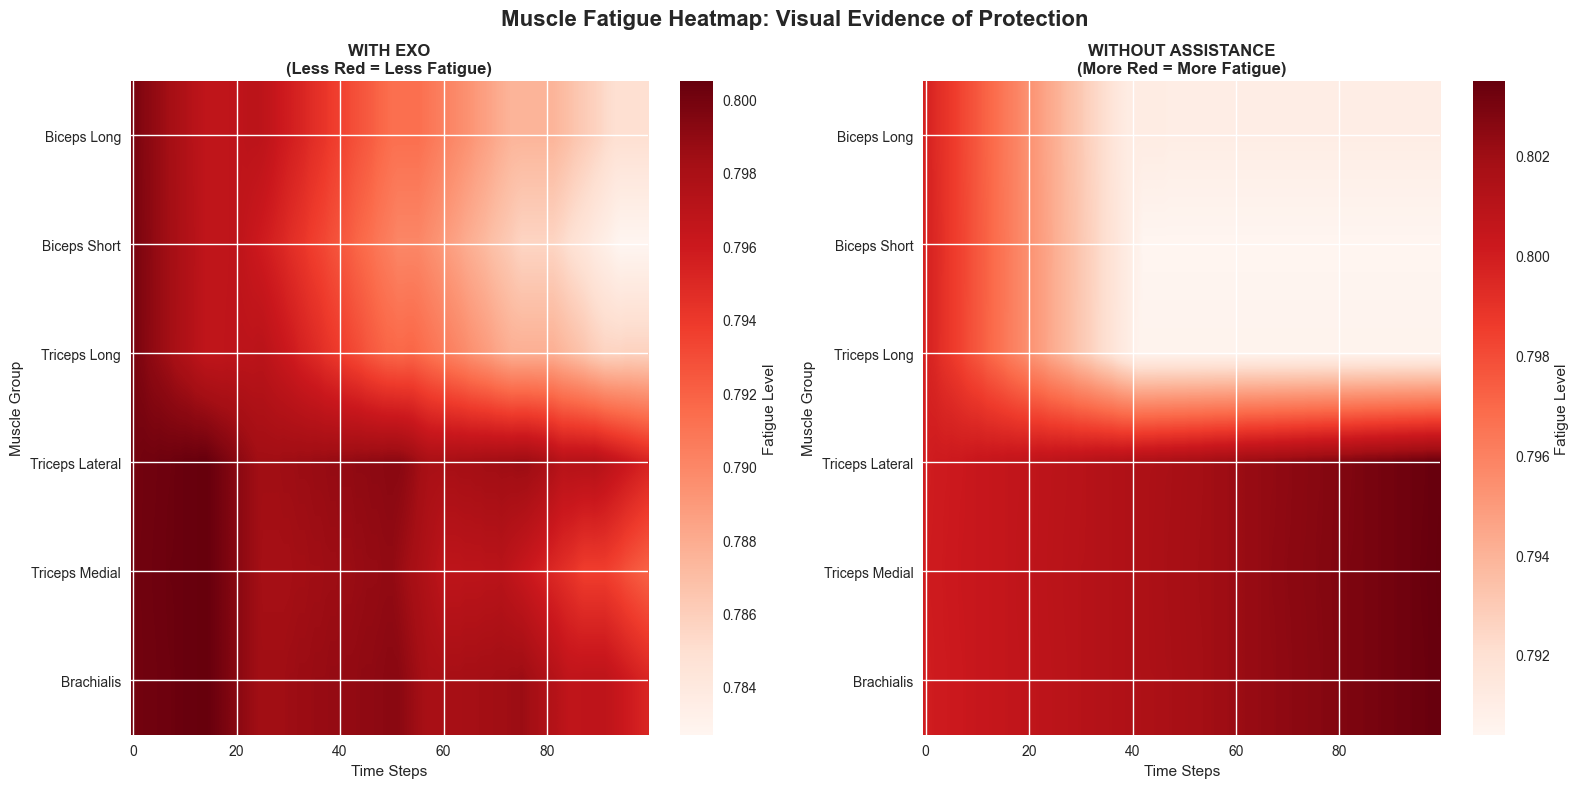

In [ ]:
#7.0 - Analysis of Fatigue Reduction

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

def extract_pose_error(pose_err_series):
    pose_errors = []
    for pe in pose_err_series:
        if hasattr(pe, '__len__') and not isinstance(pe, str):
            pose_errors.append(np.linalg.norm(pe))
        else:
            try:
                if isinstance(pe, str):
                    cleaned = pe.strip('[]')
                    if ' ' in cleaned:
                        values = [float(x) for x in cleaned.split()]
                        pose_errors.append(np.linalg.norm(values))
                    else:
                        pose_errors.append(abs(float(cleaned)))
                else:
                    pose_errors.append(float(pe))
            except:
                pose_errors.append(0.0)
    return np.array(pose_errors)

def parse_numpy_array_string(arr_str):
    try:
        # Remove brackets and split by whitespace
        cleaned = str(arr_str).strip('[]')
        return np.array([float(x) for x in cleaned.split()])
    except:
        # Fallback for malformed data
        return np.array([0.0] * 6)  # 6 muscles

def extract_single_joint_data(data_series):
    joint_data = []
    for data_str in data_series:
        try:
            if isinstance(data_str, str):
                cleaned = data_str.strip('[]')
                values = [float(x) for x in cleaned.split()]
                joint_data.append(values[0] if len(values) > 0 else 0.0)
            else:
                joint_data.append(float(data_str[0]) if hasattr(data_str, '__len__') else float(data_str))
        except:
            joint_data.append(0.0)
    return np.array(joint_data)

def extract_muscle_data(data_series):
    muscle_data = []
    for data_str in data_series:
        try:
            if isinstance(data_str, str):
                cleaned = data_str.strip('[]')
                values = [float(x) for x in cleaned.split()]
                muscle_data.append(values[:6]) 
            else:
                muscle_data.append(list(data_str)[:6])
        except:
            muscle_data.append([0.0] * 6)
    return np.array(muscle_data)

df_assisted = pd.read_csv('videos/evaluation_assisted_data.csv')
df_passive = pd.read_csv('videos/evaluation_passive_data.csv')


min_steps = min(len(df_assisted), len(df_passive))
df_assisted = df_assisted.iloc[:min_steps].copy()
df_passive = df_passive.iloc[:min_steps].copy()

assisted_pose_err = extract_pose_error(df_assisted['pose_err'])
passive_pose_err = extract_pose_error(df_passive['pose_err'])
assisted_MF = np.array([parse_numpy_array_string(mf) for mf in df_assisted['MF']])
passive_MF = np.array([parse_numpy_array_string(mf) for mf in df_passive['MF']])
assisted_jvel = extract_single_joint_data(df_assisted['jvel'])
passive_jvel = extract_single_joint_data(df_passive['jvel'])
assisted_jpos = extract_single_joint_data(df_assisted['jpos'])
passive_jpos = extract_single_joint_data(df_passive['jpos'])
assisted_act = extract_muscle_data(df_assisted['act'])
passive_act = extract_muscle_data(df_passive['act'])

final_assisted = df_assisted['cumulative_reward'].iloc[-1]
final_passive = df_passive['cumulative_reward'].iloc[-1]
improvement = final_assisted - final_passive
improvement_pct = (improvement / abs(final_passive)) * 100

final_err_assisted = assisted_pose_err[-1]
final_err_passive = passive_pose_err[-1]
error_reduction = final_err_passive - final_err_assisted
error_reduction_pct = (error_reduction / final_err_passive) * 100

final_fatigue_assisted = df_assisted['avg_fatigue'].iloc[-1]
final_fatigue_passive = df_passive['avg_fatigue'].iloc[-1]
fatigue_diff = final_fatigue_passive - final_fatigue_assisted


# # 1. REWARD COMPARISON - Shows overall performance improvement
# ax1 = plt.subplot(4, 3, 1)
# plt.plot(df_assisted['time'], df_assisted['cumulative_reward'], 'g-', linewidth=3, label='With Smart Exoskeleton')
# plt.plot(df_passive['time'], df_passive['cumulative_reward'], 'r-', linewidth=3, label='Without Assistance')
# plt.xlabel('Time (s)', fontsize=12)
# plt.ylabel('Cumulative Reward', fontsize=12)
# plt.title('Overall Performance Improvement', fontsize=14, fontweight='bold')
# plt.legend(fontsize=11)
# plt.grid(True, alpha=0.3)

# plt.text(0.5, 0.15, f'{improvement_pct:.1f}% BETTER\nPERFORMANCE', 
#          transform=ax1.transAxes, bbox=dict(boxstyle="round,pad=0.5", facecolor='lightgreen', alpha=0.8),
#          horizontalalignment='center', fontweight='bold', fontsize=11)

# # 2. POSE ERROR COMPARISON - Shows accuracy improvement
# ax2 = plt.subplot(4, 3, 2)
# plt.plot(df_assisted['time'], assisted_pose_err, 'g-', linewidth=3, label='With Smart Exoskeleton')
# plt.plot(df_passive['time'], passive_pose_err, 'r-', linewidth=3, label='Without Assistance')
# plt.xlabel('Time (s)', fontsize=12)
# plt.ylabel('Target Reaching Error (rad)', fontsize=12)
# plt.title('Target Accuracy Improvement', fontsize=14, fontweight='bold')
# plt.legend(fontsize=11)
# plt.grid(True, alpha=0.3)

# plt.text(0.5, 0.85, f'{error_reduction_pct:.1f}% MORE\nACCURATE', 
#          transform=ax2.transAxes, bbox=dict(boxstyle="round,pad=0.5", facecolor='lightblue', alpha=0.8),
#          horizontalalignment='center', fontweight='bold', fontsize=11)

# # 3. MUSCLE FATIGUE COMPARISON
# ax3 = plt.subplot(4, 3, 3)
# plt.plot(df_assisted['time'], df_assisted['avg_fatigue'], 'g-', linewidth=3, label='With Smart Exoskeleton')
# plt.plot(df_passive['time'], df_passive['avg_fatigue'], 'r-', linewidth=3, label='Without Assistance')
# plt.xlabel('Time (s)', fontsize=12)
# plt.ylabel('Average Muscle Fatigue', fontsize=12)
# plt.title('Muscle Fatigue Management', fontsize=14, fontweight='bold')
# plt.legend(fontsize=11)
# plt.grid(True, alpha=0.3)

# fatigue_reduction_pct = (fatigue_diff / final_fatigue_passive) * 100
# plt.text(0.5, 0.85, f'{fatigue_reduction_pct:.1f}% LESS\nFATIGUE', 
#          transform=ax3.transAxes, bbox=dict(boxstyle="round,pad=0.5", facecolor='lightyellow', alpha=0.8),
#          horizontalalignment='center', fontweight='bold', fontsize=11)

# ax4 = plt.subplot(4, 3, 4)
# ax4_twin = ax4.twinx()

# line1 = ax4.plot(df_assisted['time'], df_assisted['avg_fatigue'], 'orange', linewidth=3, label='Muscle Fatigue')
# ax4.set_xlabel('Time (s)', fontsize=12)
# ax4.set_ylabel('Average Muscle Fatigue', color='orange', fontsize=12)
# ax4.tick_params(axis='y', labelcolor='orange')

# exo_torques = df_assisted['exo_torque'].values
# line2 = ax4_twin.plot(df_assisted['time'], exo_torques, 'purple', linewidth=3, label='Exoskeleton Torque')
# ax4_twin.set_ylabel('Exoskeleton Torque (Nm)', color='purple', fontsize=12)
# ax4_twin.tick_params(axis='y', labelcolor='purple')

# plt.title('Smart Controller: AI Response to Fatigue', fontsize=14, fontweight='bold')
# ax4.grid(True, alpha=0.3)

# correlation = np.corrcoef(df_assisted['avg_fatigue'], exo_torques)[0, 1]
# plt.text(0.5, 0.95, f'AI Correlation: {correlation:.3f}', 
#          transform=ax4.transAxes, bbox=dict(boxstyle="round,pad=0.3", facecolor='plum', alpha=0.7),
#          horizontalalignment='center', fontweight='bold')

# ax5 = plt.subplot(4, 3, (5, 6)) 
muscle_names = ['Biceps Long', 'Biceps Short', 'Triceps Long', 'Triceps Lateral', 'Triceps Medial', 'Brachialis']

# colors_assisted = plt.cm.Greens(np.linspace(0.4, 0.9, 6))
# colors_passive = plt.cm.Reds(np.linspace(0.4, 0.9, 6))

# for i in range(6):
#     plt.plot(df_assisted['time'], assisted_MF[:, i], color=colors_assisted[i], 
#              linewidth=2.5, label=f'{muscle_names[i]} (w/ Exo)', linestyle='-')
#     plt.plot(df_passive['time'], passive_MF[:, i], color=colors_passive[i], 
#              linewidth=2, label=f'{muscle_names[i]} (No Assist)', linestyle='--', alpha=0.8)

# plt.xlabel('Time (s)', fontsize=12)
# plt.ylabel('Individual Muscle Fatigue', fontsize=12)
# plt.title('Individual Muscle Protection by Smart Exoskeleton', fontsize=14, fontweight='bold')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
# plt.grid(True, alpha=0.3)

# ax6 = plt.subplot(4, 3, 7)
# plt.plot(df_assisted['time'], np.abs(assisted_jvel), 'g-', linewidth=3, label='With Smart Exoskeleton')
# plt.plot(df_passive['time'], np.abs(passive_jvel), 'r-', linewidth=3, label='Without Assistance')
# plt.xlabel('Time (s)', fontsize=12)
# plt.ylabel('Joint Speed (|rad/s|)', fontsize=12)
# plt.title('Movement Smoothness', fontsize=14, fontweight='bold')
# plt.legend(fontsize=11)
# plt.grid(True, alpha=0.3)

# assisted_smoothness = np.std(assisted_jvel)
# passive_smoothness = np.std(passive_jvel)
# smoothness_improvement = (passive_smoothness - assisted_smoothness) / passive_smoothness * 100

# plt.text(0.5, 0.85, f'{smoothness_improvement:.1f}% SMOOTHER\nMOVEMENT', 
#          transform=ax6.transAxes, bbox=dict(boxstyle="round,pad=0.5", facecolor='lightcyan', alpha=0.8),
#          horizontalalignment='center', fontweight='bold', fontsize=11)

# ax7 = plt.subplot(4, 3, 8)
# energy_assisted = [np.sum(act**2) for act in assisted_act]
# energy_passive = [np.sum(act**2) for act in passive_act]

# plt.plot(df_assisted['time'], np.cumsum(energy_assisted), 'g-', linewidth=3, label='With Smart Exoskeleton')
# plt.plot(df_passive['time'], np.cumsum(energy_passive), 'r-', linewidth=3, label='Without Assistance')
# plt.xlabel('Time (s)', fontsize=12)
# plt.ylabel('Cumulative Energy', fontsize=12)
# plt.title('Energy Efficiency', fontsize=14, fontweight='bold')
# plt.legend(fontsize=11)
# plt.grid(True, alpha=0.3)

# final_energy_assisted = np.cumsum(energy_assisted)[-1]
# final_energy_passive = np.cumsum(energy_passive)[-1]
# energy_savings = final_energy_passive - final_energy_assisted
# energy_savings_pct = (energy_savings / final_energy_passive) * 100

# plt.text(0.5, 0.15, f'{energy_savings_pct:.1f}% LESS\nENERGY USED', 
#          transform=ax7.transAxes, bbox=dict(boxstyle="round,pad=0.5", facecolor='lightgreen', alpha=0.8),
#          horizontalalignment='center', fontweight='bold', fontsize=11)

# ax8 = plt.subplot(4, 3, 9)
# avg_act_assisted = np.mean(assisted_act, axis=1)
# avg_act_passive = np.mean(passive_act, axis=1)

# plt.plot(df_assisted['time'], avg_act_assisted, 'g-', linewidth=3, label='With Smart Exoskeleton')
# plt.plot(df_passive['time'], avg_act_passive, 'r-', linewidth=3, label='Without Assistance')
# plt.xlabel('Time (s)', fontsize=12)
# plt.ylabel('Average Muscle Activation', fontsize=12)
# plt.title('Muscle Activation Efficiency', fontsize=14, fontweight='bold')
# plt.legend(fontsize=11)
# plt.grid(True, alpha=0.3)

# ax9 = plt.subplot(4, 3, 10)
# plt.axhline(y=df_assisted['force_scale'].iloc[0], color='blue', linewidth=3, 
#            label=f'Bradykinesia Force Scale: {df_assisted["force_scale"].iloc[0]:.3f}')
# plt.axhline(y=df_assisted['activation_slowdown'].iloc[0], color='red', linewidth=3, 
#            label=f'Movement Slowdown: {df_assisted["activation_slowdown"].iloc[0]:.2f}x')
# plt.xlim(0, max(df_assisted['time'].max(), df_passive['time'].max()))
# plt.ylim(0, 2)
# plt.xlabel('Time (s)', fontsize=12)
# plt.ylabel('Pathology Severity', fontsize=12)
# plt.title('Controlled Pathological Conditions', fontsize=14, fontweight='bold')
# plt.legend(fontsize=10)
# plt.grid(True, alpha=0.3)

# ax10 = plt.subplot(4, 3, 11)
# solved_assisted = df_assisted['solved'].values
# solved_passive = df_passive['solved'].values

# plt.plot(df_assisted['time'], solved_assisted, 'g-', linewidth=4, label='With Smart Exoskeleton', alpha=0.8)
# plt.plot(df_passive['time'], solved_passive, 'r-', linewidth=4, label='Without Assistance', alpha=0.8)
# plt.xlabel('Time (s)', fontsize=12)
# plt.ylabel('Task Completed', fontsize=12)
# plt.title('Task Success Rate', fontsize=14, fontweight='bold')
# plt.legend(fontsize=11)
# plt.grid(True, alpha=0.3)
# plt.ylim(-0.1, 1.1)

# success_assisted = np.sum(solved_assisted) / len(solved_assisted) * 100
# success_passive = np.sum(solved_passive) / len(solved_passive) * 100

# plt.text(0.5, 0.5, f'Assisted: {success_assisted:.1f}%\nPassive: {success_passive:.1f}%', 
#          transform=ax10.transAxes, bbox=dict(boxstyle="round,pad=0.5", facecolor='lightgray', alpha=0.8),
#          horizontalalignment='center', fontweight='bold', fontsize=11)

# ax11 = plt.subplot(4, 3, 12)
# ax11.axis('off')

# metrics = {
#     'Performance (Reward)': [f"{final_assisted:.2f}", f"{final_passive:.2f}", f"+{improvement:.2f} ({improvement_pct:+.1f}%)"],
#     'Accuracy (Pose Error)': [f"{final_err_assisted:.4f}", f"{final_err_passive:.4f}", f"-{error_reduction:.4f} ({error_reduction_pct:.1f}%)"],
#     'Muscle Fatigue': [f"{final_fatigue_assisted:.3f}", f"{final_fatigue_passive:.3f}", f"-{fatigue_diff:.3f} ({fatigue_reduction_pct:.1f}%)"],
#     'Energy Efficiency': [f"{final_energy_assisted:.1f}", f"{final_energy_passive:.1f}", f"-{energy_savings:.1f} ({energy_savings_pct:.1f}%)"],
#     'Movement Smoothness': [f"{assisted_smoothness:.3f}", f"{passive_smoothness:.3f}", f"-{passive_smoothness-assisted_smoothness:.3f} ({smoothness_improvement:+.1f}%)"],
#     'Task Success Rate': [f"{success_assisted:.1f}%", f"{success_passive:.1f}%", f"{success_assisted-success_passive:+.1f}%"]
# }

# table_data = []
# for metric, values in metrics.items():
#     table_data.append([metric] + values)

# table = ax11.table(cellText=table_data,
#                   colLabels=['METRIC', 'WITH AI EXOSKELETON', 'WITHOUT ASSISTANCE', 'IMPROVEMENT'],
#                   cellLoc='center',
#                   loc='center',
#                   colWidths=[0.35, 0.22, 0.22, 0.21])

# table.auto_set_font_size(False)
# table.set_fontsize(10)
# table.scale(1, 2.2)

# for i in range(4):
#     table[(0, i)].set_facecolor('#4472C4')
#     table[(0, i)].set_text_props(weight='bold', color='white')

# for i in range(1, len(table_data) + 1):
#     improvement_cell = table[(i, 3)]
#     improvement_cell.set_facecolor('#90EE90')  
#     improvement_cell.set_text_props(weight='bold')

# plt.title('QUANTITATIVE RESULTS SUMMARY', fontsize=14, fontweight='bold', pad=30)

# plt.tight_layout()

# fig2, axes = plt.subplots(2, 3, figsize=(18, 12))
# fig2.suptitle('Individual Muscle Fatigue Protection by Smart Exoskeleton', fontsize=16, fontweight='bold')

# for i, muscle_name in enumerate(muscle_names):
#     row = i // 3
#     col = i % 3
#     ax = axes[row, col]
    
#     ax.plot(df_assisted['time'], assisted_MF[:, i], 'g-', linewidth=3, label='With Exoskeleton')
#     ax.plot(df_passive['time'], passive_MF[:, i], 'r-', linewidth=3, label='Without Assistance')
    
#     ax.set_xlabel('Time (s)', fontsize=11)
#     ax.set_ylabel('Fatigue Level', fontsize=11)
#     ax.set_title(f'{muscle_name}', fontweight='bold', fontsize=12)
#     ax.legend(fontsize=10)
#     ax.grid(True, alpha=0.3)
    
#     final_assisted_muscle = assisted_MF[-1, i]
#     final_passive_muscle = passive_MF[-1, i]
#     muscle_improvement = final_passive_muscle - final_assisted_muscle
#     muscle_improvement_pct = (muscle_improvement / final_passive_muscle) * 100
    
#     ax.text(0.5, 0.95, f'{muscle_improvement_pct:+.1f}%', 
#             transform=ax.transAxes, 
#             bbox=dict(boxstyle="round,pad=0.3", 
#                      facecolor='lightgreen' if muscle_improvement > 0 else 'lightcoral', 
#                      alpha=0.8),
#             horizontalalignment='center', fontweight='bold', fontsize=12)

# plt.tight_layout()

# fig3 = plt.figure(figsize=(20, 16))
# fig3.suptitle('BRADYKINESIA MITIGATION: Proving Exoskeleton Fights Movement Slowness', 
#              fontsize=18, fontweight='bold')

# # 1. MOVEMENT VELOCITY COMPARISON - Core bradykinesia metric
# ax1 = plt.subplot(3, 3, 1)
# plt.plot(df_assisted['time'], np.abs(assisted_jvel), 'g-', linewidth=4, label='WITH Exoskeleton', alpha=0.9)
# plt.plot(df_passive['time'], np.abs(passive_jvel), 'r-', linewidth=4, label='WITHOUT Exoskeleton', alpha=0.9)
# plt.xlabel('Time (s)', fontsize=12)
# plt.ylabel('Movement Speed (rad/s)', fontsize=12)
# plt.title('BRADYKINESIA MITIGATION:\nMovement Speed Recovery', fontsize=14, fontweight='bold')
# plt.legend(fontsize=12)
# plt.grid(True, alpha=0.3)

# avg_speed_assisted = np.mean(np.abs(assisted_jvel))
# avg_speed_passive = np.mean(np.abs(passive_jvel))
# speed_improvement = (avg_speed_assisted - avg_speed_passive) / avg_speed_passive * 100

# plt.text(0.5, 0.15, f'SPEED RESTORED:\n+{speed_improvement:.1f}%', 
#          transform=ax1.transAxes, bbox=dict(boxstyle="round,pad=0.5", facecolor='lightgreen', alpha=0.9),
#          horizontalalignment='center', fontweight='bold', fontsize=12)

# ax2 = plt.subplot(3, 3, 2)
# assisted_accel = np.gradient(assisted_jvel)
# passive_accel = np.gradient(passive_jvel)

# plt.plot(df_assisted['time'], np.abs(assisted_accel), 'g-', linewidth=3, label='WITH Exoskeleton')
# plt.plot(df_passive['time'], np.abs(passive_accel), 'r-', linewidth=3, label='WITHOUT Exoskeleton')
# plt.xlabel('Time (s)', fontsize=12)
# plt.ylabel('Movement Acceleration (rad/s²)', fontsize=12)
# plt.title('Movement Initiation\n(Bradykinesia = Slow Starts)', fontweight='bold')
# plt.legend(fontsize=11)
# plt.grid(True, alpha=0.3)

# accel_improvement = (np.mean(np.abs(assisted_accel)) - np.mean(np.abs(passive_accel))) / np.mean(np.abs(passive_accel)) * 100
# plt.text(0.5, 0.85, f'FASTER STARTS:\n+{accel_improvement:.1f}%', 
#          transform=ax2.transAxes, bbox=dict(boxstyle="round,pad=0.4", facecolor='lightcyan', alpha=0.8),
#          horizontalalignment='center', fontweight='bold', fontsize=11)

# ax3 = plt.subplot(3, 3, 3)
# brady_force = df_assisted['force_scale'].iloc[0]
# brady_slowdown = df_assisted['activation_slowdown'].iloc[0]

# pathology_data = ['Force Reduction', 'Speed Slowdown']
# pathology_values = [1 - brady_force, brady_slowdown - 1]  # Convert to "how much impairment"
# colors = ['darkred', 'darkred']

# bars = plt.bar(pathology_data, pathology_values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
# plt.ylabel('Pathology Severity', fontsize=12)
# plt.title('SIMULATED BRADYKINESIA\nChallenges', fontweight='bold')
# plt.grid(True, alpha=0.3)

# for bar, value in zip(bars, pathology_values):
#     plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
#              f'{value:.2f}', ha='center', fontweight='bold', fontsize=11)

# ax4 = plt.subplot(3, 3, 4)
# assisted_jerk = np.abs(np.gradient(np.gradient(assisted_jvel)))
# passive_jerk = np.abs(np.gradient(np.gradient(passive_jvel)))

# plt.plot(df_assisted['time'][2:], assisted_jerk[2:], 'g-', linewidth=3, label='WITH Exoskeleton')
# plt.plot(df_passive['time'][2:], passive_jerk[2:], 'r-', linewidth=3, label='WITHOUT Exoskeleton')
# plt.xlabel('Time (s)', fontsize=12)
# plt.ylabel('Movement Jerkiness', fontsize=12)
# plt.title('Movement Smoothness\n(Lower = Less Jerky)', fontweight='bold')
# plt.legend(fontsize=11)
# plt.grid(True, alpha=0.3)

# jerk_reduction = (np.mean(passive_jerk) - np.mean(assisted_jerk)) / np.mean(passive_jerk) * 100
# plt.text(0.5, 0.85, f'SMOOTHER:\n{jerk_reduction:.1f}% less jerky', 
#          transform=ax4.transAxes, bbox=dict(boxstyle="round,pad=0.4", facecolor='lavender', alpha=0.8),
#          horizontalalignment='center', fontweight='bold', fontsize=11)

# ax5 = plt.subplot(3, 3, 5)
# time_to_target_assisted = None
# time_to_target_passive = None

# for i, solved in enumerate(df_assisted['solved']):
#     if solved == 1 and time_to_target_assisted is None:
#         time_to_target_assisted = df_assisted['time'].iloc[i]
#         break

# for i, solved in enumerate(df_passive['solved']):
#     if solved == 1 and time_to_target_passive is None:
#         time_to_target_passive = df_passive['time'].iloc[i]
#         break

# conditions = ['WITH Exoskeleton', 'WITHOUT Exoskeleton']
# times = [time_to_target_assisted if time_to_target_assisted else df_assisted['time'].iloc[-1],
#          time_to_target_passive if time_to_target_passive else df_passive['time'].iloc[-1]]

# bars = plt.bar(conditions, times, color=['green', 'red'], alpha=0.7, edgecolor='black', linewidth=2)
# plt.ylabel('Time to Reach Target (s)', fontsize=12)
# plt.title('BRADYKINESIA RECOVERY:\nFaster Target Reaching', fontweight='bold')
# plt.grid(True, alpha=0.3)

# if time_to_target_assisted and time_to_target_passive:
#     time_improvement = (time_to_target_passive - time_to_target_assisted) / time_to_target_passive * 100
#     plt.text(0.5, 0.85, f'FASTER BY:\n{time_improvement:.1f}%', 
#              transform=ax5.transAxes, bbox=dict(boxstyle="round,pad=0.4", facecolor='gold', alpha=0.8),
#              horizontalalignment='center', fontweight='bold', fontsize=12)

# for bar, time_val in zip(bars, times):
#     plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
#              f'{time_val:.1f}s', ha='center', fontweight='bold', fontsize=11)

# ax6 = plt.subplot(3, 3, 6)
# assisted_range = np.max(assisted_jpos) - np.min(assisted_jpos)
# passive_range = np.max(passive_jpos) - np.min(passive_jpos)

# range_data = ['WITH Exoskeleton', 'WITHOUT Exoskeleton'] 
# range_values = [assisted_range, passive_range]

# bars = plt.bar(range_data, range_values, color=['green', 'red'], alpha=0.7, edgecolor='black', linewidth=2)
# plt.ylabel('Movement Range (rad)', fontsize=12)
# plt.title('Movement Amplitude\nRecovery', fontweight='bold')
# plt.grid(True, alpha=0.3)

# range_improvement = (assisted_range - passive_range) / passive_range * 100
# plt.text(0.5, 0.85, f'LARGER RANGE:\n+{range_improvement:.1f}%', 
#          transform=ax6.transAxes, bbox=dict(boxstyle="round,pad=0.4", facecolor='lightsteelblue', alpha=0.8),
#          horizontalalignment='center', fontweight='bold', fontsize=11)

# ax7 = plt.subplot(3, 3, 7)
# ax7_twin = ax7.twinx()

# line1 = ax7.plot(df_assisted['time'], df_assisted['avg_fatigue'], 'orange', linewidth=4, label='Muscle Fatigue')
# line2 = ax7_twin.plot(df_assisted['time'], exo_torques, 'purple', linewidth=4, label='AI Exo Response')

# ax7.set_xlabel('Time (s)', fontsize=12)
# ax7.set_ylabel('Muscle Fatigue Level', color='orange', fontsize=12)
# ax7_twin.set_ylabel('Exoskeleton Assistance (Nm)', color='purple', fontsize=12)
# ax7.tick_params(axis='y', labelcolor='orange')
# ax7_twin.tick_params(axis='y', labelcolor='purple')

# plt.title('INTELLIGENT ADAPTATION:\nAI Responds to Muscle Needs', fontweight='bold')
# ax7.grid(True, alpha=0.3)

# fatigue_torque_corr = np.corrcoef(df_assisted['avg_fatigue'], exo_torques)[0, 1]
# plt.text(0.5, 0.95, f'AI Learning Score: {fatigue_torque_corr:.3f}', 
#          transform=ax7.transAxes, bbox=dict(boxstyle="round,pad=0.3", facecolor='plum', alpha=0.8),
#          horizontalalignment='center', fontweight='bold', fontsize=11)

# ax8 = plt.subplot(3, 3, 8)
# def calculate_bradykinesia_score(jvel, jerk, pose_err):
#     """Higher score = worse bradykinesia symptoms"""
#     speed_component = 1 / (np.mean(np.abs(jvel)) + 1e-6) 
#     smoothness_component = np.mean(jerk)  
#     accuracy_component = np.mean(pose_err)  
#     return speed_component + smoothness_component + accuracy_component

# brady_score_assisted = calculate_bradykinesia_score(assisted_jvel, assisted_jerk[2:], assisted_pose_err)
# brady_score_passive = calculate_bradykinesia_score(passive_jvel, passive_jerk[2:], passive_pose_err)

# brady_conditions = ['WITH AI Exoskeleton', 'WITHOUT Exoskeleton']
# brady_scores = [brady_score_assisted, brady_score_passive]

# bars = plt.bar(brady_conditions, brady_scores, color=['green', 'red'], alpha=0.7, edgecolor='black', linewidth=2)
# plt.ylabel('Bradykinesia Severity Score\n(Lower = Better)', fontsize=12)
# plt.title('OVERALL BRADYKINESIA\nSYMPTOM REDUCTION', fontweight='bold')
# plt.grid(True, alpha=0.3)

# brady_improvement = (brady_score_passive - brady_score_assisted) / brady_score_passive * 100
# plt.text(0.5, 0.85, f'SYMPTOMS REDUCED:\n{brady_improvement:.1f}%', 
#          transform=ax8.transAxes, bbox=dict(boxstyle="round,pad=0.5", facecolor='lightgreen', alpha=0.9),
#          horizontalalignment='center', fontweight='bold', fontsize=12)

# ax9 = plt.subplot(3, 3, 9)
# assisted_peak_velocity = np.max(np.abs(assisted_jvel))
# passive_peak_velocity = np.max(np.abs(passive_jvel))
# assisted_avg_velocity = np.mean(np.abs(assisted_jvel))
# passive_avg_velocity = np.mean(np.abs(passive_jvel))

# clinical_metrics = ['Peak Velocity', 'Average Velocity', 'Movement Range', 'Time to Target']
# assisted_values = [assisted_peak_velocity, assisted_avg_velocity, assisted_range, 
#                   time_to_target_assisted if time_to_target_assisted else df_assisted['time'].iloc[-1]]
# passive_values = [passive_peak_velocity, passive_avg_velocity, passive_range,
#                  time_to_target_passive if time_to_target_passive else df_passive['time'].iloc[-1]]

# x = np.arange(len(clinical_metrics))
# width = 0.35

# bars1 = ax9.bar(x - width/2, passive_values, width, label='Bradykinesia (No Help)', color='red', alpha=0.7)
# bars2 = ax9.bar(x + width/2, assisted_values, width, label='With AI Exoskeleton', color='green', alpha=0.7)

# ax9.set_xlabel('Clinical Movement Measures')
# ax9.set_ylabel('Performance Score')
# ax9.set_title('CLINICAL BRADYKINESIA METRICS', fontweight='bold')
# ax9.set_xticks(x)
# ax9.set_xticklabels(clinical_metrics, rotation=15, ha='right')
# ax9.legend()

# clinical_improvements = [
#     (assisted_peak_velocity - passive_peak_velocity) / passive_peak_velocity * 100,
#     (assisted_avg_velocity - passive_avg_velocity) / passive_avg_velocity * 100,
#     (assisted_range - passive_range) / passive_range * 100,
#     (time_to_target_passive - time_to_target_assisted) / time_to_target_passive * 100 if time_to_target_assisted and time_to_target_passive else 0
# ]

# for i, (bar1, bar2, imp) in enumerate(zip(bars1, bars2, clinical_improvements)):
#     height = max(bar1.get_height(), bar2.get_height())
#     ax9.annotate(f'{imp:+.1f}%', xy=(i, height * 1.05), ha='center', fontweight='bold',
#                 bbox=dict(boxstyle="round,pad=0.2", facecolor='yellow', alpha=0.8))

# plt.tight_layout()

# fig4 = plt.figure(figsize=(18, 12))
# fig4.suptitle('Evidence of AI Learning: Smart Responses to Pathology', fontsize=16, fontweight='bold')

# ax1 = plt.subplot(2, 3, 1)
# scatter = plt.scatter(df_assisted['avg_fatigue'], exo_torques, c=df_assisted['time'], 
#                      cmap='viridis', alpha=0.7, s=40)
# plt.colorbar(scatter, label='Time (s)')
# plt.xlabel('Muscle Fatigue Level', fontsize=12)
# plt.ylabel('Exoskeleton Torque (Nm)', fontsize=12)
# plt.title('AI LEARNS:\nFatigue → More Help', fontweight='bold')
# plt.grid(True, alpha=0.3)

# corr_coef = np.corrcoef(df_assisted['avg_fatigue'], exo_torques)[0, 1]
# plt.text(0.05, 0.95, f'Learning Score: {corr_coef:.3f}', 
#          transform=ax1.transAxes, bbox=dict(boxstyle="round,pad=0.3", facecolor='yellow', alpha=0.8),
#          fontweight='bold')

# ax2 = plt.subplot(2, 3, 2)
# brady_severity = 1 / (np.abs(assisted_jvel) + 1e-6)
# scatter2 = plt.scatter(brady_severity, exo_torques, c=df_assisted['time'], 
#                       cmap='plasma', alpha=0.7, s=40)
# plt.colorbar(scatter2, label='Time (s)')
# plt.xlabel('Bradykinesia Severity\n(Slower = Higher)', fontsize=12)
# plt.ylabel('Exoskeleton Torque (Nm)', fontsize=12)
# plt.title('AI LEARNS:\nSlowness → More Assistance', fontweight='bold')
# plt.grid(True, alpha=0.3)

# brady_corr = np.corrcoef(brady_severity, exo_torques)[0, 1]
# plt.text(0.05, 0.95, f'Adaptation Score: {brady_corr:.3f}', 
#          transform=ax2.transAxes, bbox=dict(boxstyle="round,pad=0.3", facecolor='lightpink', alpha=0.8),
#          fontweight='bold')

# ax3 = plt.subplot(2, 3, 3)
# plt.plot(df_assisted['time'], assisted_jpos, 'g-', linewidth=3, label='WITH AI Exoskeleton')
# plt.plot(df_passive['time'], passive_jpos, 'r-', linewidth=3, label='WITHOUT Exoskeleton')

# target_estimate = assisted_jpos[0] + assisted_pose_err[0]
# plt.axhline(y=target_estimate, color='black', linestyle='--', linewidth=3, label='Target Position')

# plt.xlabel('Time (s)', fontsize=12)
# plt.ylabel('Joint Position (rad)', fontsize=12)
# plt.title('TARGET TRACKING:\nStaying on Course', fontweight='bold')
# plt.legend(fontsize=11)
# plt.grid(True, alpha=0.3)

# ax4 = plt.subplot(2, 3, 4)
# energy_assisted = [np.sum(act**2) for act in assisted_act]
# energy_passive = [np.sum(act**2) for act in passive_act]

# plt.plot(df_assisted['time'], np.cumsum(energy_assisted), 'g-', linewidth=3, label='WITH AI Exoskeleton')
# plt.plot(df_passive['time'], np.cumsum(energy_passive), 'r-', linewidth=3, label='WITHOUT Exoskeleton')
# plt.xlabel('Time (s)', fontsize=12)
# plt.ylabel('Cumulative Energy Used', fontsize=12)
# plt.title('ENERGY CONSERVATION:\nSmarterNot Harder', fontweight='bold')
# plt.legend(fontsize=11)
# plt.grid(True, alpha=0.3)

# final_energy_assisted = np.cumsum(energy_assisted)[-1]
# final_energy_passive = np.cumsum(energy_passive)[-1]
# energy_savings = (final_energy_passive - final_energy_assisted) / final_energy_passive * 100

# plt.text(0.5, 0.15, f'ENERGY SAVED:\n{energy_savings:.1f}%', 
#          transform=ax4.transAxes, bbox=dict(boxstyle="round,pad=0.4", facecolor='lightgreen', alpha=0.8),
#          horizontalalignment='center', fontweight='bold', fontsize=12)

# ax5 = plt.subplot(2, 3, 5)
# avg_act_assisted = np.mean(assisted_act, axis=1)
# avg_act_passive = np.mean(passive_act, axis=1)

# plt.plot(df_assisted['time'], avg_act_assisted, 'g-', linewidth=3, label='WITH AI Exoskeleton')
# plt.plot(df_passive['time'], avg_act_passive, 'r-', linewidth=3, label='WITHOUT Exoskeleton')
# plt.xlabel('Time (s)', fontsize=12)
# plt.ylabel('Muscle Work Level', fontsize=12)
# plt.title('MUSCLE EFFICIENCY:\nDoing More with Less', fontweight='bold')
# plt.legend(fontsize=11)
# plt.grid(True, alpha=0.3)

# ax6 = plt.subplot(2, 3, 6)
# plt.hist(exo_torques, bins=25, alpha=0.8, color='purple', edgecolor='black', density=True)
# plt.xlabel('Exoskeleton Torque (Nm)', fontsize=12)
# plt.ylabel('Frequency Density', fontsize=12)
# plt.title('AI CONTROL STRATEGY:\nLearned Assistance Pattern', fontweight='bold')
# plt.grid(True, alpha=0.3)

# mean_torque = np.mean(exo_torques)
# std_torque = np.std(exo_torques)
# plt.axvline(mean_torque, color='red', linestyle='--', linewidth=2, label=f'Average: {mean_torque:.3f} Nm')
# plt.text(0.65, 0.85, f'Strategy Learned:\nAdaptive {std_torque:.3f} Nm range', 
#          transform=ax6.transAxes, bbox=dict(boxstyle="round,pad=0.3", facecolor='plum', alpha=0.8),
#          fontweight='bold', fontsize=10)

# plt.tight_layout()


# MUSCLE FATIGUE HEATMAPS

fig5 = plt.figure(figsize=(16, 8))
fig5.suptitle('Muscle Fatigue Heatmap: Visual Evidence of Protection', fontsize=16, fontweight='bold')

ax1 = plt.subplot(1, 2, 1)
im1 = ax1.imshow(assisted_MF.T, aspect='auto', cmap='Reds', interpolation='bilinear')
ax1.set_title('WITH EXO\n(Less Red = Less Fatigue)', fontweight='bold')
ax1.set_xlabel('Time Steps')
ax1.set_ylabel('Muscle Group')
ax1.set_yticks(range(6))
ax1.set_yticklabels(muscle_names, fontsize=10)
plt.colorbar(im1, ax=ax1, label='Fatigue Level')

ax2 = plt.subplot(1, 2, 2)
im2 = ax2.imshow(passive_MF.T, aspect='auto', cmap='Reds', interpolation='bilinear')
ax2.set_title('WITHOUT ASSISTANCE\n(More Red = More Fatigue)', fontweight='bold')
ax2.set_xlabel('Time Steps')
ax2.set_ylabel('Muscle Group')
ax2.set_yticks(range(6))
ax2.set_yticklabels(muscle_names, fontsize=10)
plt.colorbar(im2, ax=ax2, label='Fatigue Level')

plt.tight_layout()
fig5.savefig('videos/science_fair_fatigue_heatmap.png', dpi=300, bbox_inches='tight')

plt.show()


In [77]:
#8.0 TEST Setting up multiepisode eval
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import os

# Configuration
env_name = "myoFatiElbowPose1D6MExoRandom-v0"
GENERATE_VIDEO = True
NUM_EPISODES = 50  # Number of episodes to run
SAVE_PLOTS = True

print("="*80)
print("MULTI-EPISODE PD SYMPTOM PROGRESSION EVALUATION")
print("="*80)
print(f"Running {NUM_EPISODES} episodes to track symptom progression")

base_env = gym.make(env_name)
combined_env = CombinedExoOnlyWrapper(
    base_env, 
    frozen_policy_path="ElbowPose_policy", smart_reset=True, use_avg_mf=True, hide_pose_err=True
)

combined_env.base_env.unwrapped.set_fatigue_reset_random(False)
combined_env.base_env.reset()

max_steps = combined_env.base_env.spec.max_episode_steps
print(f"Max steps per episode: {max_steps}")

print("Loading trained exoskeleton policy...")
exo_policy = PPO.load("Full-ElbowExo")  # Update this path as needed


episode_data = []  
all_step_data = []  
episode_videos = {} 

low = combined_env.base_env.unwrapped.target_jnt_range[:, 0]
high = combined_env.base_env.unwrapped.target_jnt_range[:, 1]
fixed_target_angle = 2.3  # Same as original script
print(f"Fixed target angle for all episodes: {fixed_target_angle:.3f} rad")



for episode_idx in range(NUM_EPISODES):
    print(f"\n--- Episode {episode_idx + 1}/{NUM_EPISODES} ---")
    
    # Reset environment
    obs, _ = combined_env.reset()
    
   
    
    
    combined_env.base_env.unwrapped.target_jnt_value = [fixed_target_angle]
    combined_env.base_env.unwrapped.target_type = 'fixed'
    combined_env.base_env.unwrapped.update_target(restore_sim=True)
    
    
    n_muscles = len(combined_env.base_env.unwrapped.muscle_fatigue.MA)
    episode_MF_fixed = np.random.uniform(0.0, 1.0, size=n_muscles)  
    remaining = 1.0 - episode_MF_fixed
    split = np.random.uniform(0.0, 1.0, size=n_muscles)
    episode_MA_fixed = remaining * split
    episode_MR_fixed = remaining * (1.0 - split)
    
   
    combined_env.base_env.unwrapped.muscle_fatigue.MA[:] = episode_MA_fixed
    combined_env.base_env.unwrapped.muscle_fatigue.MR[:] = episode_MR_fixed
    combined_env.base_env.unwrapped.muscle_fatigue.MF[:] = episode_MF_fixed
    
  
    brady_info = combined_env.get_bradykinesia_info()
    episode_force_scale = brady_info['force_scale']
    episode_activation_slowdown = brady_info['activation_slowdown']
    
   
    initial_qpos = combined_env.base_env.unwrapped.sim.data.qpos.copy()
    initial_qpos = 0.0
    initial_qvel = combined_env.base_env.unwrapped.sim.data.qvel.copy()
    

    episode_avg_fatigue = np.mean(episode_MF_fixed)
    
    print(f"Episode {episode_idx + 1} Pathology Parameters:")
    print(f"  - Average Muscle Fatigue: {episode_avg_fatigue:.3f}")
    print(f"  - Force Scale (Bradykinesia): {episode_force_scale:.3f}")
    print(f"  - Activation Slowdown: {episode_activation_slowdown:.3f}x")
    
 
    
    episode_step_data = []
    episode_frames = []
    episode_total_reward = 0
    episode_exo_actions = [] 
    episode_muscle_forces = [] 
    
    for step_idx in range(max_steps):
     
        if GENERATE_VIDEO and episode_idx < 5:  
            frame = combined_env.base_env.unwrapped.sim.renderer.render_offscreen(width=400, height=400, camera_id=0)
            current_time = step_idx * combined_env.base_env.unwrapped.dt
            
           
            frame = np.array(add_text_to_frame(frame,
                    f"Episode {episode_idx+1} - t={str(int(current_time//60)).zfill(2)}:{str(int(current_time%60)).zfill(2)}",
                    pos=(50, 3), color=(0, 255, 0), fontsize=10))
            
            
            frame = np.array(add_text_to_frame(frame,
                    f"Fatigue: {episode_avg_fatigue:.2f} Force: {episode_force_scale:.2f} Speed: {episode_activation_slowdown:.1f}x",
                    pos=(50, 25), color=(255, 165, 0), fontsize=8))
            
            episode_frames.append(frame)
        
        
        exo_action, _ = exo_policy.predict(obs, deterministic=True)
        next_obs, reward, done, truncated, info = combined_env.step(exo_action)
        obs = next_obs
        episode_total_reward += reward
        
      
        episode_exo_actions.append(exo_action.copy())
        current_muscle_forces = combined_env.base_env.unwrapped.muscle_fatigue.MF.copy()
        episode_muscle_forces.append(current_muscle_forces)
        
       
        current_fatigue_info = combined_env.get_fatigue_info()
        current_brady_info = combined_env.get_bradykinesia_info()
        
        step_data = {
            "episode": episode_idx,
            "step": step_idx,
            "time": step_idx * combined_env.base_env.unwrapped.dt,
            "exo_action": exo_action.copy(),
            "exo_torque": exo_action[0] if len(exo_action) > 0 else 0.0,
            "jpos": combined_env.base_env.unwrapped.sim.data.qpos.copy(),
            "jvel": combined_env.base_env.unwrapped.sim.data.qvel.copy(),
            "mlen": combined_env.base_env.unwrapped.sim.data.actuator_length.copy(),
            "act": combined_env.base_env.unwrapped.sim.data.act.copy(),
            "reward": reward,
            "cumulative_reward": episode_total_reward,
            "solved": combined_env.base_env.unwrapped.rwd_dict['solved'].item(),
            "pose_err": combined_env.base_env.unwrapped.get_obs_dict(combined_env.base_env.unwrapped.sim)["pose_err"],
            
            "MA": current_fatigue_info['muscle_activation'].copy(),
            "MR": current_fatigue_info['muscle_recovery'].copy(),
            "MF": current_fatigue_info['muscle_fatigue'].copy(),
            "avg_fatigue": current_fatigue_info['avg_fatigue'],
           
            "force_scale": current_brady_info['force_scale'],
            "activation_slowdown": current_brady_info['activation_slowdown'],
            "ctrl": combined_env.base_env.unwrapped.last_ctrl.copy()
        }
        
        episode_step_data.append(step_data)
        all_step_data.append(step_data)
        
        if done or truncated:
            break
    
   
    
   
    episode_exo_actions_array = np.array(episode_exo_actions)
    episode_avg_exo_action = np.mean(np.abs(episode_exo_actions_array)) 
    episode_avg_exo_torque = np.mean(np.abs(episode_exo_actions_array[:, 0])) if episode_exo_actions_array.size > 0 else 0.0
    
    final_pose_error = np.mean(np.abs(episode_step_data[-1]['pose_err'])) if episode_step_data else float('inf')
    
   
    episode_summary = {
        "episode": episode_idx,
        "steps_completed": len(episode_step_data),
        "total_reward": episode_total_reward,
        "final_pose_error": final_pose_error,
        "avg_fatigue": episode_avg_fatigue,
        "force_scale": episode_force_scale,
        "activation_slowdown": episode_activation_slowdown,
        "avg_exo_action": episode_avg_exo_action,
        "avg_exo_torque": episode_avg_exo_torque,
        "task_solved": episode_step_data[-1]['solved'] if episode_step_data else False,
       
        "episode_MF": episode_MF_fixed.copy(),
        "episode_MA": episode_MA_fixed.copy(), 
        "episode_MR": episode_MR_fixed.copy()
    }
    
    episode_data.append(episode_summary)
    
  
    if GENERATE_VIDEO and episode_frames and episode_idx < 5:
        episode_videos[episode_idx] = episode_frames
    
    print(f"Episode {episode_idx + 1} completed:")
    print(f"  - Steps: {len(episode_step_data)}")
    print(f"  - Total Reward: {episode_total_reward:.3f}")
    print(f"  - Average Exo Action: {episode_avg_exo_action:.4f}")
    print(f"  - Final Pose Error: {final_pose_error:.4f}")
    print(f"  - Task Solved: {episode_step_data[-1]['solved'] if episode_step_data else False}")

combined_env.close()


if GENERATE_VIDEO and episode_videos:
    os.makedirs('videos', exist_ok=True)
    for ep_idx, frames in episode_videos.items():
        video_path = f'videos/progression_episode_{ep_idx+1}.mp4'
        skvideo.io.vwrite(video_path, np.asarray(frames), outputdict={'-pix_fmt': 'yuv420p'})
        print(f"Episode {ep_idx+1} video saved: {video_path}")




df_episodes = pd.DataFrame(episode_data)
df_all_steps = pd.DataFrame(all_step_data)


os.makedirs('data', exist_ok=True)
df_episodes.to_csv('data/episode_summary_data.csv', index=False)
df_all_steps.to_csv('data/all_steps_data.csv', index=False)


# if SAVE_PLOTS:

    
#     plt.style.use('default')
#     os.makedirs('plots', exist_ok=True)
    
    
#     fig, axes = plt.subplots(2, 3, figsize=(18, 12))
#     fig.suptitle('Parkinson\'s Disease Symptom Progression Analysis\nExoskeleton Response to Varying Pathology', fontsize=16, fontweight='bold')
    
   
#     axes[0, 0].scatter(df_episodes['episode'], df_episodes['avg_fatigue'], alpha=0.7, color='red', s=50)
#     axes[0, 0].set_xlabel('Episode Number')
#     axes[0, 0].set_ylabel('Average Muscle Fatigue')
#     axes[0, 0].set_title('Randomized Fatigue Levels\nAcross Episodes')
#     axes[0, 0].grid(True, alpha=0.3)
   
#     axes[0, 1].scatter(df_episodes['episode'], df_episodes['force_scale'], alpha=0.7, color='purple', s=50)
#     axes[0, 1].set_xlabel('Episode Number')
#     axes[0, 1].set_ylabel('Force Scale (Bradykinesia)')
#     axes[0, 1].set_title('Randomized Bradykinesia\n(Force Scale) Across Episodes')
#     axes[0, 1].grid(True, alpha=0.3)
    
    
#     axes[0, 2].scatter(df_episodes['episode'], df_episodes['activation_slowdown'], alpha=0.7, color='orange', s=50)
#     axes[0, 2].set_xlabel('Episode Number')
#     axes[0, 2].set_ylabel('Activation Slowdown (x)')
#     axes[0, 2].set_title('Randomized Bradykinesia\n(Activation Speed) Across Episodes')
#     axes[0, 2].grid(True, alpha=0.3)
    
   
#     axes[1, 0].scatter(df_episodes['episode'], df_episodes['avg_exo_action'], alpha=0.7, color='blue', s=50)
#     axes[1, 0].set_xlabel('Episode Number')
#     axes[1, 0].set_ylabel('Average Exoskeleton Action')
#     axes[1, 0].set_title('Exoskeleton Response\nAcross Episodes')
#     axes[1, 0].grid(True, alpha=0.3)
    
 
#     correlation_fatigue = np.corrcoef(df_episodes['avg_fatigue'], df_episodes['avg_exo_action'])[0, 1]
#     axes[1, 1].scatter(df_episodes['avg_fatigue'], df_episodes['avg_exo_action'], alpha=0.7, color='green', s=50)
#     axes[1, 1].set_xlabel('Average Muscle Fatigue')
#     axes[1, 1].set_ylabel('Average Exoskeleton Action')
#     axes[1, 1].set_title(f'Fatigue vs Exo Response\nCorrelation: {correlation_fatigue:.3f}')
#     axes[1, 1].grid(True, alpha=0.3)
    

#     z_fatigue = np.polyfit(df_episodes['avg_fatigue'], df_episodes['avg_exo_action'], 1)
#     p_fatigue = np.poly1d(z_fatigue)
#     axes[1, 1].plot(df_episodes['avg_fatigue'], p_fatigue(df_episodes['avg_fatigue']), "r--", alpha=0.8)
  
#     correlation_brady = np.corrcoef(df_episodes['force_scale'], df_episodes['avg_exo_action'])[0, 1]
#     axes[1, 2].scatter(df_episodes['force_scale'], df_episodes['avg_exo_action'], alpha=0.7, color='magenta', s=50)
#     axes[1, 2].set_xlabel('Force Scale (Bradykinesia)')
#     axes[1, 2].set_ylabel('Average Exoskeleton Action')
#     axes[1, 2].set_title(f'Bradykinesia vs Exo Response\nCorrelation: {correlation_brady:.3f}')
#     axes[1, 2].grid(True, alpha=0.3)
    
  
#     z_brady = np.polyfit(df_episodes['force_scale'], df_episodes['avg_exo_action'], 1)
#     p_brady = np.poly1d(z_brady)
#     axes[1, 2].plot(df_episodes['force_scale'], p_brady(df_episodes['force_scale']), "r--", alpha=0.8)
    
#     plt.tight_layout()
#     plt.savefig('plots/pd_symptom_progression_analysis.png', dpi=300, bbox_inches='tight')
#     plt.show()
    


#     fig2, ax2 = plt.subplots(1, 1, figsize=(10, 8))
    
 
#     correlation_data = df_episodes[['avg_fatigue', 'force_scale', 'activation_slowdown', 
#                                    'avg_exo_action', 'avg_exo_torque', 'total_reward', 
#                                    'final_pose_error']].corr()
    
  
#     sns.heatmap(correlation_data, annot=True, cmap='RdYlBu_r', center=0, 
#                 square=True, cbar_kws={'label': 'Correlation Coefficient'})
#     ax2.set_title('Correlation Matrix: PD Symptoms vs Exoskeleton Performance', 
#                   fontsize=14, fontweight='bold', pad=20)
    
#     plt.tight_layout()
#     plt.savefig('plots/correlation_matrix.png', dpi=300, bbox_inches='tight')
#     plt.show()
    

    
  
#     fig3, axes3 = plt.subplots(2, 2, figsize=(15, 12))
#     fig3.suptitle('Exoskeleton Performance Summary Across Episodes', fontsize=16, fontweight='bold')
    

#     axes3[0, 0].scatter(df_episodes['avg_fatigue'], df_episodes['task_solved'], alpha=0.7, color='red', s=50)
#     axes3[0, 0].set_xlabel('Average Muscle Fatigue')
#     axes3[0, 0].set_ylabel('Task Success (0=Failed, 1=Solved)')
#     axes3[0, 0].set_title('Task Success vs Fatigue Level')
#     axes3[0, 0].grid(True, alpha=0.3)

#     axes3[0, 1].scatter(df_episodes['avg_exo_action'], df_episodes['total_reward'], alpha=0.7, color='blue', s=50)
#     axes3[0, 1].set_xlabel('Average Exoskeleton Action')
#     axes3[0, 1].set_ylabel('Total Episode Reward')
#     axes3[0, 1].set_title('Reward vs Exoskeleton Assistance')
#     axes3[0, 1].grid(True, alpha=0.3)
    

#     axes3[1, 0].scatter(df_episodes['avg_fatigue'], df_episodes['final_pose_error'], alpha=0.7, color='orange', s=50)
#     axes3[1, 0].set_xlabel('Average Muscle Fatigue')
#     axes3[1, 0].set_ylabel('Final Pose Error (rad)')
#     axes3[1, 0].set_title('Pose Error vs Fatigue Level')
#     axes3[1, 0].grid(True, alpha=0.3)
    

#     axes3[1, 1].hist(df_episodes['avg_exo_action'], bins=15, alpha=0.7, color='green', edgecolor='black')
#     axes3[1, 1].set_xlabel('Average Exoskeleton Action')
#     axes3[1, 1].set_ylabel('Frequency')
#     axes3[1, 1].set_title('Distribution of Exoskeleton Actions')
#     axes3[1, 1].grid(True, alpha=0.3)
    
#     plt.tight_layout()
#     plt.savefig('plots/performance_summary.png', dpi=300, bbox_inches='tight')
#     plt.show()
    


MULTI-EPISODE PD SYMPTOM PROGRESSION EVALUATION
Running 50 episodes to track symptom progression
Max steps per episode: 100
Loading trained exoskeleton policy...
Fixed target angle for all episodes: 2.300 rad

--- Episode 1/50 ---
Episode 1 Pathology Parameters:
  - Average Muscle Fatigue: 0.511
  - Force Scale (Bradykinesia): 0.854
  - Activation Slowdown: 2.559x
Episode 1 completed:
  - Steps: 100
  - Total Reward: 644.549
  - Average Exo Action: 0.9899
  - Final Pose Error: 0.0302
  - Task Solved: True

--- Episode 2/50 ---
Episode 2 Pathology Parameters:
  - Average Muscle Fatigue: 0.672
  - Force Scale (Bradykinesia): 0.893
  - Activation Slowdown: 2.850x
Episode 2 completed:
  - Steps: 100
  - Total Reward: 731.743
  - Average Exo Action: 0.9910
  - Final Pose Error: 0.0304
  - Task Solved: True

--- Episode 3/50 ---
Episode 3 Pathology Parameters:
  - Average Muscle Fatigue: 0.757
  - Force Scale (Bradykinesia): 0.882
  - Activation Slowdown: 2.990x
Episode 3 completed:
  - Step

In [1]:
#GETTING CODE FROM COMP - KEY PIECE TO INSTATIATE CODING ENVIRONMENT
import os
import numpy as np
import matplotlib.pyplot as plt
import skvideo.io
from stable_baselines3 import PPO
from myosuite.utils import gym
from IPython.display import display, HTML
from base64 import b64encode
import PIL.Image, PIL.ImageDraw

# Utility to show video in notebook
def show_video(video_path, video_width=400):
    video_file = open(video_path, "r+b").read()
    video_url = f'data:video/mp4;base64,{b64encode(video_file).decode()}'
    return HTML(f"<video autoplay width={video_width} controls><source src=\"{video_url}\"></video>")

def add_text_to_frame(frame, text, pos=(20, 20), color=(255, 0, 0), fontsize=12):
    if isinstance(frame, np.ndarray):
        frame = PIL.Image.fromarray(frame)
    draw = PIL.ImageDraw.Draw(frame)
    draw.text(pos, text, fill=color)
    return frame
policy_path = "ElbowPose_policy"
model = PPO.load(policy_path)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


MyoSuite:> Registering Myo Envs


c:\Users\rohan\anaconda3\envs\exo_s\Lib\site-packages\gymnasium\envs\registration.py:694: UserWarning: WARN: Overriding environment myoArmReachFixed-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
c:\Users\rohan\anaconda3\envs\exo_s\Lib\site-packages\gymnasium\envs\registration.py:694: UserWarning: WARN: Overriding environment myoSarcArmReachFixed-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
c:\Users\rohan\anaconda3\envs\exo_s\Lib\site-packages\gymnasium\envs\registration.py:694: UserWarning: WARN: Overriding environment myoFatiArmReachFixed-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
c:\Users\rohan\anaconda3\envs\exo_s\Lib\site-packages\gymnasium\envs\registration.py:694: UserWarning: WARN: Overriding environment myoArmReachRandom-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registr

In [3]:
#Test Run
env_name_normal = 'myoElbowPose1D6MRandom-v0'
env_normal = gym.make(env_name_normal)
max_steps = env_normal.spec.max_episode_steps if hasattr(env_normal, 'spec') else 500

frames_normal = []
data_normal = []

obs, _ = env_normal.reset()
for step in range(max_steps):
    # Render frame
    frame = env_normal.unwrapped.sim.renderer.render_offscreen(width=400, height=400, camera_id=0)
    frame = np.array(add_text_to_frame(frame, f"Normal t={step*env_normal.unwrapped.dt:.1f}s", pos=(220, 3), color=(0, 128, 0), fontsize=16))
    frames_normal.append(frame)
    
    # Policy action
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, truncated, info = env_normal.step(action)
    
    # Log pose error and muscle actions
    pose_err = env_normal.unwrapped.get_obs_dict(env_normal.unwrapped.sim)["pose_err"]
    muscle_action = env_normal.unwrapped.last_ctrl.copy()  # 6 muscle actions
    data_normal.append({
        "step": step,
        "pose_err": pose_err,
        "muscle_action": muscle_action
    })
    
    if done or truncated:
        break

env_normal.close()

In [4]:
#Test fati Run
env_name_fatigue = 'myoFatiElbowPose1D6MRandom-v0'
env_fatigue = gym.make(env_name_fatigue)
max_steps = env_fatigue.spec.max_episode_steps if hasattr(env_fatigue, 'spec') else 500

frames_fatigue = []
data_fatigue = []

obs, _ = env_fatigue.reset()
for step in range(max_steps):
    frame = env_fatigue.unwrapped.sim.renderer.render_offscreen(width=400, height=400, camera_id=0)
    frame = np.array(add_text_to_frame(frame, f"Fatigue t={step*env_fatigue.unwrapped.dt:.1f}s", pos=(220, 3), color=(255, 0, 0), fontsize=16))
    frames_fatigue.append(frame)
    
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, truncated, info = env_fatigue.step(action)
    
    pose_err = env_fatigue.unwrapped.get_obs_dict(env_fatigue.unwrapped.sim)["pose_err"]
    muscle_action = env_fatigue.unwrapped.last_ctrl.copy()
    data_fatigue.append({
        "step": step,
        "pose_err": pose_err,
        "muscle_action": muscle_action
    })
    
    if done or truncated:
        break

env_fatigue.close()

In [5]:
#VID BLOCK/ SAVE VIDS

os.makedirs('videos', exist_ok=True)
video_path_normal = 'videos/normal_human_policy.mp4'
video_path_fatigue = 'videos/fatigue_human_policy.mp4'

skvideo.io.vwrite(video_path_normal, np.asarray(frames_normal), outputdict={'-pix_fmt': 'yuv420p'})
skvideo.io.vwrite(video_path_fatigue, np.asarray(frames_fatigue), outputdict={'-pix_fmt': 'yuv420p'})

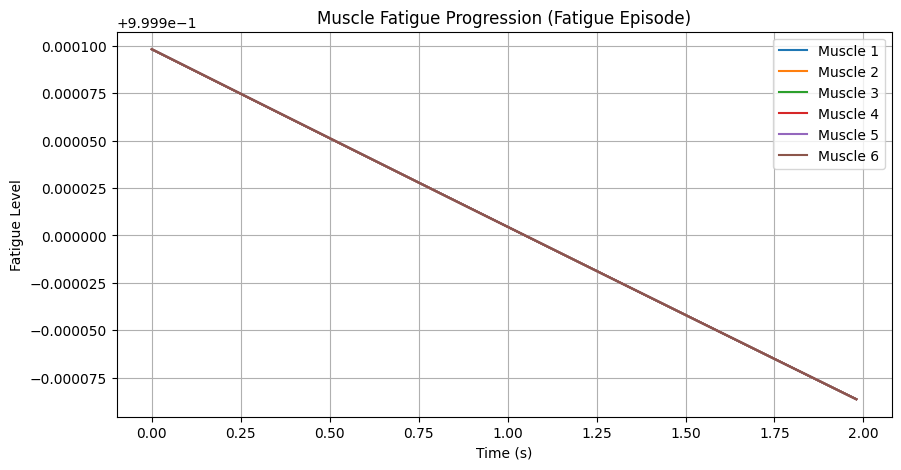

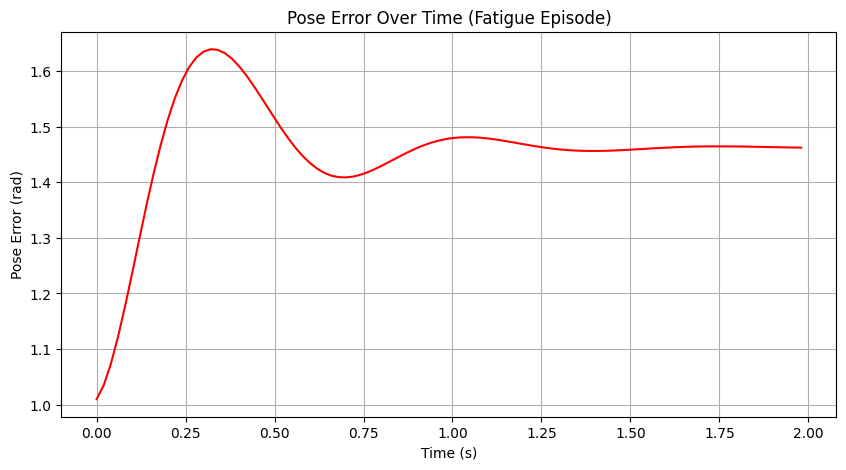

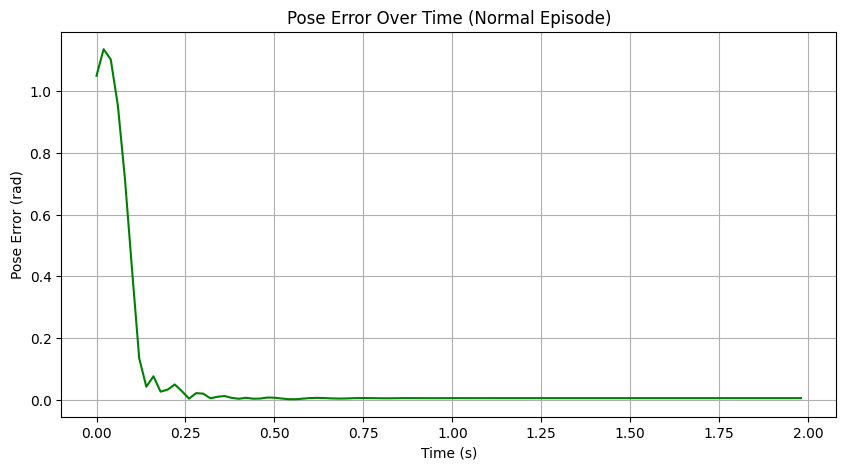

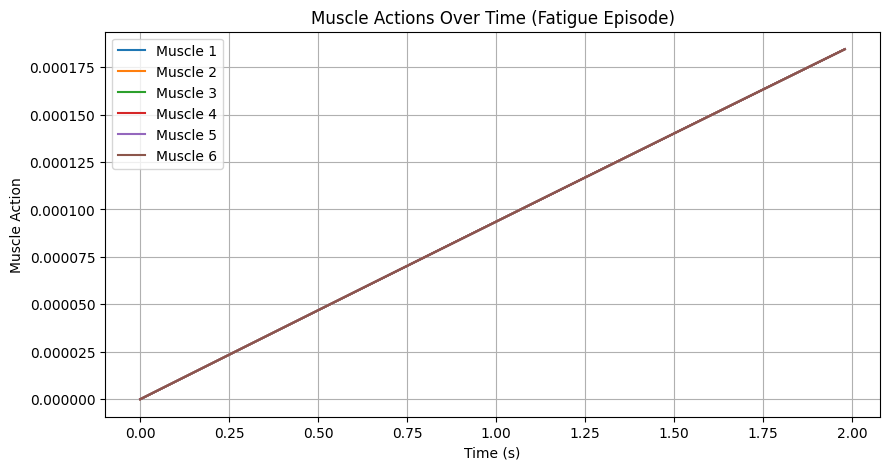

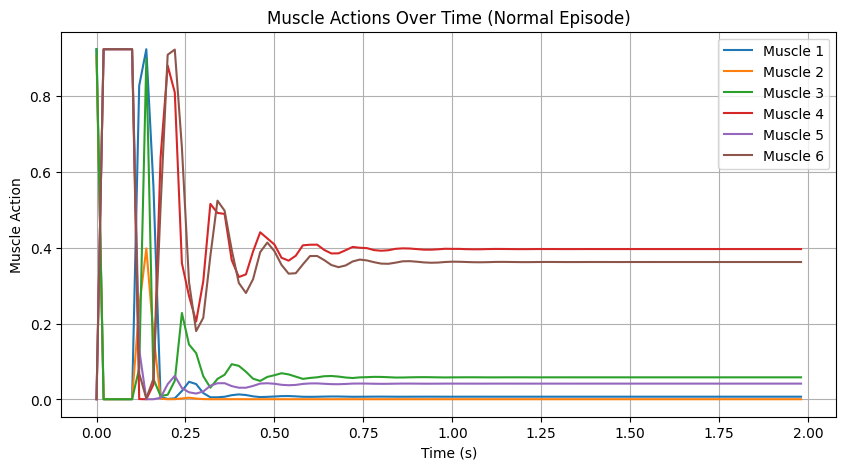

In [65]:
#Understand Data + Environments
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import skvideo.io
from stable_baselines3 import PPO
from myosuite.utils import gym
from IPython.display import display, HTML
from base64 import b64encode
import PIL.Image, PIL.ImageDraw

def add_text_to_frame(frame, text, pos=(20, 20), color=(255, 0, 0), fontsize=12):
    if isinstance(frame, np.ndarray):
        frame = PIL.Image.fromarray(frame)
    draw = PIL.ImageDraw.Draw(frame)
    draw.text(pos, text, fill=color)
    return frame

policy_path = "ElbowPose_policy"
model = PPO.load(policy_path)

TARGET_ANGLE = 2.0
INITIAL_ANGLE = 1.0
INITIAL_VEL = 0.0
MAX_STEPS = 500
N_MUSCLES = 6

env_name_fatigue = 'myoFatiElbowPose1D6MRandom-v0'
env_fatigue = gym.make(env_name_fatigue)
obs, _ = env_fatigue.reset()
env_fatigue.unwrapped.target_jnt_value = [TARGET_ANGLE]
env_fatigue.unwrapped.target_type = 'fixed'
env_fatigue.unwrapped.update_target(restore_sim=True)
env_fatigue.unwrapped.sim.data.qpos[:] = [INITIAL_ANGLE]
env_fatigue.unwrapped.sim.data.qvel[:] = [INITIAL_VEL]
env_fatigue.unwrapped.sim.forward()
env_fatigue.unwrapped.muscle_fatigue.MF[:] = 1.0
env_fatigue.unwrapped.muscle_fatigue.MA[:] = 0.0
env_fatigue.unwrapped.muscle_fatigue.MR[:] = 0.0

frames_fatigue = []
data_fatigue = []
for step in range(MAX_STEPS):
    frame = env_fatigue.unwrapped.sim.renderer.render_offscreen(width=400, height=400, camera_id=0)
    frame = np.array(add_text_to_frame(frame, f"Fatigue t={step*env_fatigue.unwrapped.dt:.1f}s", pos=(220, 3), color=(255, 0, 0), fontsize=16))
    frames_fatigue.append(frame)
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, truncated, info = env_fatigue.step(action)
    pose_err = env_fatigue.unwrapped.get_obs_dict(env_fatigue.unwrapped.sim)["pose_err"]
    muscle_action = env_fatigue.unwrapped.last_ctrl.copy()
    MF = env_fatigue.unwrapped.muscle_fatigue.MF.copy()
    data_fatigue.append({
        "step": step,
        "time": step * env_fatigue.unwrapped.dt,
        "pose_err": pose_err,
        "muscle_action": muscle_action,
        "MF": MF
    })
    if done or truncated:
        break
env_fatigue.close()

env_name_normal = 'myoElbowPose1D6MRandom-v0'
env_normal = gym.make(env_name_normal)
obs, _ = env_normal.reset()
env_normal.unwrapped.target_jnt_value = [TARGET_ANGLE]
env_normal.unwrapped.target_type = 'fixed'
env_normal.unwrapped.update_target(restore_sim=True)
env_normal.unwrapped.sim.data.qpos[:] = [INITIAL_ANGLE]
env_normal.unwrapped.sim.data.qvel[:] = [INITIAL_VEL]
env_normal.unwrapped.sim.forward()

frames_normal = []
data_normal = []
for step in range(MAX_STEPS):
    frame = env_normal.unwrapped.sim.renderer.render_offscreen(width=400, height=400, camera_id=0)
    frame = np.array(add_text_to_frame(frame, f"Normal t={step*env_normal.unwrapped.dt:.1f}s", pos=(220, 3), color=(0, 128, 0), fontsize=16))
    frames_normal.append(frame)
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, truncated, info = env_normal.step(action)
    pose_err = env_normal.unwrapped.get_obs_dict(env_normal.unwrapped.sim)["pose_err"]
    muscle_action = env_normal.unwrapped.last_ctrl.copy()
    data_normal.append({
        "step": step,
        "time": step * env_normal.unwrapped.dt,
        "pose_err": pose_err,
        "muscle_action": muscle_action
    })
    if done or truncated:
        break
env_normal.close()

os.makedirs('videos', exist_ok=True)
video_path_normal = 'videos/normal_human_policy.mp4'
video_path_fatigue = 'videos/fatigue_human_policy.mp4'
skvideo.io.vwrite(video_path_normal, np.asarray(frames_normal), outputdict={'-pix_fmt': 'yuv420p'})
skvideo.io.vwrite(video_path_fatigue, np.asarray(frames_fatigue), outputdict={'-pix_fmt': 'yuv420p'})

df_fatigue = pd.DataFrame(data_fatigue)
df_normal = pd.DataFrame(data_normal)

plt.figure(figsize=(10, 5))
for i in range(N_MUSCLES):
    plt.plot(df_fatigue['time'], [mf[i] for mf in df_fatigue['MF']], label=f'Muscle {i+1}')
plt.xlabel('Time (s)')
plt.ylabel('Fatigue Level')
plt.title('Muscle Fatigue Progression (Fatigue Episode)')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
pose_err_fatigue = [np.linalg.norm(pe) if hasattr(pe, '__len__') else abs(pe) for pe in df_fatigue['pose_err']]
plt.plot(df_fatigue['time'], pose_err_fatigue, color='red')
plt.xlabel('Time (s)')
plt.ylabel('Pose Error (rad)')
plt.title('Pose Error Over Time (Fatigue Episode)')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
pose_err_normal = [np.linalg.norm(pe) if hasattr(pe, '__len__') else abs(pe) for pe in df_normal['pose_err']]
plt.plot(df_normal['time'], pose_err_normal, color='green')
plt.xlabel('Time (s)')
plt.ylabel('Pose Error (rad)')
plt.title('Pose Error Over Time (Normal Episode)')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
for i in range(N_MUSCLES):
    plt.plot(df_fatigue['time'], [ma[i] for ma in df_fatigue['muscle_action']], label=f'Muscle {i+1}')
plt.xlabel('Time (s)')
plt.ylabel('Muscle Action')
plt.title('Muscle Actions Over Time (Fatigue Episode)')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
for i in range(N_MUSCLES):
    plt.plot(df_normal['time'], [ma[i] for ma in df_normal['muscle_action']], label=f'Muscle {i+1}')
plt.xlabel('Time (s)')
plt.ylabel('Muscle Action')
plt.title('Muscle Actions Over Time (Normal Episode)')
plt.legend()
plt.grid(True)
plt.show()

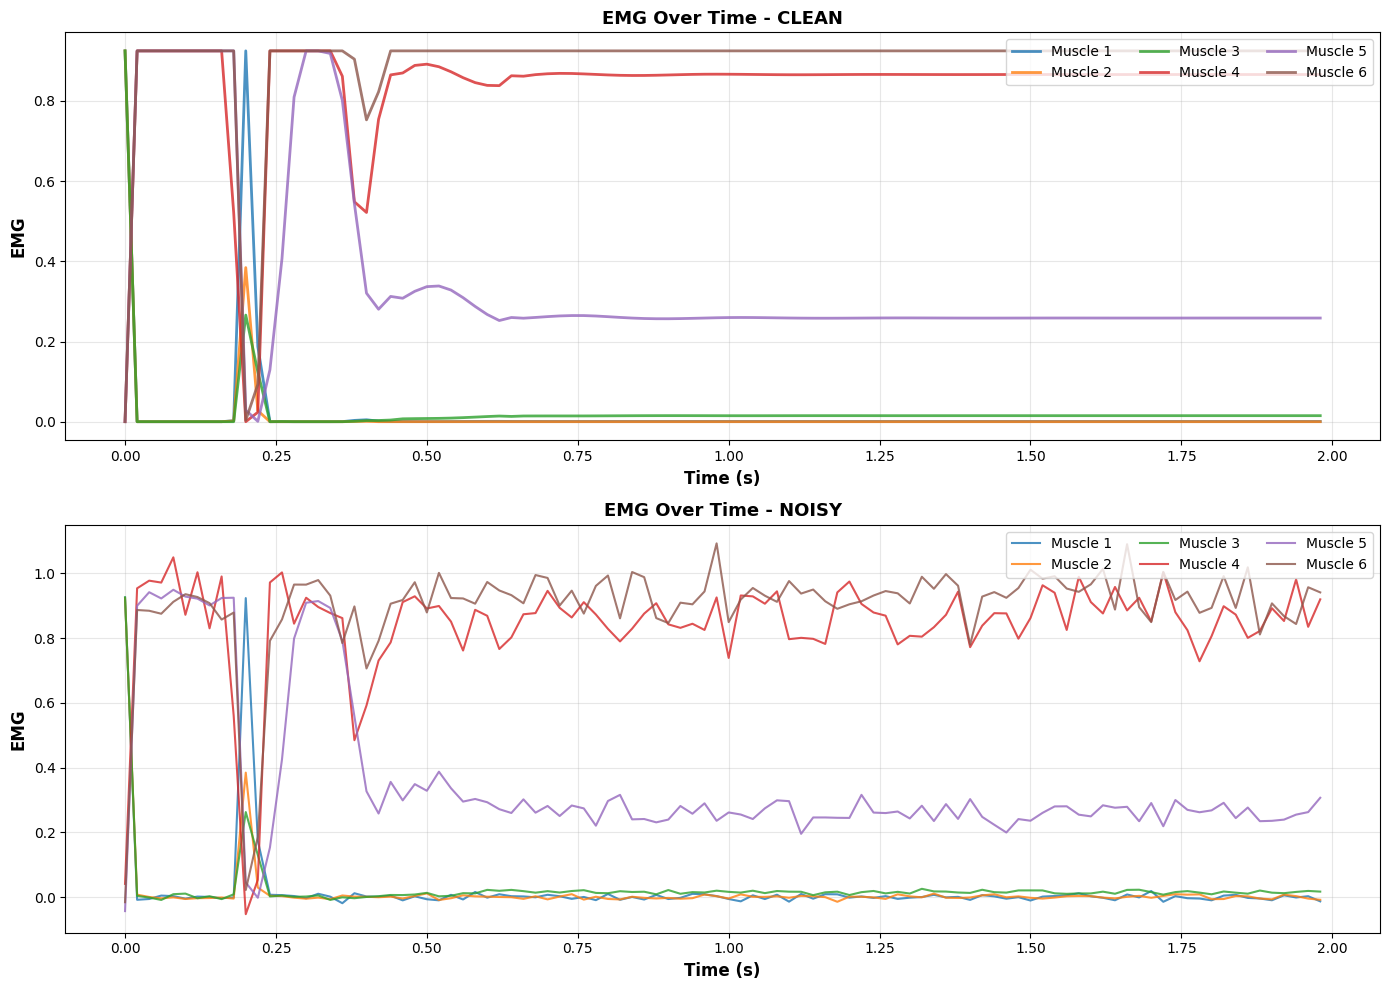


REALISTIC SURFACE EMG NOISE SIMULATION (Research-Based)

Noise Level: 0.15
  0.05 = Clean laboratory conditions (controlled environment)
  0.15 = Realistic field conditions (typical wearable EMG)
  0.30 = Challenging conditions (electrode movement, poor contact)

Noise Composition:
  • 40% White Gaussian (thermal/sensor noise)
  • 35% Powerline interference (50/60 Hz + harmonics)
  • 20% Motion artifacts (0.1-10 Hz electrode movement)
  •  5% High-frequency crosstalk (neighboring muscle interference)
--------------------------------------------------------------------------------
Muscle 1: SNR= 24.18 dB | Signal RMS=0.1320 | Noise RMS=0.0082
Muscle 2: SNR= 23.81 dB | Signal RMS=0.1001 | Noise RMS=0.0065
Muscle 3: SNR= 24.46 dB | Signal RMS=0.0979 | Noise RMS=0.0059
Muscle 4: SNR= 24.26 dB | Signal RMS=0.8514 | Noise RMS=0.0522
Muscle 5: SNR= 23.61 dB | Signal RMS=0.4208 | Noise RMS=0.0278
Muscle 6: SNR= 24.43 dB | Signal RMS=0.9074 | Noise RMS=0.0545
Typical SNR ranges in real sEMG:
 

In [64]:
# Muscle Actions Over Time - Clean vs Noisy Comparison
# Adjust noise_level_control to change how noisy the EMG signal is

noise_level_control = 0.15  # ADJUST THIS VALUE: 0.05 (clean lab) | 0.15 (realistic) | 0.3+ (challenging)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Clean Muscle Actions (No Noise)
ax_clean = axes[0]
for i in range(N_MUSCLES):
    clean_data = np.array([ma[i] for ma in df_normal['muscle_action']])
    ax_clean.plot(df_normal['time'], clean_data, label=f'Muscle {i+1}', linewidth=2, alpha=0.8)

ax_clean.set_xlabel('Time (s)', fontsize=12, fontweight='bold')
ax_clean.set_ylabel('EMG', fontsize=12, fontweight='bold')
ax_clean.set_title('EMG Over Time - CLEAN', fontsize=13, fontweight='bold')
ax_clean.legend(loc='upper right', ncol=3)
ax_clean.grid(True, alpha=0.3)

# Plot 2: Noisy Muscle Actions (with controlled noise)
ax_noisy = axes[1]
for i in range(N_MUSCLES):
    clean_data = np.array([ma[i] for ma in df_normal['muscle_action']])
    noisy_data = add_emg_noise(clean_data, noise_level=noise_level_control, sampling_rate=100)
    ax_noisy.plot(df_normal['time'], noisy_data, label=f'Muscle {i+1}', linewidth=1.5, alpha=0.8)

ax_noisy.set_xlabel('Time (s)', fontsize=12, fontweight='bold')
ax_noisy.set_ylabel('EMG', fontsize=12, fontweight='bold')
ax_noisy.set_title(f'EMG Over Time - NOISY', 
                   fontsize=13, fontweight='bold')
ax_noisy.legend(loc='upper right', ncol=3)
ax_noisy.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print noise statistics and SNR per muscle
print("\n" + "="*80)
print("REALISTIC SURFACE EMG NOISE SIMULATION (Research-Based)")
print("="*80)
print(f"\nNoise Level: {noise_level_control}")
print("  0.05 = Clean laboratory conditions (controlled environment)")
print("  0.15 = Realistic field conditions (typical wearable EMG)")
print("  0.30 = Challenging conditions (electrode movement, poor contact)")
print("\nNoise Composition:")
print("  • 40% White Gaussian (thermal/sensor noise)")
print("  • 35% Powerline interference (50/60 Hz + harmonics)")
print("  • 20% Motion artifacts (0.1-10 Hz electrode movement)")
print("  •  5% High-frequency crosstalk (neighboring muscle interference)")
print("-"*80)

for i in range(N_MUSCLES):
    clean_signal = np.array([ma[i] for ma in df_normal['muscle_action']])
    noisy_signal = add_emg_noise(clean_signal, noise_level=noise_level_control, sampling_rate=100)
    
    clean_rms = np.sqrt(np.mean(clean_signal**2))
    noise_rms = np.sqrt(np.mean((noisy_signal - clean_signal)**2))
    snr_db = 10 * np.log10((clean_rms**2) / (noise_rms**2)) if noise_rms > 0 else float('inf')
    
    print(f"Muscle {i+1}: SNR={snr_db:6.2f} dB | Signal RMS={clean_rms:.4f} | Noise RMS={noise_rms:.4f}")

print("="*80)
print("Typical SNR ranges in real sEMG:")
print("  • 40+ dB = Excellent (high-quality lab setup)")
print("  • 20-40 dB = Good (typical wearable EMG)")
print("  • 5-20 dB = Poor (electrode issues, movement)")
print("  • < 5 dB = Very poor (severe interference)")
print("="*80)

Running 100 episodes. canonical start qpos=0.9889, decrement per episode=0.009889, fixed_target=2.000

=== EPISODE 1/100 (ASSISTED ONLY) ===
 pathology avg_fat=0.000000, force=0.800, slowdown=2.000, impairment=0.000000
 Episode 1 finished: steps=100, total_reward=664.019, mean_abs_exo_torque=0.5501, mean_ctrl_scalar=0.1756, mean_IMU=0.547934
 Saved log: results/assisted_only\episode_01_assisted_log.csv

=== EPISODE 2/100 (ASSISTED ONLY) ===
 pathology avg_fat=0.009596, force=0.800, slowdown=2.000, impairment=0.016313
 Episode 2 finished: steps=100, total_reward=-123.934, mean_abs_exo_torque=0.7867, mean_ctrl_scalar=0.5076, mean_IMU=0.584156
 Saved log: results/assisted_only\episode_02_assisted_log.csv

=== EPISODE 3/100 (ASSISTED ONLY) ===
 pathology avg_fat=0.019192, force=0.800, slowdown=2.000, impairment=0.032626
 Episode 3 finished: steps=100, total_reward=-76.896, mean_abs_exo_torque=0.7529, mean_ctrl_scalar=0.4992, mean_IMU=0.586340
 Saved log: results/assisted_only\episode_03_as

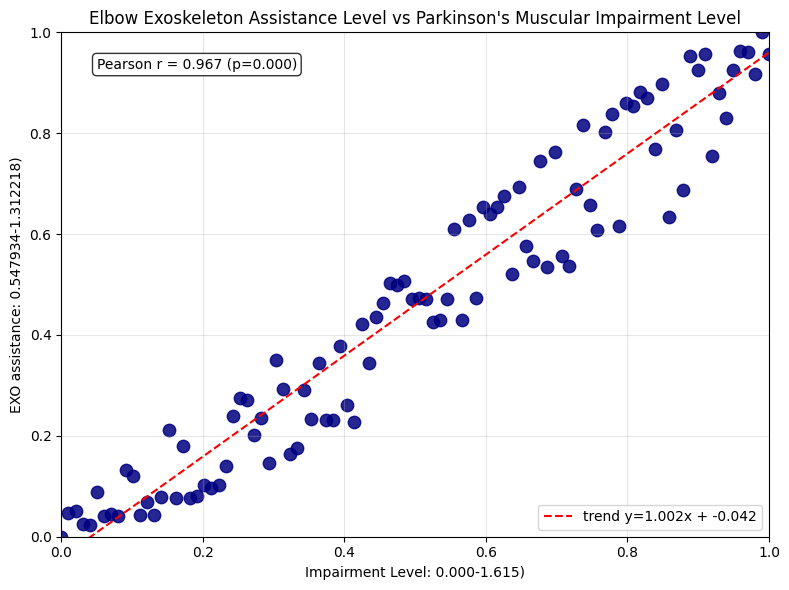

Saved plot: results/assisted_only\Exo_vs_impairment.png


In [68]:
#Non invasive tracking correlation
import os
import numpy as np
import pandas as pd
import skvideo.io
import matplotlib.pyplot as plt
from base64 import b64encode
from IPython.display import HTML, display
from stable_baselines3 import PPO
from myosuite.utils import gym
import PIL.Image, PIL.ImageDraw


def show_video(video_path, video_width=420):
    with open(video_path, "r+b") as f:
        video_file = f.read()
    video_url = f'data:video/mp4;base64,{b64encode(video_file).decode()}'
    return HTML(f"<video autoplay width={video_width} controls><source src=\"{video_url}\"></video>")

def add_text_to_frame(frame, text, pos=(20,20), color=(255,0,0)):
    if isinstance(frame, np.ndarray):
        frame = PIL.Image.fromarray(frame)
    draw = PIL.ImageDraw.Draw(frame)
    draw.text(pos, text, fill=color)
    return np.asarray(frame)


env_name = "myoFatiElbowPose1D6MExoRandom-v0"
frozen_policy_path = "ElbowPose_policy"
exo_policy_path = "Full-ElbowExo"    
GENERATE_VIDEO = False
VIDEOS_DIR = "videos/assisted_only"
RESULTS_DIR = "results/assisted_only"
os.makedirs(VIDEOS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

N_EPISODES = 100


mf_episode_values = np.linspace(0.0, 0.95, N_EPISODES).tolist()

fixed_force_scale = 0.80
fixed_activation_slowdown = 2.0

exo_policy = PPO.load(exo_policy_path)

_temp_base = gym.make(env_name)
_temp_wrapper = CombinedExoOnlyWrapper(_temp_base, frozen_policy_path=frozen_policy_path, smart_reset=True, use_avg_mf=True, hide_pose_err=True)
_temp_wrapper.base_env.unwrapped.set_fatigue_reset_random(False)
_obs_tmp, _info_tmp = _temp_wrapper.reset()

low = _temp_wrapper.base_env.unwrapped.target_jnt_range[:, 0]
high = _temp_wrapper.base_env.unwrapped.target_jnt_range[:, 1]
fixed_target = float(np.clip(2.0, low[0], high[0]))

initial_canonical_qpos = float(_temp_wrapper.base_env.unwrapped.sim.data.qpos.copy()[0]) if hasattr(_temp_wrapper.base_env.unwrapped.sim.data.qpos, '__len__') else float(_temp_wrapper.base_env.unwrapped.sim.data.qpos)
initial_canonical_qvel = _temp_wrapper.base_env.unwrapped.sim.data.qvel.copy()
_temp_wrapper.close()

if N_EPISODES > 0:
    qpos_decrement_per_episode = initial_canonical_qpos / N_EPISODES
else:
    qpos_decrement_per_episode = 0.0

print(f"Running {N_EPISODES} episodes. canonical start qpos={initial_canonical_qpos:.4f}, decrement per episode={qpos_decrement_per_episode:.6f}, fixed_target={fixed_target:.3f}")

def brady_severity(force_scale, activation_slowdown):
    return (1.0 - float(force_scale)) + 0.5 * (float(activation_slowdown) - 1.0)

def impairment_metric(avg_fatigue, force_scale, activation_slowdown):
    bs = brady_severity(force_scale, activation_slowdown)
    return float(avg_fatigue) * (1.0 + bs)

episode_rows = []
frames_per_episode = {}

all_impairments = []
all_mean_exo_torques = []
all_mean_ctrls = []     
all_mean_ctrl_scalar = []  
all_avg_fatigue = []
all_force_scales = []
all_activation_slowdowns = []
all_mean_imu = []       

for epi in range(N_EPISODES):
    print(f"\n=== EPISODE {epi+1}/{N_EPISODES} (ASSISTED ONLY) ===")
    try:
        base_env = gym.make(env_name)
        combined_env = CombinedExoOnlyWrapper(base_env, frozen_policy_path=frozen_policy_path, smart_reset=True, use_avg_mf=True, hide_pose_err=True)
        combined_env.base_env.unwrapped.set_fatigue_reset_random(False)

        obs, info = combined_env.reset()

        combined_env.base_env.unwrapped.target_jnt_value = [fixed_target]
        combined_env.base_env.unwrapped.target_type = 'fixed'
        combined_env.base_env.unwrapped.update_target(restore_sim=True)

        mf_val = float(mf_episode_values[epi])
        n_muscles = len(combined_env.base_env.unwrapped.muscle_fatigue.MA)
        MF_fixed = np.full(n_muscles, float(mf_val), dtype=np.float32)
        remaining = 1.0 - MF_fixed
        split = 0.5
        MA_fixed = remaining * split
        MR_fixed = remaining * (1.0 - split)
        combined_env.base_env.unwrapped.muscle_fatigue.MA[:] = MA_fixed
        combined_env.base_env.unwrapped.muscle_fatigue.MR[:] = MR_fixed
        combined_env.base_env.unwrapped.muscle_fatigue.MF[:] = MF_fixed

        combined_env.force_scale = fixed_force_scale
        combined_env.activation_slowdown = fixed_activation_slowdown
        combined_env._apply_bradykinesia_effects()

        start_qpos = initial_canonical_qpos - qpos_decrement_per_episode * epi
        start_qpos = max(0.0, float(start_qpos))
        combined_env.base_env.unwrapped.sim.data.qpos[:] = np.array([start_qpos])
        combined_env.base_env.unwrapped.sim.data.qvel[:] = initial_canonical_qvel
        combined_env.base_env.unwrapped.sim.forward()

        try:
            current_exo_obs = combined_env.base_env._get_obs()
        except Exception:
            current_exo_obs = combined_env.base_env.unwrapped.get_obs()
        obs = combined_env._get_extended_obs(current_exo_obs)

        cur_fat_info = combined_env.get_fatigue_info()
        cur_brady_info = combined_env.get_bradykinesia_info()
        avg_fat = float(cur_fat_info['avg_fatigue'])
        force_now = float(cur_brady_info['force_scale'])
        act_slow_now = float(cur_brady_info['activation_slowdown'])
        impairment = impairment_metric(avg_fat, force_now, act_slow_now)
        print(f" pathology avg_fat={avg_fat:.6f}, force={force_now:.3f}, slowdown={act_slow_now:.3f}, impairment={impairment:.6f}")

        frames = []
        log = []
        total_reward = 0.0
        exo_torques = []
        mean_ctrl_vec = None
        imu_values = []  

        max_steps = combined_env.base_env.spec.max_episode_steps if hasattr(combined_env.base_env, "spec") else 500
        for step in range(max_steps):
            if GENERATE_VIDEO:
                frame = combined_env.base_env.unwrapped.sim.renderer.render_offscreen(width=400, height=400, camera_id=0)
                frame = add_text_to_frame(frame, f"EP{epi+1} ASSISTED t={step*combined_env.base_env.unwrapped.dt:.2f}s", pos=(6,4), color=(0,200,0))
                frame = add_text_to_frame(frame, f"AvgFat:{avg_fat:.4f} Imp:{impairment:.4f}", pos=(6,24), color=(255,165,0))
                frames.append(frame)

            action, _ = exo_policy.predict(obs, deterministic=True)
            next_obs, reward, done, truncated, info = combined_env.step(action)
            total_reward += float(reward)

            try:
                torque_val = float(np.ravel(action)[0])
            except Exception:
                torque_val = float(action) if not hasattr(action, '__len__') else 0.0
            exo_torques.append(abs(torque_val))

            try:
                qvel = combined_env.base_env.unwrapped.sim.data.qvel.copy()
                qvel_arr = np.ravel(qvel).astype(np.float32)
                imu_scalar = float(np.mean(np.abs(qvel_arr)))  
            except Exception:
                imu_scalar = 0.0
            imu_values.append(imu_scalar)

            cf = combined_env.get_fatigue_info()
            cb = combined_env.get_bradykinesia_info()
            last_ctrl = combined_env.base_env.unwrapped.last_ctrl.copy() if hasattr(combined_env.base_env.unwrapped, 'last_ctrl') else np.zeros(n_muscles)
            pose_err = combined_env.base_env.unwrapped.get_obs_dict(combined_env.base_env.unwrapped.sim)["pose_err"]
            log.append({
                "episode": epi+1,
                "step": step,
                "time": step * combined_env.base_env.unwrapped.dt,
                "exo_action": action.copy(),
                "exo_torque": torque_val,
                "jpos": combined_env.base_env.unwrapped.sim.data.qpos.copy(),
                "jvel": combined_env.base_env.unwrapped.sim.data.qvel.copy(),
                "MA": cf['muscle_activation'].copy(),
                "MR": cf['muscle_recovery'].copy(),
                "MF": cf['muscle_fatigue'].copy(),
                "avg_fatigue": float(cf['avg_fatigue']),
                "force_scale": cb['force_scale'],
                "activation_slowdown": cb['activation_slowdown'],
                "reward": float(reward),
                "cumulative_reward": total_reward,
                "pose_err": pose_err,
                "ctrl": last_ctrl.copy(),
                "imu_avg_abs_qvel": imu_scalar
            })

            obs = next_obs
            if done or truncated:
                break

        mean_exo_torque = float(np.mean(np.abs(exo_torques))) if len(exo_torques) > 0 else 0.0
        steps_taken = len(log)
        mean_imu = float(np.mean(imu_values)) if len(imu_values) > 0 else 0.0

        if len(log) > 0:
            ctrl_array = np.vstack([row['ctrl'] for row in log])  
            mean_ctrl_vec = np.mean(ctrl_array, axis=0)
            mean_ctrl_scalar = float(np.mean(mean_ctrl_vec))
        else:
            mean_ctrl_vec = np.zeros(n_muscles)
            mean_ctrl_scalar = 0.0

        print(f" Episode {epi+1} finished: steps={steps_taken}, total_reward={total_reward:.3f}, mean_abs_exo_torque={mean_exo_torque:.4f}, mean_ctrl_scalar={mean_ctrl_scalar:.4f}, mean_IMU={mean_imu:.6f}")

        if GENERATE_VIDEO and frames:
            vpath = os.path.join(VIDEOS_DIR, f"episode_{epi+1:02d}_assisted.mp4")
            skvideo.io.vwrite(vpath, np.asarray(frames), outputdict={'-pix_fmt': 'yuv420p'})
            print(" Saved video:", vpath)
            frames_per_episode[epi+1] = vpath

        df_log = pd.DataFrame(log)
        csv_path = os.path.join(RESULTS_DIR, f"episode_{epi+1:02d}_assisted_log.csv")
        for col in ['jpos', 'jvel', 'MA', 'MR', 'MF', 'ctrl', 'exo_action', 'pose_err']:
            if col in df_log.columns:
                df_log[col] = df_log[col].apply(lambda x: np.array2string(np.array(x), separator=' ') if hasattr(x, '__len__') else str(x))
        df_log.to_csv(csv_path, index=False)
        print(" Saved log:", csv_path)

        episode_rows.append({
            "episode": epi+1,
            "mf_value": mf_val,
            "avg_fatigue": avg_fat,
            "force_scale": force_now,
            "activation_slowdown": act_slow_now,
            "impairment": impairment,
            "steps": steps_taken,
            "total_reward": total_reward,
            "mean_exo_torque": mean_exo_torque,
            "mean_ctrl_scalar": mean_ctrl_scalar,
            "mean_ctrl_vec": mean_ctrl_vec.tolist(),
            "mean_imu": mean_imu,
            "log_csv": csv_path,
            "video": frames_per_episode.get(epi+1, "")
        })

        all_impairments.append(impairment)
        all_mean_exo_torques.append(mean_exo_torque)
        all_mean_ctrls.append(mean_ctrl_vec)
        all_mean_ctrl_scalar.append(mean_ctrl_scalar)
        all_avg_fatigue.append(avg_fat)
        all_force_scales.append(force_now)
        all_activation_slowdowns.append(act_slow_now)
        all_mean_imu.append(mean_imu)

    except Exception as e:
        print(f" Episode {epi+1} ERROR: {e}  -- skipping and continuing")
    finally:
        try:
            combined_env.close()
        except Exception:
            pass

df_episodes = pd.DataFrame(episode_rows)
print(df_episodes.head())

if len(all_mean_imu) > 0:
    plt.figure(figsize=(8,6))
    xi = np.array(all_impairments)
    yi = np.array(all_mean_imu)
    
    if len(xi) > 0:
        xi_min, xi_max = np.min(xi), np.max(xi)
        if xi_max > xi_min:
            xi_norm = (xi - xi_min) / (xi_max - xi_min)
        else:
            xi_norm = np.zeros_like(xi)
    else:
        xi_norm = xi
    
    if len(yi) > 0:
        yi_min, yi_max = np.min(yi), np.max(yi)
        if yi_max > yi_min:
            yi_norm = (yi - yi_min) / (yi_max - yi_min)
        else:
            yi_norm = np.zeros_like(yi)
    else:
        yi_norm = yi
    
    plt.scatter(xi_norm, yi_norm, s=80, c='navy', alpha=0.85)
    if len(xi_norm) > 1 and np.std(xi_norm) > 0:
        coefi = np.polyfit(xi_norm, yi_norm, 1)
        xs_i = np.linspace(0, 1, 200)
        plt.plot(xs_i, np.poly1d(coefi)(xs_i), 'red', linestyle='--', label=f"trend y={coefi[0]:.3f}x + {coefi[1]:.3f}")
        try:
            from scipy.stats import pearsonr
            ri, pi = pearsonr(xi_norm, yi_norm)
            plt.text(0.05, 0.95, f"Pearson r = {ri:.3f} (p={pi:.3f})", transform=plt.gca().transAxes, verticalalignment='top', bbox=dict(boxstyle="round", facecolor='white', alpha=0.8))
        except Exception:
            pass
    
    plt.xlabel(f"Impairment Level: {xi_min:.3f}-{xi_max:.3f})")
    plt.ylabel(f"EXO assistance: {yi_min:.6f}-{yi_max:.6f})")
    plt.title("Elbow Exoskeleton Assistance Level vs Parkinson's Muscular Impairment Level")
    plt.xlim(0.0, 1.0)
    plt.ylim(0.0, 1.0)
    plt.grid(alpha=0.3)
    plt.legend()
    out_plot5 = os.path.join(RESULTS_DIR, "Exo_vs_impairment.png")
    plt.tight_layout()
    plt.savefig(out_plot5, dpi=200)
    plt.show()
    print("Saved plot:", out_plot5)

In [ ]:
#Heavy 3-way eval (healthy vs. PD vs. PD+Exo) Takes a while to run all graphs.

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import time
import myosuite
from myosuite.utils import gym
import skvideo.io
from stable_baselines3 import PPO
from IPython.display import HTML, display
from base64 import b64encode
import PIL.Image, PIL.ImageDraw
from scipy import signal


EPI_NUM = 3  
env_name_exo = "myoFatiElbowPose1D6MExoRandom-v0"
GENERATE_VIDEO = True
max_steps = 500

# Colors for consistency
COLOR_PD_EXO = '#E74C3C'      
COLOR_HEALTHY = '#3498DB'     
COLOR_PD_NOEXO = '#95A5A6'    


print(f"Number of evaluations: {EPI_NUM}")
print(f"Total episodes: {EPI_NUM * 3}")


def show_video(video_path, video_width=800):
    video_file = open(video_path, "r+b").read()
    video_url = f'data:video/mp4;base64,{b64encode(video_file).decode()}'
    return HTML(f"<video autoplay width={video_width} controls><source src=\"{video_url}\"></video>")

def add_text_to_frame(frame, text, pos=(40, 40), color=(255, 0, 0), fontsize=12):
    if isinstance(frame, np.ndarray):
        frame = PIL.Image.fromarray(frame)
    draw = PIL.ImageDraw.Draw(frame)
    draw.text(pos, text, fill=color)
    return np.asarray(frame)

def compute_jerk(positions, dt):
    velocity = np.gradient(positions, dt)
    acceleration = np.gradient(velocity, dt)
    jerk = np.gradient(acceleration, dt)
    return jerk

def compute_power(torque, velocity):
    return torque * velocity

exo_policy = PPO.load("Full-ElbowExo")  
human_policy = PPO.load("ElbowPose_policy") 

all_data = {
    'PD+Exo': [],
    'PD-NoExo': [],
    'Healthy': []
}

latency_data = []  
all_videos = {'PD+Exo': [], 'PD-NoExo': [], 'Healthy': []}

for epi_set in range(EPI_NUM):
    print(f"\n{'='*80}")
    print(f"EVALUATION SET {epi_set + 1}/{EPI_NUM}")
    print(f"{'='*80}")
    
    initial_qpos_val = 0.0
    initial_qvel_val = 0.0
    target_angle = np.random.uniform(0.5, 2.4)
    
    print(f"Set {epi_set + 1} Configuration:")
    print(f"  Initial Position: {initial_qpos_val:.3f} rad")
    print(f"  Target Position: {target_angle:.3f} rad")
    
    print(f"\n--- Condition 1/3: PD + Exoskeleton Assistance ---")
    
    base_env_pd_exo = gym.make(env_name_exo)
    pd_exo_env = CombinedExoOnlyWrapper(
        base_env_pd_exo,
        frozen_policy_path="ElbowPose_policy",
        smart_reset=True,
        use_avg_mf=True,
        hide_pose_err=True
    )
    
    obs, _ = pd_exo_env.reset()
    pd_exo_env.base_env.unwrapped.target_jnt_value = [target_angle]
    pd_exo_env.base_env.unwrapped.target_type = 'fixed'
    pd_exo_env.base_env.unwrapped.update_target(restore_sim=True)
    
    pd_exo_env.base_env.unwrapped.sim.data.qpos[:] = [initial_qpos_val]
    pd_exo_env.base_env.unwrapped.sim.data.qvel[:] = [initial_qvel_val]
    pd_exo_env.base_env.unwrapped.sim.forward()
    
    n_muscles = len(pd_exo_env.base_env.unwrapped.muscle_fatigue.MA)
    MF_fixed = np.random.uniform(0.5, 0.9, size=n_muscles)
    remaining = 1.0 - MF_fixed
    split = np.random.uniform(0.0, 1.0, size=n_muscles)
    MA_fixed = remaining * split
    MR_fixed = remaining * (1.0 - split)
    
    pd_exo_env.base_env.unwrapped.muscle_fatigue.MA[:] = MA_fixed
    pd_exo_env.base_env.unwrapped.muscle_fatigue.MR[:] = MR_fixed
    pd_exo_env.base_env.unwrapped.muscle_fatigue.MF[:] = MF_fixed
    
    brady_info = pd_exo_env.get_bradykinesia_info()
    print(f"  Avg Fatigue: {np.mean(MF_fixed):.3f}")
    print(f"  Force Scale: {brady_info['force_scale']:.3f}")
    print(f"  Activation Slowdown: {brady_info['activation_slowdown']:.3f}x")
    
    episode_data = []
    episode_frames = []
    tr = 0.0
    
    for step in range(max_steps):
        if GENERATE_VIDEO:
            frame = pd_exo_env.base_env.unwrapped.sim.renderer.render_offscreen(width=400, height=400, camera_id=0)
            current_time = step * pd_exo_env.base_env.unwrapped.dt
            frame = add_text_to_frame(frame, f"PD+Exo Set{epi_set+1} t={current_time:.1f}s", 
                                     pos=(50, 3), color=(255, 0, 0))
            episode_frames.append(frame.astype(np.uint8))
        
        start_time = time.perf_counter()
        exo_action, _ = exo_policy.predict(obs, deterministic=True)
        end_time = time.perf_counter()
        latency_ms = (end_time - start_time) * 1000
        latency_data.append({'set': epi_set, 'step': step, 'latency_ms': latency_ms})
        
        next_obs, reward, done, truncated, info = pd_exo_env.step(exo_action)
        obs = next_obs
        tr += float(reward)
        
        fatigue_info = pd_exo_env.get_fatigue_info()
        brady_info_step = pd_exo_env.get_bradykinesia_info()
        
        episode_data.append({
            'set': epi_set,
            'condition': 'PD+Exo',
            'step': step,
            'time': step * pd_exo_env.base_env.unwrapped.dt,
            'jpos': pd_exo_env.base_env.unwrapped.sim.data.qpos[0],
            'jvel': pd_exo_env.base_env.unwrapped.sim.data.qvel[0],
            'exo_torque': float(exo_action[0]) if len(exo_action) > 0 else 0.0,
            'exo_action_mag': np.linalg.norm(exo_action),
            'mlen': pd_exo_env.base_env.unwrapped.sim.data.actuator_length.copy(),
            'act': pd_exo_env.base_env.unwrapped.sim.data.act.copy(),
            'ctrl': pd_exo_env.base_env.unwrapped.last_ctrl.copy(),
            'reward': float(reward),
            'cumulative_reward': tr,
            'solved': pd_exo_env.base_env.unwrapped.rwd_dict['solved'].item(),
            'pose_err': pd_exo_env.base_env.unwrapped.get_obs_dict(pd_exo_env.base_env.unwrapped.sim)["pose_err"],
            'MA': fatigue_info['muscle_activation'].copy(),
            'MR': fatigue_info['muscle_recovery'].copy(),
            'MF': fatigue_info['muscle_fatigue'].copy(),
            'avg_fatigue': fatigue_info['avg_fatigue'],
            'force_scale': brady_info_step['force_scale'],
            'activation_slowdown': brady_info_step['activation_slowdown']
        })
        
        if done or truncated:
            break
    
    all_data['PD+Exo'].extend(episode_data)
    if episode_frames:
        all_videos['PD+Exo'].append(episode_frames)
    
    print(f"  ✓ Completed: {len(episode_data)} steps, Reward: {tr:.3f}")
    pd_exo_env.close()
    
    
    print(f"\n--- Condition 2/3: PD Without Exoskeleton ---")
    
    base_env_pd_noexo = gym.make(env_name_exo)
    pd_noexo_env = CombinedExoOnlyWrapper(
        base_env_pd_noexo,
        frozen_policy_path="ElbowPose_policy",
        smart_reset=True,
        use_avg_mf=True,
        hide_pose_err=True
    )
    
    obs, _ = pd_noexo_env.reset()
    pd_noexo_env.base_env.unwrapped.target_jnt_value = [target_angle]
    pd_noexo_env.base_env.unwrapped.target_type = 'fixed'
    pd_noexo_env.base_env.unwrapped.update_target(restore_sim=True)
    
    pd_noexo_env.base_env.unwrapped.sim.data.qpos[:] = [initial_qpos_val]
    pd_noexo_env.base_env.unwrapped.sim.data.qvel[:] = [initial_qvel_val]
    pd_noexo_env.base_env.unwrapped.sim.forward()
    
    pd_noexo_env.base_env.unwrapped.muscle_fatigue.MA[:] = MA_fixed
    pd_noexo_env.base_env.unwrapped.muscle_fatigue.MR[:] = MR_fixed
    pd_noexo_env.base_env.unwrapped.muscle_fatigue.MF[:] = MF_fixed
    
    episode_data = []
    episode_frames = []
    tr = 0.0
    
    for step in range(max_steps):
        if GENERATE_VIDEO:
            frame = pd_noexo_env.base_env.unwrapped.sim.renderer.render_offscreen(width=400, height=400, camera_id=0)
            current_time = step * pd_noexo_env.base_env.unwrapped.dt
            frame = add_text_to_frame(frame, f"PD-NoExo Set{epi_set+1} t={current_time:.1f}s", 
                                     pos=(50, 3), color=(150, 150, 150))
            episode_frames.append(frame.astype(np.uint8))
        
        exo_action = np.array([0.0], dtype=np.float32)  
        next_obs, reward, done, truncated, info = pd_noexo_env.step(exo_action)
        obs = next_obs
        tr += float(reward)
        
        fatigue_info = pd_noexo_env.get_fatigue_info()
        brady_info_step = pd_noexo_env.get_bradykinesia_info()
        
        episode_data.append({
            'set': epi_set,
            'condition': 'PD-NoExo',
            'step': step,
            'time': step * pd_noexo_env.base_env.unwrapped.dt,
            'jpos': pd_noexo_env.base_env.unwrapped.sim.data.qpos[0],
            'jvel': pd_noexo_env.base_env.unwrapped.sim.data.qvel[0],
            'exo_torque': 0.0,
            'exo_action_mag': 0.0,
            'mlen': pd_noexo_env.base_env.unwrapped.sim.data.actuator_length.copy(),
            'act': pd_noexo_env.base_env.unwrapped.sim.data.act.copy(),
            'ctrl': pd_noexo_env.base_env.unwrapped.last_ctrl.copy(),
            'reward': float(reward),
            'cumulative_reward': tr,
            'solved': pd_noexo_env.base_env.unwrapped.rwd_dict['solved'].item(),
            'pose_err': pd_noexo_env.base_env.unwrapped.get_obs_dict(pd_noexo_env.base_env.unwrapped.sim)["pose_err"],
            'MA': fatigue_info['muscle_activation'].copy(),
            'MR': fatigue_info['muscle_recovery'].copy(),
            'MF': fatigue_info['muscle_fatigue'].copy(),
            'avg_fatigue': fatigue_info['avg_fatigue'],
            'force_scale': brady_info_step['force_scale'],
            'activation_slowdown': brady_info_step['activation_slowdown']
        })
        
        if done or truncated:
            break
    
    all_data['PD-NoExo'].extend(episode_data)
    if episode_frames:
        all_videos['PD-NoExo'].append(episode_frames)
    
    print(f"  ✓ Completed: {len(episode_data)} steps, Reward: {tr:.3f}")
    pd_noexo_env.close()
    
    print(f"\n--- Condition 3/3: Healthy Subject ---")
    
    base_env_healthy = gym.make(env_name_exo)
    
    obs, _ = base_env_healthy.reset()
    base_env_healthy.unwrapped.target_jnt_value = [target_angle]
    base_env_healthy.unwrapped.target_type = 'fixed'
    base_env_healthy.unwrapped.update_target(restore_sim=True)
    
    base_env_healthy.unwrapped.sim.data.qpos[:] = [initial_qpos_val]
    base_env_healthy.unwrapped.sim.data.qvel[:] = [initial_qvel_val]
    base_env_healthy.unwrapped.sim.forward()
    
    episode_data = []
    episode_frames = []
    tr = 0.0
    
    for step in range(max_steps):
        if GENERATE_VIDEO:
            frame = base_env_healthy.unwrapped.sim.renderer.render_offscreen(width=400, height=400, camera_id=0)
            current_time = step * base_env_healthy.unwrapped.dt
            frame = add_text_to_frame(frame, f"Healthy Set{epi_set+1} t={current_time:.1f}s", 
                                     pos=(50, 3), color=(0, 0, 255))
            episode_frames.append(frame.astype(np.uint8))
        
        current_obs = base_env_healthy.unwrapped.get_obs()
        human_action, _ = human_policy.predict(current_obs, deterministic=True)
        full_action = np.concatenate([np.array([0.0]), human_action], dtype=np.float32)
        next_obs, reward, done, truncated, info = base_env_healthy.step(full_action)
        tr += float(reward)
        
        episode_data.append({
            'set': epi_set,
            'condition': 'Healthy',
            'step': step,
            'time': step * base_env_healthy.unwrapped.dt,
            'jpos': base_env_healthy.unwrapped.sim.data.qpos[0],
            'jvel': base_env_healthy.unwrapped.sim.data.qvel[0],
            'exo_torque': 0.0,
            'exo_action_mag': 0.0,
            'mlen': base_env_healthy.unwrapped.sim.data.actuator_length.copy(),
            'act': base_env_healthy.unwrapped.sim.data.act.copy(),
            'ctrl': base_env_healthy.unwrapped.last_ctrl.copy(),
            'reward': float(reward),
            'cumulative_reward': tr,
            'solved': base_env_healthy.unwrapped.rwd_dict['solved'].item(),
            'pose_err': base_env_healthy.unwrapped.get_obs_dict(base_env_healthy.unwrapped.sim)["pose_err"],
            'MA': base_env_healthy.unwrapped.muscle_fatigue.MA.copy() if hasattr(base_env_healthy.unwrapped, 'muscle_fatigue') else np.zeros(6),
            'MR': base_env_healthy.unwrapped.muscle_fatigue.MR.copy() if hasattr(base_env_healthy.unwrapped, 'muscle_fatigue') else np.zeros(6),
            'MF': base_env_healthy.unwrapped.muscle_fatigue.MF.copy() if hasattr(base_env_healthy.unwrapped, 'muscle_fatigue') else np.ones(6),
            'avg_fatigue': np.mean(base_env_healthy.unwrapped.muscle_fatigue.MF) if hasattr(base_env_healthy.unwrapped, 'muscle_fatigue') else 1.0,
            'force_scale': 1.0,
            'activation_slowdown': 1.0
        })
        
        if done or truncated:
            break
    
    all_data['Healthy'].extend(episode_data)
    if episode_frames:
        all_videos['Healthy'].append(episode_frames)
    
    print(f"  ✓ Completed: {len(episode_data)} steps, Reward: {tr:.3f}")
    base_env_healthy.close()

if GENERATE_VIDEO:
    os.makedirs('videos', exist_ok=True)
    
    for condition, video_list in all_videos.items():
        for idx, frames in enumerate(video_list):
            if frames:
                video_path = f'videos/{condition}_set{idx+1}.mp4'
                skvideo.io.vwrite(video_path, np.asarray(frames).astype(np.uint8), 
                                outputdict={'-pix_fmt': 'yuv420p'})
                print(f"  ✓ {video_path}")


df_pd_exo = pd.DataFrame(all_data['PD+Exo'])
df_pd_noexo = pd.DataFrame(all_data['PD-NoExo'])
df_healthy = pd.DataFrame(all_data['Healthy'])
df_latency = pd.DataFrame(latency_data)

avg_latency = df_latency['latency_ms'].mean()
print(f"\n  Average Model Latency: {avg_latency:.4f} ms")

os.makedirs('data', exist_ok=True)
df_pd_exo.to_csv('data/pd_exo_data.csv', index=False)
df_pd_noexo.to_csv('data/pd_noexo_data.csv', index=False)
df_healthy.to_csv('data/healthy_data.csv', index=False)
df_latency.to_csv('data/latency_data.csv', index=False)

summary_metrics = {
    'Condition': ['PD+Exo', 'PD-NoExo', 'Healthy'],
    'Total_Episodes': [len(df_pd_exo), len(df_pd_noexo), len(df_healthy)],
    'Avg_Cumulative_Reward': [
        df_pd_exo.groupby('set')['cumulative_reward'].last().mean(),
        df_pd_noexo.groupby('set')['cumulative_reward'].last().mean(),
        df_healthy.groupby('set')['cumulative_reward'].last().mean()
    ],
    'Avg_Final_Pose_Error': [
        df_pd_exo.groupby('set')['pose_err'].last().mean(),
        df_pd_noexo.groupby('set')['pose_err'].last().mean(),
        df_healthy.groupby('set')['pose_err'].last().mean()
    ],
    'Task_Success_Rate': [
        df_pd_exo.groupby('set')['solved'].last().mean() * 100,
        df_pd_noexo.groupby('set')['solved'].last().mean() * 100,
        df_healthy.groupby('set')['solved'].last().mean() * 100
    ]
}
df_summary = pd.DataFrame(summary_metrics)
df_summary.to_csv('data/summary_metrics.csv', index=False)
print("\n  ✓ Data exported to 'data/' directory")



os.makedirs('plots', exist_ok=True)

# Set plot style
plt.style.use('default')
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 9


fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df_latency['step'], df_latency['latency_ms'], 
        color='#3498DB', alpha=0.6, linewidth=0.8, label='Per-Step Latency')
ax.axhline(y=avg_latency, color='#E74C3C', linestyle='--', linewidth=2, 
          label=f'Average: {avg_latency:.4f} ms')

# Add text annotation for average
ax.text(len(df_latency) * 0.7, avg_latency * 1.1, 
       f'Avg = {avg_latency:.4f} ms', 
       fontsize=11, color='#E74C3C', fontweight='bold',
       bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_xlabel('Timestep', fontweight='bold')
ax.set_ylabel('Latency (ms)', fontweight='bold')
ax.set_title('PPO Model Inference Latency (PD+Exo Condition)', fontweight='bold', pad=15)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('plots/01_model_latency.png', dpi=300, bbox_inches='tight')
plt.close()


fig, ax = plt.subplots(figsize=(12, 7))

# Plot each condition
for set_num in range(EPI_NUM):
    df_pd_exo_set = df_pd_exo[df_pd_exo['set'] == set_num]
    df_pd_noexo_set = df_pd_noexo[df_pd_noexo['set'] == set_num]
    df_healthy_set = df_healthy[df_healthy['set'] == set_num]
    
    alpha_val = 0.7 if EPI_NUM == 1 else 0.4
    
    ax.plot(df_pd_exo_set['time'], df_pd_exo_set['jpos'], 
           color=COLOR_PD_EXO, alpha=alpha_val, linewidth=2, 
           label='PD+Exo' if set_num == 0 else '')
    ax.plot(df_pd_noexo_set['time'], df_pd_noexo_set['jpos'], 
           color=COLOR_PD_NOEXO, alpha=alpha_val, linewidth=2, 
           label='PD-NoExo' if set_num == 0 else '')
    ax.plot(df_healthy_set['time'], df_healthy_set['jpos'], 
           color=COLOR_HEALTHY, alpha=alpha_val, linewidth=2, 
           label='Healthy' if set_num == 0 else '')

ax.set_xlabel('Time (s)', fontweight='bold')
ax.set_ylabel('Elbow Joint Position (rad)', fontweight='bold')
ax.set_title('Elbow Joint Position Trajectory Comparison\nAcross Three Conditions', 
            fontweight='bold', pad=15)
ax.legend(loc='best', framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('plots/02_joint_position_comparison.png', dpi=300, bbox_inches='tight')
plt.close()


fig, ax = plt.subplots(figsize=(12, 7))

for set_num in range(EPI_NUM):
    df_pd_exo_set = df_pd_exo[df_pd_exo['set'] == set_num]
    df_pd_noexo_set = df_pd_noexo[df_pd_noexo['set'] == set_num]
    df_healthy_set = df_healthy[df_healthy['set'] == set_num]
    
    alpha_val = 0.7 if EPI_NUM == 1 else 0.4
    
    ax.plot(df_pd_exo_set['time'], df_pd_exo_set['jvel'], 
           color=COLOR_PD_EXO, alpha=alpha_val, linewidth=2, 
           label='PD+Exo' if set_num == 0 else '')
    ax.plot(df_pd_noexo_set['time'], df_pd_noexo_set['jvel'], 
           color=COLOR_PD_NOEXO, alpha=alpha_val, linewidth=2, 
           label='PD-NoExo' if set_num == 0 else '')
    ax.plot(df_healthy_set['time'], df_healthy_set['jvel'], 
           color=COLOR_HEALTHY, alpha=alpha_val, linewidth=2, 
           label='Healthy' if set_num == 0 else '')

ax.set_xlabel('Time (s)', fontweight='bold')
ax.set_ylabel('Angular Velocity (rad/s)', fontweight='bold')
ax.set_title('Joint Velocity Profile Comparison\nDemonstrating Movement Smoothness', 
            fontweight='bold', pad=15)
ax.legend(loc='best', framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('plots/03_joint_velocity_comparison.png', dpi=300, bbox_inches='tight')
plt.close()


fig, ax = plt.subplots(figsize=(12, 7))

for set_num in range(EPI_NUM):
    df_pd_exo_set = df_pd_exo[df_pd_exo['set'] == set_num]
    df_pd_noexo_set = df_pd_noexo[df_pd_noexo['set'] == set_num]
    df_healthy_set = df_healthy[df_healthy['set'] == set_num]
    
    alpha_val = 0.7 if EPI_NUM == 1 else 0.4
    
    ax.plot(df_pd_exo_set['time'], np.abs(df_pd_exo_set['pose_err']), 
           color=COLOR_PD_EXO, alpha=alpha_val, linewidth=2, 
           label='PD+Exo' if set_num == 0 else '')
    ax.plot(df_pd_noexo_set['time'], np.abs(df_pd_noexo_set['pose_err']), 
           color=COLOR_PD_NOEXO, alpha=alpha_val, linewidth=2, 
           label='PD-NoExo' if set_num == 0 else '')
    ax.plot(df_healthy_set['time'], np.abs(df_healthy_set['pose_err']), 
           color=COLOR_HEALTHY, alpha=alpha_val, linewidth=2, 
           label='Healthy' if set_num == 0 else '')

ax.set_xlabel('Time (s)', fontweight='bold')
ax.set_ylabel('Position Error (rad)', fontweight='bold')
ax.set_title('Position Error Convergence Over Time\nLower is Better', 
            fontweight='bold', pad=15)
ax.legend(loc='best', framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('plots/04_position_error_convergence.png', dpi=300, bbox_inches='tight')
plt.close()


fig, ax = plt.subplots(figsize=(12, 7))

for set_num in range(EPI_NUM):
    df_pd_exo_set = df_pd_exo[df_pd_exo['set'] == set_num]
    df_pd_noexo_set = df_pd_noexo[df_pd_noexo['set'] == set_num]
    df_healthy_set = df_healthy[df_healthy['set'] == set_num]
    
    alpha_val = 0.7 if EPI_NUM == 1 else 0.4
    
    ax.plot(df_pd_exo_set['time'], df_pd_exo_set['cumulative_reward'], 
           color=COLOR_PD_EXO, alpha=alpha_val, linewidth=2, 
           label='PD+Exo' if set_num == 0 else '')
    ax.plot(df_pd_noexo_set['time'], df_pd_noexo_set['cumulative_reward'], 
           color=COLOR_PD_NOEXO, alpha=alpha_val, linewidth=2, 
           label='PD-NoExo' if set_num == 0 else '')
    ax.plot(df_healthy_set['time'], df_healthy_set['cumulative_reward'], 
           color=COLOR_HEALTHY, alpha=alpha_val, linewidth=2, 
           label='Healthy' if set_num == 0 else '')

ax.set_xlabel('Time (s)', fontweight='bold')
ax.set_ylabel('Cumulative Reward', fontweight='bold')
ax.set_title('Cumulative Reward Progression\nDemonstrating Task Performance Quality', 
            fontweight='bold', pad=15)
ax.legend(loc='best', framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('plots/05_cumulative_reward.png', dpi=300, bbox_inches='tight')
plt.close()


fig, ax = plt.subplots(figsize=(12, 7))

for set_num in range(EPI_NUM):
    df_pd_exo_set = df_pd_exo[df_pd_exo['set'] == set_num]
    alpha_val = 0.7 if EPI_NUM == 1 else 0.5
    
    ax.plot(df_pd_exo_set['time'], df_pd_exo_set['exo_torque'], 
           color=COLOR_PD_EXO, alpha=alpha_val, linewidth=2, 
           label=f'Set {set_num+1}' if EPI_NUM > 1 else 'Exo Torque')

ax.set_xlabel('Time (s)', fontweight='bold')
ax.set_ylabel('Exoskeleton Torque (Nm)', fontweight='bold')
ax.set_title('Exoskeleton Torque Output Over Time\nPPO Model Control Signal', 
            fontweight='bold', pad=15)
ax.legend(loc='best', framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.savefig('plots/06_exoskeleton_torque.png', dpi=300, bbox_inches='tight')
plt.close()


fig, ax = plt.subplots(figsize=(12, 7))

for set_num in range(EPI_NUM):
    df_pd_exo_set = df_pd_exo[df_pd_exo['set'] == set_num]
    df_pd_noexo_set = df_pd_noexo[df_pd_noexo['set'] == set_num]
    
    alpha_val = 0.7 if EPI_NUM == 1 else 0.4
    
    ax.plot(df_pd_exo_set['time'], df_pd_exo_set['avg_fatigue'], 
           color=COLOR_PD_EXO, alpha=alpha_val, linewidth=2, 
           label='PD+Exo' if set_num == 0 else '')
    ax.plot(df_pd_noexo_set['time'], df_pd_noexo_set['avg_fatigue'], 
           color=COLOR_PD_NOEXO, alpha=alpha_val, linewidth=2, 
           label='PD-NoExo' if set_num == 0 else '')

ax.set_xlabel('Time (s)', fontweight='bold')
ax.set_ylabel('Average Muscle Fatigue', fontweight='bold')
ax.set_title('Muscle Fatigue Progression Comparison\nExoskeleton Reduces Fatigue Accumulation', 
            fontweight='bold', pad=15)
ax.legend(loc='best', framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('plots/07_muscle_fatigue_comparison.png', dpi=300, bbox_inches='tight')
plt.close()


fig, ax = plt.subplots(figsize=(12, 7))

for set_num in range(EPI_NUM):
    df_pd_exo_set = df_pd_exo[df_pd_exo['set'] == set_num]
    df_pd_noexo_set = df_pd_noexo[df_pd_noexo['set'] == set_num]
    df_healthy_set = df_healthy[df_healthy['set'] == set_num]
    
    alpha_val = 0.7 if EPI_NUM == 1 else 0.4
    
    ax.plot(df_pd_exo_set['time'], df_pd_exo_set['force_scale'], 
           color=COLOR_PD_EXO, alpha=alpha_val, linewidth=2, 
           label='PD+Exo' if set_num == 0 else '')
    ax.plot(df_pd_noexo_set['time'], df_pd_noexo_set['force_scale'], 
           color=COLOR_PD_NOEXO, alpha=alpha_val, linewidth=2, 
           label='PD-NoExo' if set_num == 0 else '')
    ax.plot(df_healthy_set['time'], df_healthy_set['force_scale'], 
           color=COLOR_HEALTHY, alpha=alpha_val, linewidth=2, linestyle='--',
           label='Healthy' if set_num == 0 else '')

ax.set_xlabel('Time (s)', fontweight='bold')
ax.set_ylabel('Force Scale Factor', fontweight='bold')
ax.set_title('Bradykinesia-Induced Force Reduction\n(Lower = More Severe Impairment)', 
            fontweight='bold', pad=15)
ax.legend(loc='best', framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('plots/08_bradykinesia_force_scale.png', dpi=300, bbox_inches='tight')
plt.close()


fig, ax = plt.subplots(figsize=(12, 7))

for set_num in range(EPI_NUM):
    df_pd_exo_set = df_pd_exo[df_pd_exo['set'] == set_num]
    df_pd_noexo_set = df_pd_noexo[df_pd_noexo['set'] == set_num]
    
    alpha_val = 0.7 if EPI_NUM == 1 else 0.4
    
    ax.plot(df_pd_exo_set['time'], df_pd_exo_set['activation_slowdown'], 
           color=COLOR_PD_EXO, alpha=alpha_val, linewidth=2, 
           label='PD+Exo' if set_num == 0 else '')
    ax.plot(df_pd_noexo_set['time'], df_pd_noexo_set['activation_slowdown'], 
           color=COLOR_PD_NOEXO, alpha=alpha_val, linewidth=2, 
           label='PD-NoExo' if set_num == 0 else '')

ax.axhline(y=1.0, color=COLOR_HEALTHY, linestyle='--', linewidth=2, 
          alpha=0.7, label='Healthy Baseline')
ax.set_xlabel('Time (s)', fontweight='bold')
ax.set_ylabel('Activation Slowdown Factor (×)', fontweight='bold')
ax.set_title('Muscle Activation Speed Impairment\n(Higher = Slower Muscle Response)', 
            fontweight='bold', pad=15)
ax.legend(loc='best', framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('plots/09_activation_slowdown.png', dpi=300, bbox_inches='tight')
plt.close()


fig, ax = plt.subplots(figsize=(12, 7))

for set_num in range(EPI_NUM):
    df_pd_exo_set = df_pd_exo[df_pd_exo['set'] == set_num]
    df_pd_noexo_set = df_pd_noexo[df_pd_noexo['set'] == set_num]
    df_healthy_set = df_healthy[df_healthy['set'] == set_num]
    
    alpha_val = 0.7 if EPI_NUM == 1 else 0.4
    
    ax.plot(df_pd_exo_set['time'], df_pd_exo_set['reward'], 
           color=COLOR_PD_EXO, alpha=alpha_val, linewidth=1.5, 
           label='PD+Exo' if set_num == 0 else '')
    ax.plot(df_pd_noexo_set['time'], df_pd_noexo_set['reward'], 
           color=COLOR_PD_NOEXO, alpha=alpha_val, linewidth=1.5, 
           label='PD-NoExo' if set_num == 0 else '')
    ax.plot(df_healthy_set['time'], df_healthy_set['reward'], 
           color=COLOR_HEALTHY, alpha=alpha_val, linewidth=1.5, 
           label='Healthy' if set_num == 0 else '')

ax.set_xlabel('Time (s)', fontweight='bold')
ax.set_ylabel('Instantaneous Reward', fontweight='bold')
ax.set_title('Instantaneous Reward Signal Over Time\nReflects Moment-to-Moment Performance', 
            fontweight='bold', pad=15)
ax.legend(loc='best', framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('plots/10_instantaneous_reward.png', dpi=300, bbox_inches='tight')
plt.close()


fig, ax = plt.subplots(figsize=(12, 7))

for set_num in range(EPI_NUM):
    df_pd_exo_set = df_pd_exo[df_pd_exo['set'] == set_num]
    df_pd_noexo_set = df_pd_noexo[df_pd_noexo['set'] == set_num]
    df_healthy_set = df_healthy[df_healthy['set'] == set_num]
    
    alpha_val = 0.7 if EPI_NUM == 1 else 0.4
    
    ax.plot(df_pd_exo_set['time'], df_pd_exo_set['solved'], 
           color=COLOR_PD_EXO, alpha=alpha_val, linewidth=2, 
           label='PD+Exo' if set_num == 0 else '', marker='o', markersize=2)
    ax.plot(df_pd_noexo_set['time'], df_pd_noexo_set['solved'], 
           color=COLOR_PD_NOEXO, alpha=alpha_val, linewidth=2, 
           label='PD-NoExo' if set_num == 0 else '', marker='s', markersize=2)
    ax.plot(df_healthy_set['time'], df_healthy_set['solved'], 
           color=COLOR_HEALTHY, alpha=alpha_val, linewidth=2, 
           label='Healthy' if set_num == 0 else '', marker='^', markersize=2)

ax.set_xlabel('Time (s)', fontweight='bold')
ax.set_ylabel('Task Solved (1=Success, 0=Not Solved)', fontweight='bold')
ax.set_title('Task Success Timeline\nWhen Target Position is Reached', 
            fontweight='bold', pad=15)
ax.set_ylim([-0.1, 1.1])
ax.legend(loc='best', framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('plots/11_task_success_timeline.png', dpi=300, bbox_inches='tight')
plt.close()


fig, ax = plt.subplots(figsize=(12, 7))

for set_num in range(EPI_NUM):
    df_pd_exo_set = df_pd_exo[df_pd_exo['set'] == set_num]
    df_pd_noexo_set = df_pd_noexo[df_pd_noexo['set'] == set_num]
    df_healthy_set = df_healthy[df_healthy['set'] == set_num]
    
    if len(df_pd_exo_set) > 3:
        dt = df_pd_exo_set['time'].diff().mean()
        jerk_pd_exo = compute_jerk(df_pd_exo_set['jpos'].values, dt)
        jerk_pd_noexo = compute_jerk(df_pd_noexo_set['jpos'].values, dt)
        jerk_healthy = compute_jerk(df_healthy_set['jpos'].values, dt)
        
        alpha_val = 0.7 if EPI_NUM == 1 else 0.4
        
        ax.plot(df_pd_exo_set['time'], np.abs(jerk_pd_exo), 
               color=COLOR_PD_EXO, alpha=alpha_val, linewidth=1.5, 
               label='PD+Exo' if set_num == 0 else '')
        ax.plot(df_pd_noexo_set['time'], np.abs(jerk_pd_noexo), 
               color=COLOR_PD_NOEXO, alpha=alpha_val, linewidth=1.5, 
               label='PD-NoExo' if set_num == 0 else '')
        ax.plot(df_healthy_set['time'], np.abs(jerk_healthy), 
               color=COLOR_HEALTHY, alpha=alpha_val, linewidth=1.5, 
               label='Healthy' if set_num == 0 else '')

ax.set_xlabel('Time (s)', fontweight='bold')
ax.set_ylabel('Jerk Magnitude (rad/s³)', fontweight='bold')
ax.set_title('Movement Jerk Analysis\nLower Jerk = Smoother Motion', 
            fontweight='bold', pad=15)
ax.legend(loc='best', framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('plots/12_jerk_analysis_smoothness.png', dpi=300, bbox_inches='tight')
plt.close()

fig, ax = plt.subplots(figsize=(12, 7))

for set_num in range(EPI_NUM):
    df_pd_exo_set = df_pd_exo[df_pd_exo['set'] == set_num]
    
    if len(df_pd_exo_set) > 0:
        power_pd_exo = compute_power(df_pd_exo_set['exo_torque'].values, 
                                     df_pd_exo_set['jvel'].values)
        
        alpha_val = 0.7 if EPI_NUM == 1 else 0.5
        
        ax.plot(df_pd_exo_set['time'], np.abs(power_pd_exo), 
               color=COLOR_PD_EXO, alpha=alpha_val, linewidth=2, 
               label=f'Set {set_num+1}' if EPI_NUM > 1 else 'Exo Power')

ax.set_xlabel('Time (s)', fontweight='bold')
ax.set_ylabel('Instantaneous Power (W)', fontweight='bold')
ax.set_title('Exoskeleton Power Consumption Over Time\n|Torque × Angular Velocity|', 
            fontweight='bold', pad=15)
ax.legend(loc='best', framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('plots/13_power_consumption.png', dpi=300, bbox_inches='tight')
plt.close()

fig, ax = plt.subplots(figsize=(12, 7))

window_size = 20  # Rolling window for variance calculation

for set_num in range(EPI_NUM):
    df_pd_exo_set = df_pd_exo[df_pd_exo['set'] == set_num]
    df_pd_noexo_set = df_pd_noexo[df_pd_noexo['set'] == set_num]
    df_healthy_set = df_healthy[df_healthy['set'] == set_num]
    
    if len(df_pd_exo_set) > window_size:
        var_pd_exo = df_pd_exo_set['jvel'].rolling(window=window_size).var()
        var_pd_noexo = df_pd_noexo_set['jvel'].rolling(window=window_size).var()
        var_healthy = df_healthy_set['jvel'].rolling(window=window_size).var()
        
        alpha_val = 0.7 if EPI_NUM == 1 else 0.4
        
        ax.plot(df_pd_exo_set['time'], var_pd_exo, 
               color=COLOR_PD_EXO, alpha=alpha_val, linewidth=2, 
               label='PD+Exo' if set_num == 0 else '')
        ax.plot(df_pd_noexo_set['time'], var_pd_noexo, 
               color=COLOR_PD_NOEXO, alpha=alpha_val, linewidth=2, 
               label='PD-NoExo' if set_num == 0 else '')
        ax.plot(df_healthy_set['time'], var_healthy, 
               color=COLOR_HEALTHY, alpha=alpha_val, linewidth=2, 
               label='Healthy' if set_num == 0 else '')

ax.set_xlabel('Time (s)', fontweight='bold')
ax.set_ylabel('Velocity Variance (rad²/s²)', fontweight='bold')
ax.set_title(f'Movement Stability Analysis (Rolling Window = {window_size} steps)\nLower Variance = More Stable', 
            fontweight='bold', pad=15)
ax.legend(loc='best', framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('plots/14_velocity_variance_stability.png', dpi=300, bbox_inches='tight')
plt.close()


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

normalized_data = []
for set_num in range(EPI_NUM):
    df_pd_exo_set = df_pd_exo[df_pd_exo['set'] == set_num]
    df_pd_noexo_set = df_pd_noexo[df_pd_noexo['set'] == set_num]
    df_healthy_set = df_healthy[df_healthy['set'] == set_num]
    
    if len(df_pd_exo_set) > 0:
        error_pd_exo_val = df_pd_exo_set['pose_err'].iloc[-1]
        error_pd_exo = np.mean(np.abs(error_pd_exo_val)) if hasattr(error_pd_exo_val, '__len__') else np.abs(error_pd_exo_val)
    else:
        error_pd_exo = 0
        
    if len(df_pd_noexo_set) > 0:
        error_pd_noexo_val = df_pd_noexo_set['pose_err'].iloc[-1]
        error_pd_noexo = np.mean(np.abs(error_pd_noexo_val)) if hasattr(error_pd_noexo_val, '__len__') else np.abs(error_pd_noexo_val)
    else:
        error_pd_noexo = 0
        
    if len(df_healthy_set) > 0:
        error_healthy_val = df_healthy_set['pose_err'].iloc[-1]
        error_healthy = np.mean(np.abs(error_healthy_val)) if hasattr(error_healthy_val, '__len__') else np.abs(error_healthy_val)
    else:
        error_healthy = 0
    
    if error_healthy > 1e-6:
        norm_pd_exo = (1 - (error_pd_exo / error_healthy)) * 100
        norm_pd_noexo = (1 - (error_pd_noexo / error_healthy)) * 100
    else:
        norm_pd_exo = 100
        norm_pd_noexo = 100
    
    normalized_data.append({
        'set': set_num,
        'PD+Exo': max(0, min(150, norm_pd_exo)),  
        'PD-NoExo': max(0, min(150, norm_pd_noexo)),
        'Healthy': 100
    })

df_norm = pd.DataFrame(normalized_data)

x_pos = np.arange(EPI_NUM)
width = 0.25

ax1.bar(x_pos - width, df_norm['PD+Exo'].values, width, label='PD+Exo', 
       color=COLOR_PD_EXO, alpha=0.8)
ax1.bar(x_pos, df_norm['PD-NoExo'].values, width, label='PD-NoExo', 
       color=COLOR_PD_NOEXO, alpha=0.8)
ax1.bar(x_pos + width, df_norm['Healthy'].values, width, label='Healthy', 
       color=COLOR_HEALTHY, alpha=0.8)

ax1.set_xlabel('Evaluation Set', fontweight='bold')
ax1.set_ylabel('Normalized Performance (%)', fontweight='bold')
ax1.set_title('Normalized Performance Comparison\n(Healthy Baseline = 100%)', 
             fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels([f'Set {i+1}' for i in range(EPI_NUM)])
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')
ax1.axhline(y=100, color='black', linestyle='--', linewidth=1, alpha=0.5)

restoration = df_norm['PD+Exo'].mean()
improvement = restoration - df_norm['PD-NoExo'].mean()

ax2.bar(['PD-NoExo', 'PD+Exo', 'Healthy'], 
       [df_norm['PD-NoExo'].mean(), df_norm['PD+Exo'].mean(), 100],
       color=[COLOR_PD_NOEXO, COLOR_PD_EXO, COLOR_HEALTHY], alpha=0.8)
ax2.set_ylabel('Average Performance (%)', fontweight='bold')
ax2.set_title(f'Movement Restoration Summary\nImprovement: +{improvement:.1f}%', 
             fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
ax2.axhline(y=100, color='black', linestyle='--', linewidth=1, alpha=0.5)

for i, v in enumerate([df_norm['PD-NoExo'].mean(), df_norm['PD+Exo'].mean(), 100]):
    ax2.text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('plots/15_normalized_performance.png', dpi=300, bbox_inches='tight')
plt.close()



fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

df_pd_exo_0 = df_pd_exo[df_pd_exo['set'] == 0]
df_pd_noexo_0 = df_pd_noexo[df_pd_noexo['set'] == 0]
df_healthy_0 = df_healthy[df_healthy['set'] == 0]

ax1.plot(df_pd_exo_0['time'], df_pd_exo_0['jpos'], 
        color=COLOR_PD_EXO, linewidth=2.5, label='PD+Exo')
ax1.plot(df_pd_noexo_0['time'], df_pd_noexo_0['jpos'], 
        color=COLOR_PD_NOEXO, linewidth=2.5, label='PD-NoExo')
ax1.plot(df_healthy_0['time'], df_healthy_0['jpos'], 
        color=COLOR_HEALTHY, linewidth=2.5, label='Healthy')
ax1.set_ylabel('Position (rad)', fontweight='bold')
ax1.set_title('Comprehensive Performance Overlay: Position, Torque, and Error', 
             fontweight='bold', pad=15)
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

ax2.plot(df_pd_exo_0['time'], df_pd_exo_0['exo_torque'], 
        color=COLOR_PD_EXO, linewidth=2.5, label='Exo Torque')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)
ax2.set_ylabel('Exo Torque (Nm)', fontweight='bold')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

ax3.plot(df_pd_exo_0['time'], np.abs(df_pd_exo_0['pose_err']), 
        color=COLOR_PD_EXO, linewidth=2.5, label='PD+Exo')
ax3.plot(df_pd_noexo_0['time'], np.abs(df_pd_noexo_0['pose_err']), 
        color=COLOR_PD_NOEXO, linewidth=2.5, label='PD-NoExo')
ax3.plot(df_healthy_0['time'], np.abs(df_healthy_0['pose_err']), 
        color=COLOR_HEALTHY, linewidth=2.5, label='Healthy')
ax3.set_xlabel('Time (s)', fontweight='bold')
ax3.set_ylabel('Position Error (rad)', fontweight='bold')
ax3.legend(loc='best')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/16_comprehensive_overlay.png', dpi=300, bbox_inches='tight')
plt.close()



fig, ax = plt.subplots(figsize=(12, 7))

for set_num in range(EPI_NUM):
    df_pd_exo_set = df_pd_exo[df_pd_exo['set'] == set_num]
    df_pd_noexo_set = df_pd_noexo[df_pd_noexo['set'] == set_num]
    df_healthy_set = df_healthy[df_healthy['set'] == set_num]
    
    alpha_val = 0.7 if EPI_NUM == 1 else 0.4
    
    avg_ma_pd_exo = [np.mean(ma) for ma in df_pd_exo_set['MA']]
    avg_ma_pd_noexo = [np.mean(ma) for ma in df_pd_noexo_set['MA']]
    avg_ma_healthy = [np.mean(ma) for ma in df_healthy_set['MA']]
    
    ax.plot(df_pd_exo_set['time'], avg_ma_pd_exo, 
           color=COLOR_PD_EXO, alpha=alpha_val, linewidth=2, 
           label='PD+Exo' if set_num == 0 else '')
    ax.plot(df_pd_noexo_set['time'], avg_ma_pd_noexo, 
           color=COLOR_PD_NOEXO, alpha=alpha_val, linewidth=2, 
           label='PD-NoExo' if set_num == 0 else '')
    ax.plot(df_healthy_set['time'], avg_ma_healthy, 
           color=COLOR_HEALTHY, alpha=alpha_val, linewidth=2, 
           label='Healthy' if set_num == 0 else '')

ax.set_xlabel('Time (s)', fontweight='bold')
ax.set_ylabel('Average Muscle Activation', fontweight='bold')
ax.set_title('Average Muscle Activation Over Time\nExoskeleton Reduces Required Muscle Effort', 
            fontweight='bold', pad=15)
ax.legend(loc='best', framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('plots/17_muscle_activation_comparison.png', dpi=300, bbox_inches='tight')
plt.close()



fig, ax = plt.subplots(figsize=(12, 7))

for set_num in range(EPI_NUM):
    df_pd_exo_set = df_pd_exo[df_pd_exo['set'] == set_num]
    df_pd_noexo_set = df_pd_noexo[df_pd_noexo['set'] == set_num]
    
    alpha_val = 0.7 if EPI_NUM == 1 else 0.4
    
    avg_mr_pd_exo = [np.mean(mr) for mr in df_pd_exo_set['MR']]
    avg_mr_pd_noexo = [np.mean(mr) for mr in df_pd_noexo_set['MR']]
    
    ax.plot(df_pd_exo_set['time'], avg_mr_pd_exo, 
           color=COLOR_PD_EXO, alpha=alpha_val, linewidth=2, 
           label='PD+Exo' if set_num == 0 else '')
    ax.plot(df_pd_noexo_set['time'], avg_mr_pd_noexo, 
           color=COLOR_PD_NOEXO, alpha=alpha_val, linewidth=2, 
           label='PD-NoExo' if set_num == 0 else '')

ax.set_xlabel('Time (s)', fontweight='bold')
ax.set_ylabel('Average Muscle Recovery', fontweight='bold')
ax.set_title('Muscle Recovery Capacity Over Time\nExoskeleton Enables Better Recovery', 
            fontweight='bold', pad=15)
ax.legend(loc='best', framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('plots/18_muscle_recovery_analysis.png', dpi=300, bbox_inches='tight')
plt.close()



fig, ax = plt.subplots(figsize=(12, 7))

for set_num in range(EPI_NUM):
    df_pd_exo_set = df_pd_exo[df_pd_exo['set'] == set_num]
    df_pd_noexo_set = df_pd_noexo[df_pd_noexo['set'] == set_num]
    
    if len(df_pd_exo_set) > 0:
        # Calculate cumulative energy (integral of |Torque × Velocity|)
        energy_pd_exo = np.cumsum(np.abs(df_pd_exo_set['exo_torque'].values * 
                                         df_pd_exo_set['jvel'].values))
        
        # For PD-NoExo, estimate energy from muscle activation
        avg_ma_pd_noexo = np.array([np.mean(ma) for ma in df_pd_noexo_set['MA']])
        energy_pd_noexo = np.cumsum(avg_ma_pd_noexo * np.abs(df_pd_noexo_set['jvel'].values))
        
        alpha_val = 0.7 if EPI_NUM == 1 else 0.4
        
        ax.plot(df_pd_exo_set['time'], energy_pd_exo, 
               color=COLOR_PD_EXO, alpha=alpha_val, linewidth=2, 
               label='PD+Exo' if set_num == 0 else '')
        ax.plot(df_pd_noexo_set['time'], energy_pd_noexo, 
               color=COLOR_PD_NOEXO, alpha=alpha_val, linewidth=2, 
               label='PD-NoExo (Muscle Effort)' if set_num == 0 else '')

ax.set_xlabel('Time (s)', fontweight='bold')
ax.set_ylabel('Cumulative Energy (J)', fontweight='bold')
ax.set_title('Energy Efficiency Comparison\nExoskeleton vs. Muscle-Only Movement', 
            fontweight='bold', pad=15)
ax.legend(loc='best', framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('plots/19_energy_efficiency.png', dpi=300, bbox_inches='tight')
plt.close()


fig, ax = plt.subplots(figsize=(12, 7))

for set_num in range(EPI_NUM):
    df_pd_exo_set = df_pd_exo[df_pd_exo['set'] == set_num]
    
    if len(df_pd_exo_set) > 0:
        ctrl_magnitude = [np.linalg.norm(ctrl) for ctrl in df_pd_exo_set['ctrl']]
        
        alpha_val = 0.7 if EPI_NUM == 1 else 0.5
        
        ax.plot(df_pd_exo_set['time'], ctrl_magnitude, 
               color=COLOR_PD_EXO, alpha=alpha_val, linewidth=2, 
               label=f'Set {set_num+1}' if EPI_NUM > 1 else 'Control Signal')

ax.set_xlabel('Time (s)', fontweight='bold')
ax.set_ylabel('Control Signal Magnitude', fontweight='bold')
ax.set_title('PPO Controller Stability Over Time\nControl Signal Magnitude', 
            fontweight='bold', pad=15)
ax.legend(loc='best', framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('plots/20_control_stability.png', dpi=300, bbox_inches='tight')
plt.close()


fig, ax = plt.subplots(figsize=(12, 7))

for set_num in range(EPI_NUM):
    df_pd_exo_set = df_pd_exo[df_pd_exo['set'] == set_num]
    df_healthy_set = df_healthy[df_healthy['set'] == set_num]
    
    if len(df_pd_exo_set) > 0:
        alpha_val = 0.7 if EPI_NUM == 1 else 0.4
        
        # Calculate average actuator length across all muscles
        avg_mlen_pd_exo = [np.mean(mlen) for mlen in df_pd_exo_set['mlen']]
        avg_mlen_healthy = [np.mean(mlen) for mlen in df_healthy_set['mlen']]
        
        ax.plot(df_pd_exo_set['time'], avg_mlen_pd_exo, 
               color=COLOR_PD_EXO, alpha=alpha_val, linewidth=2, 
               label='PD+Exo' if set_num == 0 else '')
        ax.plot(df_healthy_set['time'], avg_mlen_healthy, 
               color=COLOR_HEALTHY, alpha=alpha_val, linewidth=2, 
               label='Healthy' if set_num == 0 else '')

ax.set_xlabel('Time (s)', fontweight='bold')
ax.set_ylabel('Average Actuator Length (m)', fontweight='bold')
ax.set_title('Muscle Actuator Length Comparison\nBiomechanical Movement Pattern', 
            fontweight='bold', pad=15)
ax.legend(loc='best', framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('plots/21_actuator_length_analysis.png', dpi=300, bbox_inches='tight')
plt.close()


fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

def safe_pose_error(x):
    err_val = x['pose_err'].iloc[-1]
    if hasattr(err_val, '__len__'):
        return np.mean(np.abs(err_val))
    else:
        return np.abs(err_val)

metrics_summary = {
    'PD+Exo': {
        'final_error': df_pd_exo.groupby('set').apply(safe_pose_error).mean(),
        'avg_reward': df_pd_exo.groupby('set')['cumulative_reward'].last().mean(),
        'success_rate': df_pd_exo.groupby('set')['solved'].last().mean() * 100,
        'avg_fatigue': df_pd_exo['avg_fatigue'].mean()
    },
    'PD-NoExo': {
        'final_error': df_pd_noexo.groupby('set').apply(safe_pose_error).mean(),
        'avg_reward': df_pd_noexo.groupby('set')['cumulative_reward'].last().mean(),
        'success_rate': df_pd_noexo.groupby('set')['solved'].last().mean() * 100,
        'avg_fatigue': df_pd_noexo['avg_fatigue'].mean()
    },
    'Healthy': {
        'final_error': df_healthy.groupby('set').apply(safe_pose_error).mean(),
        'avg_reward': df_healthy.groupby('set')['cumulative_reward'].last().mean(),
        'success_rate': df_healthy.groupby('set')['solved'].last().mean() * 100,
        'avg_fatigue': df_healthy['avg_fatigue'].mean()
    }
}

conditions = ['PD+Exo', 'PD-NoExo', 'Healthy']
colors = [COLOR_PD_EXO, COLOR_PD_NOEXO, COLOR_HEALTHY]

final_errors = [metrics_summary[c]['final_error'] for c in conditions]
ax1.bar(conditions, final_errors, color=colors, alpha=0.8)
ax1.set_ylabel('Position Error (rad)', fontweight='bold')
ax1.set_title('Average Final Position Error\n(Lower is Better)', fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(final_errors):
    ax1.text(i, v, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

avg_rewards = [metrics_summary[c]['avg_reward'] for c in conditions]
ax2.bar(conditions, avg_rewards, color=colors, alpha=0.8)
ax2.set_ylabel('Cumulative Reward', fontweight='bold')
ax2.set_title('Average Cumulative Reward\n(Higher is Better)', fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(avg_rewards):
    ax2.text(i, v, f'{v:.1f}', ha='center', va='bottom', fontweight='bold')

success_rates = [metrics_summary[c]['success_rate'] for c in conditions]
ax3.bar(conditions, success_rates, color=colors, alpha=0.8)
ax3.set_ylabel('Success Rate (%)', fontweight='bold')
ax3.set_title('Task Success Rate\n(Higher is Better)', fontweight='bold')
ax3.set_ylim([0, 105])
ax3.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(success_rates):
    ax3.text(i, v, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')

avg_fatigues = [metrics_summary[c]['avg_fatigue'] for c in conditions]
ax4.bar(conditions, avg_fatigues, color=colors, alpha=0.8)
ax4.set_ylabel('Average Fatigue Level', fontweight='bold')
ax4.set_title('Average Muscle Fatigue\n(Lower is Better for PD)', fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(avg_fatigues):
    ax4.text(i, v, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('plots/22_performance_metrics_summary.png', dpi=300, bbox_inches='tight')
plt.close()


fig, ax = plt.subplots(figsize=(10, 8))

for set_num in range(EPI_NUM):
    df_pd_exo_set = df_pd_exo[df_pd_exo['set'] == set_num]
    
    if len(df_pd_exo_set) > 10:
        alpha_val = 0.6 if EPI_NUM == 1 else 0.3
        ax.scatter(np.abs(df_pd_exo_set['exo_torque']), 
                  np.abs(df_pd_exo_set['pose_err']),
                  c=df_pd_exo_set['time'], cmap='viridis', 
                  alpha=alpha_val, s=20, 
                  label=f'Set {set_num+1}' if EPI_NUM > 1 else None)

ax.set_xlabel('|Exoskeleton Torque| (Nm)', fontweight='bold')
ax.set_ylabel('|Position Error| (rad)', fontweight='bold')
ax.set_title('Exoskeleton Torque vs Position Error\nShows Adaptive Control Response', 
            fontweight='bold', pad=15)
if EPI_NUM > 1:
    ax.legend(loc='best', framealpha=0.9)
cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label('Time (s)', fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('plots/23_torque_error_correlation.png', dpi=300, bbox_inches='tight')
plt.close()


if EPI_NUM > 1:
    print("  Generating: Multi-Set Comparison Analysis...")
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    
    set_numbers = list(range(EPI_NUM))
    
    final_errors_pd_exo = []
    final_errors_pd_noexo = []
    final_errors_healthy = []
    
    for i in set_numbers:
        if len(df_pd_exo[df_pd_exo['set']==i]) > 0:
            err_val = df_pd_exo[df_pd_exo['set']==i].iloc[-1]['pose_err']
            final_errors_pd_exo.append(np.mean(np.abs(err_val)) if hasattr(err_val, '__len__') else np.abs(err_val))
        else:
            final_errors_pd_exo.append(0)
            
        if len(df_pd_noexo[df_pd_noexo['set']==i]) > 0:
            err_val = df_pd_noexo[df_pd_noexo['set']==i].iloc[-1]['pose_err']
            final_errors_pd_noexo.append(np.mean(np.abs(err_val)) if hasattr(err_val, '__len__') else np.abs(err_val))
        else:
            final_errors_pd_noexo.append(0)
            
        if len(df_healthy[df_healthy['set']==i]) > 0:
            err_val = df_healthy[df_healthy['set']==i].iloc[-1]['pose_err']
            final_errors_healthy.append(np.mean(np.abs(err_val)) if hasattr(err_val, '__len__') else np.abs(err_val))
        else:
            final_errors_healthy.append(0)
    
    width = 0.25
    x_pos = np.arange(len(set_numbers))
    
    ax1.bar(x_pos - width, final_errors_pd_exo, width, 
           label='PD+Exo', color=COLOR_PD_EXO, alpha=0.8)
    ax1.bar(x_pos, final_errors_pd_noexo, width, 
           label='PD-NoExo', color=COLOR_PD_NOEXO, alpha=0.8)
    ax1.bar(x_pos + width, final_errors_healthy, width, 
           label='Healthy', color=COLOR_HEALTHY, alpha=0.8)
    ax1.set_xlabel('Evaluation Set', fontweight='bold')
    ax1.set_ylabel('Final Position Error (rad)', fontweight='bold')
    ax1.set_title('Final Position Error Across Sets', fontweight='bold')
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels([f'Set {i+1}' for i in set_numbers])
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')
    
    rewards_pd_exo = [df_pd_exo[df_pd_exo['set']==i]['cumulative_reward'].iloc[-1] 
                     if len(df_pd_exo[df_pd_exo['set']==i]) > 0 else 0 
                     for i in set_numbers]
    rewards_pd_noexo = [df_pd_noexo[df_pd_noexo['set']==i]['cumulative_reward'].iloc[-1] 
                       if len(df_pd_noexo[df_pd_noexo['set']==i]) > 0 else 0 
                       for i in set_numbers]
    rewards_healthy = [df_healthy[df_healthy['set']==i]['cumulative_reward'].iloc[-1] 
                      if len(df_healthy[df_healthy['set']==i]) > 0 else 0 
                      for i in set_numbers]
    
    ax2.bar(x_pos - width, rewards_pd_exo, width, 
           label='PD+Exo', color=COLOR_PD_EXO, alpha=0.8)
    ax2.bar(x_pos, rewards_pd_noexo, width, 
           label='PD-NoExo', color=COLOR_PD_NOEXO, alpha=0.8)
    ax2.bar(x_pos + width, rewards_healthy, width, 
           label='Healthy', color=COLOR_HEALTHY, alpha=0.8)
    ax2.set_xlabel('Evaluation Set', fontweight='bold')
    ax2.set_ylabel('Cumulative Reward', fontweight='bold')
    ax2.set_title('Cumulative Reward Across Sets', fontweight='bold')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels([f'Set {i+1}' for i in set_numbers])
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')
    
    success_pd_exo = [df_pd_exo[df_pd_exo['set']==i]['solved'].iloc[-1] 
                     if len(df_pd_exo[df_pd_exo['set']==i]) > 0 else 0 
                     for i in set_numbers]
    success_pd_noexo = [df_pd_noexo[df_pd_noexo['set']==i]['solved'].iloc[-1] 
                       if len(df_pd_noexo[df_pd_noexo['set']==i]) > 0 else 0 
                       for i in set_numbers]
    success_healthy = [df_healthy[df_healthy['set']==i]['solved'].iloc[-1] 
                      if len(df_healthy[df_healthy['set']==i]) > 0 else 0 
                      for i in set_numbers]
    
    ax3.bar(x_pos - width, success_pd_exo, width, 
           label='PD+Exo', color=COLOR_PD_EXO, alpha=0.8)
    ax3.bar(x_pos, success_pd_noexo, width, 
           label='PD-NoExo', color=COLOR_PD_NOEXO, alpha=0.8)
    ax3.bar(x_pos + width, success_healthy, width, 
           label='Healthy', color=COLOR_HEALTHY, alpha=0.8)
    ax3.set_xlabel('Evaluation Set', fontweight='bold')
    ax3.set_ylabel('Task Solved (1=Yes, 0=No)', fontweight='bold')
    ax3.set_title('Task Success Across Sets', fontweight='bold')
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels([f'Set {i+1}' for i in set_numbers])
    ax3.set_ylim([0, 1.1])
    ax3.legend()
    ax3.grid(True, alpha=0.3, axis='y')
    
    avg_torque_per_set = [df_pd_exo[df_pd_exo['set']==i]['exo_torque'].abs().mean() 
                          if len(df_pd_exo[df_pd_exo['set']==i]) > 0 else 0 
                          for i in set_numbers]
    
    ax4.bar(set_numbers, avg_torque_per_set, color=COLOR_PD_EXO, alpha=0.8)
    ax4.set_xlabel('Evaluation Set', fontweight='bold')
    ax4.set_ylabel('Average |Exo Torque| (Nm)', fontweight='bold')
    ax4.set_title('Average Exoskeleton Torque Across Sets', fontweight='bold')
    ax4.set_xticks(set_numbers)
    ax4.set_xticklabels([f'Set {i+1}' for i in set_numbers])
    ax4.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('plots/24_multi_set_comparison.png', dpi=300, bbox_inches='tight')
    plt.close()


error_improvement = ((metrics_summary['PD-NoExo']['final_error'] - 
                     metrics_summary['PD+Exo']['final_error']) / 
                     metrics_summary['PD-NoExo']['final_error']) * 100
reward_improvement = ((metrics_summary['PD+Exo']['avg_reward'] - 
                      metrics_summary['PD-NoExo']['avg_reward']) / 
                      abs(metrics_summary['PD-NoExo']['avg_reward'])) * 100


In [55]:
#TD ReGainX vs. baseline - REQUIRES input from dataset
import matplotlib.pyplot as plt
import numpy as np

td_errors = np.array(td_errors)[5:]       # ReGainX PPO
td_errors_1 = np.array(td_errors_1)[5:]   # Baseline PPO

timesteps = np.arange(len(td_errors)) + 5  

window_size = 50
smoothed_regainx = np.convolve(np.abs(td_errors), np.ones(window_size)/window_size, mode='valid')
smoothed_baseline = np.convolve(np.abs(td_errors_1), np.ones(window_size)/window_size, mode='valid')

timesteps_regainx = timesteps[:len(smoothed_regainx)]
timesteps_baseline = timesteps[:len(smoothed_baseline)]

mean_regainx = np.mean(smoothed_regainx)
mean_baseline = np.mean(smoothed_baseline)
reduction_pct = (mean_baseline - mean_regainx) / mean_baseline * 100

plt.figure(figsize=(12, 6))

plt.plot(timesteps_regainx, smoothed_regainx, color='blue', linewidth=2, label='ReGainX PPO (Smoothed)')
plt.axhline(mean_regainx, color='blue', linestyle='--', linewidth=1,
            label=f'ReGainX PPO Mean |TD| = {mean_regainx:.2f}')

plt.plot(timesteps_baseline, smoothed_baseline, color='red', linewidth=2, label='Baseline PPO (Smoothed)')
plt.axhline(mean_baseline, color='red', linestyle='--', linewidth=1,
            label=f'Baseline PPO Mean |TD| = {mean_baseline:.2f}')

min_len = min(len(smoothed_regainx), len(smoothed_baseline))
plt.fill_between(
    timesteps[:min_len], smoothed_regainx[:min_len], smoothed_baseline[:min_len],
    color='gray', alpha=0.3, label='TD Error Reduction'
)

plt.text(
    0.6 * timesteps[min_len-1], 
    max(np.max(smoothed_baseline), np.max(smoothed_regainx)), 
    f'{reduction_pct:.1f}% decrease', 
    color='black', fontsize=12, fontweight='bold',
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray')
)

plt.title("Temporal Difference (TD) Error Comparison: ReGainX vs. Baseline PPO")
plt.xlabel("Timestep")
plt.ylabel("|TD Error|")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


NameError: name 'td_errors_1' is not defined

In [56]:
# COMBINED Train - CODE FROM LAPTOP
from stable_baselines3 import PPO
from myosuite.utils import gym
from typing import Any
import optuna
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.evaluation import evaluate_policy
import torch.nn as nn

def sample_ppo_params(trial: optuna.Trial) -> dict[str, Any]:
    """Sampler for PPO hyperparameters."""
    n_steps_pow = trial.suggest_int("n_steps_pow", 5, 12)
    gamma = trial.suggest_float("one_minus_gamma", 0.97, 0.9999)
    learning_rate = trial.suggest_float("learning_rate", 3e-5, 3e-3, log=True)
    activation_fn = trial.suggest_categorical("activation_fn", ["tanh", "relu"])
    n_steps = 2**n_steps_pow
    trial.set_user_attr("n_steps", n_steps)
    activation_fn = {"tanh": nn.Tanh, "relu": nn.ReLU}[activation_fn]

    return {
        "n_steps": n_steps,
        "gamma": gamma,
        "learning_rate": learning_rate,
        "policy_kwargs": {
            "activation_fn": activation_fn,
        },
    }
class TrialEvalCallback(BaseCallback):
    def __init__(
            self,
            eval_env: gym.Env,
            trial: optuna.Trial,
            n_eval_episodes: int = 5,
            eval_freq: int = 10000,
            deterministic: bool = True,
            verbose: int = 0,

    ):
        super().__init__(
            eval_env=eval_env,
            n_eval_episodes=n_eval_episodes,
            eval_freq=eval_freq,
            deterministic=deterministic,
            verbose=verbose,
        )
        self.trial = trial
        self.eval_idx = 0
        self.is_pruned = False

    def _on_step(self) -> bool:
        if self.eval_freq > 0 and self.n_calls % self.eval_freq == 0:

            super()._on_step()
            self.eval_idx += 1
            self.trial.report(self.last_mean_reward, self.eval_idx)
            if self.trial.should_prune():
                self.is_pruned = True
                return False
        return True

N_ENVS = 1
N_TIMESTEPS = 40_000
EVAL_FREQ = 20_000 // N_ENVS

def objective(trial: optuna.Trial) -> float:
    env_name = 'myoFatiElbowPose1D6MExoRandom-v0'
    frozen_policy_path = 'ElbowPose_policy'

    base_env = gym.make(env_name)
    vec_env = CombinedExoOnlyWrapper(base_env, frozen_policy_path=frozen_policy_path, smart_reset=True, use_avg_mf=True, hide_pose_err=True)
    eval_env = CombinedExoOnlyWrapper(base_env, frozen_policy_path=frozen_policy_path, smart_reset=True, use_avg_mf=True, hide_pose_err=True)

    model = PPO("MlpPolicy", vec_env, **sample_ppo_params(trial))

    eval_callback = TrialEvalCallback(
        eval_env,
        trial,
        N_EVAL_EPISODES,
        EVAL_FREQ,
        deterministic=True
    )
    # Train the RL agent
    model.learn(N_TIMESTEPS, callback=eval_callback)

    if eval_callback.is_pruned:
        raise optuna.exceptions.TrialPruned()
    # Report final performance
    return eval_callback.last_mean_reward

from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler, RandomSampler

N_TRIALS = 100
N_JOBS = 1
N_STARTUP_TRIALS = 5
N_EVALUATIONS = 2
N_EVAL_EPISODES = 20
N_TIMESTEPS = 40000
EVAL_FREQ = int(N_TIMESTEPS / N_EVALUATIONS)
TIMEOUT = int(60*15)

sampler = TPESampler(n_startup_trials=5)
pruner = MedianPruner(n_startup_trials=5, n_warmup_steps=N_EVALUATIONS // 3)
	
study = optuna.create_study(sampler=sampler, pruner=pruner, direction="maximize")
study.optimize(objective, n_trials=N_TRIALS, timeout=TIMEOUT)
best_trial = study.best_trial

[I 2026-01-21 21:13:50,370] A new study created in memory with name: no-name-37ae53b8-f7e0-4155-910b-76f406692262
[W 2026-01-21 21:13:50,493] Trial 0 failed with parameters: {'n_steps_pow': 11, 'one_minus_gamma': 0.9857891324785839, 'learning_rate': 5.442183914741745e-05, 'activation_fn': 'tanh'} because of the following error: TypeError("BaseCallback.__init__() got an unexpected keyword argument 'eval_env'").
Traceback (most recent call last):
  File "c:\Users\rohan\anaconda3\envs\exo_s\Lib\site-packages\optuna\study\_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\rohan\AppData\Local\Temp\ipykernel_11652\2029490104.py", line 75, in objective
    eval_callback = TrialEvalCallback(
                    ^^^^^^^^^^^^^^^^^^
  File "C:\Users\rohan\AppData\Local\Temp\ipykernel_11652\2029490104.py", line 39, in __init__
    super().__init__(
TypeError: BaseCallback.__init__() got an unexpected keyword argument 'eval_en

TypeError: BaseCallback.__init__() got an unexpected keyword argument 'eval_env'

In [57]:
from stable_baselines3.common.evaluation import evaluate_policy
mean_reward, std_reward = evaluate_policy(sac_exo, exo_env, n_eval_episodes=10)
print(f"Mean reward over 10 episodes: {mean_reward} +/- {std_reward}")

NameError: name 'sac_exo' is not defined